In [8]:
import datetime 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from githubanalysis.analysis.analyse_data import DataAnalyser


dataanalyser = DataAnalyser(in_notebook=True, logger=None, dataset_name="sample_45pc_notebook_pca_")
current_date_info = datetime.datetime.now().strftime(
            "%Y-%m-%d"
        )
print(current_date_info)

2025-08-27


In [3]:
# from githubanalysis.visualization.plot_repoindividual_upset_plot import UpsetPlotter

# upsetplotter = UpsetPlotter(
#     dataset_name="sample_45pc",
#     image_write_location = dataanalyser.image_write_location,
#     #image_write_location="../../data/analysis_run_sample_45pc_2025-05-12/",
#     in_notebook=True,
#     logger=None,
# )


TypeError: DatasetSetup.__init__() got an unexpected keyword argument 'image_write_location'

In [29]:
# plotting details: 
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 

# savefig kwargs
saveout_args = dict(dpi=400, format="pdf", bbox_inches="tight", )

In [17]:
orig_data_file = "../../data/merged-data-per-dev_x2868-repos_2025-05-10.csv"
analysis_dataset_file = "../../data/analysis_run_sample_45pc_2025-05-12/clustered_sample_data_with_labels__2025-05-12.csv"
# via:  "../../data/merged-data-per-dev_x2868-repos_2025-05-10.csv" and merged-interactions-data-per-dev_x2946-repos_2025-05-12.csv
repo_stats_file = "../../data/summarised_SAMPLE_repos_stats_2025-05-09.csv"
study_repos_file = "../../data/study-sample-repo-names_2025-05-01_x2981.txt"

# read in the analysed dataset with cluster labels
analysis_dataset = pd.read_csv(analysis_dataset_file, header=0, low_memory=False)
#analysis_dataset.columns

In [15]:
orig_dataset = pd.read_csv(orig_data_file, header=0, low_memory=False)
orig_dataset

,repo_name,author_username,n_of_commit_creators,n_commits,pc_repo_commits,n_changes,mean_n_changes,median_n_changes_changed,std_n_changes_changed,n_files_changed,...,pc_repo_issues,n_of_issues_creators,assigned_devs,n_issues_assigned,pc_issues_assigned_of_assigned,_merge,issue_username,commiss_merge,gh_username,_dataset_source
0,WIPACrepo/iceprod,actions-user,12.0,7.0,0.271108,40.0,5.714286,5.0,1.253566,14.0,...,0.000000,NaN,unassigned,0.0,0.000000,NaN,NaN,left_only,actions-user,Only Commits
1,WIPACrepo/iceprod,alemsh,12.0,1.0,0.038730,151.0,151.000000,151.0,NaN,6.0,...,0.234192,18.0,alemsh,1.0,0.390625,both,alemsh,both,alemsh,Both
2,WIPACrepo/iceprod,carlwitt,12.0,1.0,0.038730,2.0,2.000000,2.0,NaN,1.0,...,0.468384,18.0,unassigned,0.0,0.000000,left_only,carlwitt,both,carlwitt,Both
3,WIPACrepo/iceprod,dependabot[bot],12.0,10.0,0.387297,24.0,2.400000,2.0,1.264911,12.0,...,5.386417,18.0,unassigned,0.0,0.000000,left_only,dependabot[bot],both,dependabot[bot],Both
4,WIPACrepo/iceprod,dsschult,12.0,2275.0,88.109992,1117264.0,491.105055,10.0,4118.362826,10371.0,...,84.543326,18.0,dsschult,216.0,84.375000,both,dsschult,both,dsschult,Both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244138,trendscenter/coinstac,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,krootesmurdy,5.0,2.590674,right_only,krootesmurdy,right_only,krootesmurdy,Only Issues
244139,trendscenter/coinstac,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,sunithabasodi,10.0,5.181347,right_only,sunithabasodi,right_only,sunithabasodi,Only Issues
244140,geopython/pygeoapi,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,msmitherdc,2.0,0.519481,right_only,msmitherdc,right_only,msmitherdc,Only Issues
244141,h2020-westlife-eu/virtualfolder,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,chrishmorris,1.0,2.857143,right_only,chrishmorris,right_only,chrishmorris,Only Issues


In [3]:
# [2025-05-12 23:48:29,432] INFO:
#         Running Data Analysis with arguments: Namespace(data_file='merged-data-per-dev_x2868-repos_2025-05-10.csv', subset_file='study-sample-repo-names_2025-05-01_x2981.txt', pc_subset_repos=45, interactions_file='merged-interactions-data-per-dev_x2946-repos_2025-05-12.csv', repo_stats_file='summarised_repo_stats_2025-05-01.csv', max_n_clusters=10, n_clusters=None, dataset_run_name='sample_45pc');
#         data: merged-data-per-dev_x2868-repos_2025-05-10.csv;
#         run name: sample_45pc;
#         subset to: study-sample-repo-names_2025-05-01_x2981.txt;
#         percentage of subset to use: 45;
#         interactions: merged-interactions-data-per-dev_x2946-repos_2025-05-12.csv;
#         repo_stats summary data: summarised_repo_stats_2025-05-01.csv;
#         max number of clusters to eval: 10;
#         number of clusters to use: None; .

# [2025-05-12 23:48:31,070] INFO:data is df, with shape: (244143, 48).
# [2025-05-12 23:48:31,231] INFO:Before subsetting: Number of unique gh_usernames in sample is: 185292.
# [2025-05-12 23:48:31,400] INFO:Before subsetting: Number of gh_usernames appearing in more than one repository in this sample is: 28037.
# [2025-05-12 23:48:31,596] INFO:Before subsetting: Number of repo-individuals (repo_name plus gh_username combos) in sample is: 244143.
# [2025-05-12 23:48:31,607] INFO:Before subsetting: Number of repositories in sample is: 2868.
# [2025-05-12 23:48:31,607] INFO:data is df, with shape: (244143, 48).
        
# [2025-05-12 23:48:31,608] INFO:length of subset_repos_file is: 2981 repos
# [2025-05-12 23:48:31,608] INFO:Subsetting percentage is: 45; using random seed: 42
# [2025-05-12 23:48:31,609] INFO:After applying subset percentage, length of subset_repos_file is: 1341 repos
# [2025-05-12 23:48:31,654] INFO:length of subset dataset is now: 115852
# [2025-05-12 23:48:33,046] INFO:Number of repositories in sample is: 1284.
# [2025-05-12 23:48:33,123] INFO:Number of unique gh_usernames in sample is: 97521.
# [2025-05-12 23:48:33,203] INFO:Number of gh_usernames appearing in more than one repository in this sample is: 10140.
# [2025-05-12 23:48:33,293] INFO:Number of repo-individuals (repo_name plus gh_username combos) in sample is: 115852.
        
# [2025-05-12 23:48:39,089] INFO:Column names from cleaned_df: Index(['repo_name', 'author_username', 'n_of_commit_creators', 'n_commits',
#        'pc_repo_commits', 'n_changes', 'mean_n_changes',
#        'median_n_changes_changed', 'std_n_changes_changed', 'n_files_changed',
#        'mean_n_files', 'median_n_files_changed', 'std_n_files_changed',
#        'hattori_lanza_size_cat_tiny', 'hattori_lanza_size_cat_small',
#        'hattori_lanza_size_cat_medium', 'hattori_lanza_size_cat_large',
#        'hattori_lanza_content_cat_forward_engineering',
#        'hattori_lanza_content_cat_reengineering',
#        'hattori_lanza_content_cat_corrective_engineering',
#        'hattori_lanza_content_cat_management',
#        'hattori_lanza_content_cat_empty_message',
#        'hattori_lanza_content_cat_no_categorisation', 'vasilescu_category_doc',
#        'vasilescu_category_img', 'vasilescu_category_l10n',
#        'vasilescu_category_ui', 'vasilescu_category_media',
#        'vasilescu_category_code', 'vasilescu_category_meta',
#        'vasilescu_category_config', 'vasilescu_category_build',
#        'vasilescu_category_devdoc', 'vasilescu_category_db',
#        'vasilescu_category_test', 'vasilescu_category_unknown',
#        'issue_author_username', 'n_issues', 'pc_repo_issues',
#        'n_of_issues_creators', 'assigned_devs', 'n_issues_assigned',
#        'pc_issues_assigned_of_assigned', '_merge', 'issue_username',
#        'commiss_merge', 'gh_username', '_dataset_source', 'CBRI',
#        'contributions_by_user', 'pcCDC', 'pc_n_commits', 'pc_HLs-tiny',
#        'pc_HLs-sml', 'pc_HLs-med', 'pc_HLs-lrg', 'pc_HL-fweng', 'pc_HL-reeng',
#        'pc_HL-corr', 'pc_HL-mgmt', 'pc_HL-empty', 'pc_HL-nocat', 'pc_V-doc',
#        'pc_V-code', 'pc_V-confg', 'pc_V-build', 'pc_V-dvdoc', 'pc_V-test',
#        'pc_V-meta', 'pc_V-img', 'pc_V-l10n', 'pc_V-ui', 'pc_V-media',
#        'pc_V-nocat'],
#       dtype='object')
# [2025-05-12 23:48:39,089] INFO:Column names from interactions file: Index(['repo_name', 'gh_username', 'commit_created', 'issue_closed',
#        'issue_created', 'pull_request_closed', 'pull_request_created',
#        'interaction_days', 'interaction_period_days', 'created-closed_issues',
#        'pc_created-closed_issues', 'sum_n_interactions',
#        'mean_n_interactions_per_interaction_day', 'which_interactions',
#        'breadth_interactions', 'pc_pull_request_created',
#        'pc_pull_request_closed', 'pc_commit_created', 'pc_issue_created',
#        'pc_issue_closed', 'pc_sum_n_interactions', 'pc_interaction_days'],
#       dtype='object')
# [2025-05-12 23:48:39,089] INFO:cleaned_data.shape =(115852, 74)
# [2025-05-12 23:48:39,089] INFO:all_interaction_data.shape =(244561, 22)
# [2025-05-12 23:48:39,243] INFO:cleaned_data_with_interactions.shape = (115174, 94)
# [2025-05-12 23:48:39,243] INFO:Number of unique cols in cleaned_data_with_interactions is: 94.
# [2025-05-12 23:48:44,920] INFO:Combined cleaned_data_with_interaction_data df has shape: (115174, 85).
# [2025-05-12 23:48:47,712] INFO:Combined cleaned_data and interaction_data written out to data/analysis_run_sample_45pc_2025-05-12/cleaned_data_with_interaction-data-per-dev__2025-05-12.csv
# [2025-05-12 23:48:47,717] INFO:Wrote out 1284 records to file sample_45pc_subsample_repo_names_list_2025-05-12_x1284.txt.
# [2025-05-12 23:48:47,776] INFO:data is df, with shape: (36196, 15).
# [2025-05-12 23:48:47,777] INFO:length of subset_repos_file is: 1284 repos
        
# [2025-05-12 23:48:47,777] INFO:Subsetting percentage is: 45; using random seed: 42
# [2025-05-12 23:48:47,777] INFO:After applying subset percentage, length of subset_repos_file is: 578 repos
# [2025-05-12 23:48:47,781] INFO:length of subset dataset is now: 578
# [2025-05-12 23:48:47,785] INFO:Relevant repo_stats subset written out to data/analysis_run_sample_45pc_2025-05-12/summarised_SAMPLE_repos_stats_2025-05-12.csv
# [2025-05-12 23:48:47,800] INFO:150 unique languages listed in dataset of 578 unique repositories...
# [2025-05-12 23:48:47,806] INFO:Top 15 RS Repo Languages from Dataset:        repo_language  n_repos_using_language  pc_repos_using_language
# 0             Python                     451                78.027682
# 1              Shell                     283                48.961938
# 2         Dockerfile                     140                24.221453
# 3           Makefile                     133                23.010381
# 4               HTML                     119                20.588235
# 5   Jupyter Notebook                     100                17.301038
# 6                C++                      97                16.782007
# 7                  C                      90                15.570934
# 8                TeX                      87                15.051903
# 9         JavaScript                      76                13.148789
# 10               CSS                      71                12.283737
# 11             CMake                      61                10.553633
# 12                 R                      56                 9.688581
# 13         Batchfile                      48                 8.304498
# 14              Java                      31                 5.363322
# [2025-05-12 23:48:47,807] INFO:dataset languages information written out to data/analysis_run_sample_45pc_2025-05-12/sample_languages_info__2025-05-12.csv
# [2025-05-12 23:48:48,318] INFO:Plot saved out to file images/analysis_run_sample_45pc_2025-05-12/sample_languages_2025-05-12.png.
# [2025-05-12 23:48:48,319] INFO:Sample repos languages info collected and written out and plotted.
# [2025-05-12 23:48:51,295] INFO:Processed sample data written out to data/analysis_run_sample_45pc_2025-05-12/pre-processing_dataset_x1284repos_x115174project-individuals__2025-05-12.csv
    
# [2025-05-12 23:48:51,296] INFO:Data will be clustered on the following 10 variables: ['pc_commit_created', 'pc_issue_created', 'pc_issue_closed', 'pc_issues_assigned_of_assigned', 'pc_pull_request_created', 'pc_pull_request_closed', 'pc_DC', 'pc_sum_n_interactions', 'pc_interaction_days', 'pc_created-closed_issues'].
# [2025-05-12 23:48:52,097] INFO:Clustering dataset has shape (115174, 10)
# [2025-05-12 23:48:52,097] INFO:Attempting to use 115174 repo-individuals dataset for clustering
# [2025-05-13 00:05:22,508] INFO:Created ward clustering linkage object, now attempting to generate dendrogram
# [2025-05-13 00:06:02,211] INFO:Plot saved out to file images/analysis_run_sample_45pc_2025-05-12/sample_dendrogram__2025-05-12.png.
# [2025-05-13 00:06:02,213] INFO:clustering data is df, with shape: (115174, 10).
# [2025-05-13 00:22:25,194] INFO:CH score for n_clusters 2 is 134218.5045829899.
#     [2025-05-13 00:22:25,194] INFO:CH score for n_clusters 2 is 134218.5045829899.
# [2025-05-13 00:38:41,050] INFO:CH score for n_clusters 3 is 145660.97212267944.
# [2025-05-13 00:54:03,522] INFO:CH score for n_clusters 4 is 119514.8132736308.
# [2025-05-13 01:10:23,113] INFO:CH score for n_clusters 5 is 96703.07379785865.
# [2025-05-13 01:25:56,704] INFO:CH score for n_clusters 6 is 83488.42426027686.
# [2025-05-13 01:41:32,013] INFO:CH score for n_clusters 7 is 74783.34977947245.
# [2025-05-13 01:56:58,868] INFO:CH score for n_clusters 8 is 68902.75308179679.
# [2025-05-13 02:18:23,068] INFO:CH score for n_clusters 9 is 64005.31723387128.
# [2025-05-13 02:33:53,925] INFO:CH score for n_clusters 10 is 59709.98765405824.
# [2025-05-13 02:33:54,064] INFO:CH scores for 9 clusters written out to file data/analysis_run_sample_45pc_2025-05-12/sample_calinski-harabasz_scores_across_N_clusters__2025-05-12.csv.
# [2025-05-13 02:33:54,164] INFO:Calinski-Harabasz Score evaluation of 10 clusters shows best number of clusters for sample is 3 with score 145660.97212267944.
# [2025-05-13 02:33:56,046] INFO:Plot saved out to file images/analysis_run_sample_45pc_2025-05-12/sample_CHscore_per_Ncluster__2025-05-12.png.
# [2025-05-13 02:33:56,698] INFO:Generating best_n_clusters: 3.
# [2025-05-13 02:33:56,699] INFO:Attempting clustering with dataset shape (115174, 10) and 10 columns: Index(['pc_commit_created', 'pc_issue_created', 'pc_issue_closed',
#        'pc_issues_assigned_of_assigned', 'pc_pull_request_created',
#        'pc_pull_request_closed', 'pc_DC', 'pc_sum_n_interactions',
#        'pc_interaction_days', 'pc_created-closed_issues'],
#       dtype='object').
# [2025-05-13 02:50:09,497] INFO:Applied 3 cluster labels to dataset to create labelled dataset of shape: (115174, 86).
# [2025-05-13 02:50:10,882] INFO:Explained variability per principal component: [0.81360767 0.05544036]
# [2025-05-13 02:50:11,263] INFO:PCA 2D Plot saved out to file images/analysis_run_sample_45pc_2025-05-12/sample_2D_PCA__2025-05-13.png.
# [2025-05-13 02:50:11,857] INFO:Explained variability per principal component: [0.81360767 0.05544036 0.04581857]
# [2025-05-13 02:50:15,297] INFO:PCA 3D Plot saved out to file images/analysis_run_sample_45pc_2025-05-12/sample_3D_PCA__2025-05-13.png.
# [2025-05-13 02:50:15,297] INFO:Generating feature importance ranking for PCA via clustering data.
# [2025-05-13 02:50:15,298] INFO:clustering data is df, with shape: (115174, 10).
# [2025-05-13 02:50:15,298] INFO:Re-applying PCA and gathering PCA values from clustering data.
# [2025-05-13 02:50:15,914] INFO:Gathering feature importance values for each variable involved in clustering. These were: ['pc_commit_created', 'pc_issue_created', 'pc_issue_closed', 'pc_issues_assigned_of_assigned', 'pc_pull_request_created', 'pc_pull_request_closed', 'pc_DC', 'pc_sum_n_interactions', 'pc_interaction_days', 'pc_created-closed_issues']
# [2025-05-13 02:50:16,047] INFO:PCA feature importances ranked:
# [2025-05-13 02:50:16,048] INFO:PCA1 mainly explained by pc_pull_request_closed with importance value 0.39805551965911096.
# [2025-05-13 02:50:16,048] INFO:PCA2 mainly explained by pc_commit_created with importance value 0.2773838196120663.
# [2025-05-13 02:50:16,048] INFO:PCA3 mainly on pc_issue_closed with importance value 0.46080420745951245.

# (coding-smart-github) flic@eidf103-vm:~/clonezone/coding-smart$(parse_git_branch)$ git log -1
# commit 59d720cf2520ddb3804b5d91d54eeab5748321e8 (HEAD -> main, origin/main, origin/HEAD)
# Author: FlicAnderson <s0784624@ed.ac.uk>
# Date:   Mon May 12 23:46:47 2025 +0100

#     update interactions file default to one containing missing pc PR CLOSED info column and updated sum_n_interactions
# (coding-smart-github) flic@eidf103-vm:~/clonezone/coding-smart$(parse_git_branch)$ time python githubanalysis/analysis/analyse_data.py -p 45 -z sample_45pc
# /home/eidf103/eidf103/flic/clonezone/coding-smart/githubanalysis/analysis/analyse_data.py:242: SettingWithCopyWarning:
# A value is trying to be set on a copy of a slice from a DataFrame.
# Try using .loc[row_indexer,col_indexer] = value instead

# See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
#   data.loc[:, "CBRI"] = tmpdf_bool["CBRI"]
# /home/eidf103/eidf103/flic/clonezone/coding-smart/githubanalysis/analysis/analyse_data.py:243: SettingWithCopyWarning:
# A value is trying to be set on a copy of a slice from a DataFrame.
# Try using .loc[row_indexer,col_indexer] = value instead

# See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
#   data.loc[:, "contribution_types"] = tmpdf["contribution_types"]
# /home/eidf103/eidf103/flic/clonezone/coding-smart/githubanalysis/analysis/analyse_data.py:245: SettingWithCopyWarning:
# A value is trying to be set on a copy of a slice from a DataFrame.
# Try using .loc[row_indexer,col_indexer] = value instead

# See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
#   data.loc[:, "contributions_by_user"] = data.apply(

# real    181m53.813s
# user    150m13.411s
# sys     29m15.824s


In [195]:
39288 / 42284 # GH initial of Zenodo

0.9291457761801154

In [196]:
36226 / 39288 # legit working GH of initial GH

0.9220627163510486

In [197]:
2981/36226

0.08228896372770939

In [10]:
from githubanalysis.visualization.plot_multidim_PCA import PlotPCA

cluster_data_df = pd.read_csv("../../data/analysis_run_sample_45pc_2025-05-12/sample_clustering_data_2025-05-12.csv", header=0, low_memory=False,)

plotpca = PlotPCA(
    in_notebook=True,
    logger=dataanalyser.logger,
    dataset_name = "sample_45pc_notebook_pca_PCAs",
    #image_write_location=dataanalyser.image_write_location,
)

labelled_data = pd.read_csv("../../data/analysis_run_sample_45pc_2025-05-12/clustered_sample_data_with_labels__2025-05-12.csv", header=0, low_memory=False)

cluster_labels = labelled_data['cluster_labels']
clustering_data = cluster_data_df

plotpca.plot_threedim_PCA(
    cluster_labels=cluster_labels,
    clustering_data=clustering_data,

)

plotpca.plot_twodim_PCA(
    cluster_labels=cluster_labels,
    clustering_data=clustering_data,

)

INFO:Explained variability per principal component: [0.81360767 0.05544036 0.04581857]
INFO:PCA 3D Plot saved out to file ../../images/analysis_run_sample_45pc_notebook_pca_PCAs_2025-08-27/sample_3D_PCA__2025-08-27.pdf.
INFO:Explained variability per principal component: [0.81360767 0.05544036]
INFO:PCA 2D Plot saved out to file ../../images/analysis_run_sample_45pc_notebook_pca_PCAs_2025-08-27/sample_2D_PCA__2025-08-27.pdf.


<Figure size 640x480 with 0 Axes>

In [5]:
# PC of sample repos from POPULATION N repos.
(1284 / 36226)*100 

3.5444156130955666

In [6]:
# PC of unique gh_usernames in sample which appear 
# in more than one repo_name
(10140 / 97521)*100 

10.397760482357645

In [18]:
analysis_dataset

,cluster_labels,repo_name,author_username,n_of_commit_creators,n_commits,n_changes,mean_n_changes,median_n_changes_changed,std_n_changes_changed,n_files_changed,...,which_interactions,breadth_interactions,pc_pull_request_created,pc_pull_request_closed,pc_commit_created,pc_issue_created,pc_issue_closed,pc_sum_n_interactions,pc_interaction_days,pc_DC
0,2,WIPACrepo/iceprod,actions-user,12.0,7.0,40.0,5.714286,5.0,1.253566,14.0,...,commit_created,1,0.000000,0.000000,0.258207,0.000000,0.000000,0.199430,0.730689,0.051641
1,2,WIPACrepo/iceprod,alemsh,12.0,1.0,151.0,151.000000,151.0,NaN,6.0,...,"commit_created, pull_request_created, pull_req...",4,0.751880,0.757576,0.036887,0.000000,0.000000,0.085470,0.104384,0.235878
2,2,WIPACrepo/iceprod,carlwitt,12.0,1.0,2.0,2.000000,2.0,NaN,1.0,...,"commit_created, pull_request_created, issue_cr...",3,0.751880,0.000000,0.036887,0.340136,0.000000,0.085470,0.208768,0.225781
3,2,WIPACrepo/iceprod,dependabot[bot],12.0,10.0,24.0,2.400000,2.0,1.264911,12.0,...,"commit_created, pull_request_created, pull_req...",3,17.293233,6.060606,0.405754,0.000000,0.000000,1.196581,2.818372,3.539797
4,1,WIPACrepo/iceprod,dsschult,12.0,2275.0,1117264.0,491.105055,10.0,4118.362826,10371.0,...,"pull_request_closed, issue_created, commit_cre...",6,72.932331,90.151515,91.479159,89.795918,87.916667,90.341880,77.244259,85.299815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115169,2,ncihtan/data-models,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,"issue_closed, assigned_issue",2,0.000000,0.000000,0.000000,0.000000,0.438596,0.102881,0.237530,0.160712
115170,2,INCATools/ontology-access-kit,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,"issue_closed, assigned_issue",2,0.000000,0.000000,0.000000,0.000000,0.510204,0.044723,0.134228,0.324263
115171,2,nf-core/epitopeprediction,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,"issue_closed, assigned_issue",2,0.000000,0.000000,0.000000,0.000000,1.785714,0.067935,0.248139,1.409774
115172,2,Ouranosinc/raven,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,"issue_closed, assigned_issue",2,0.000000,0.000000,0.000000,0.000000,0.436681,0.090580,0.188324,0.183955


In [19]:
repo_size = analysis_dataset.groupby("repo_name")[["gh_username"]].count().reset_index(names=["repo_name", "contributors"])
repo_size.rename(columns={"gh_username": "contributors"}, inplace=True)

repo_size = repo_size.query("contributors >= 10")

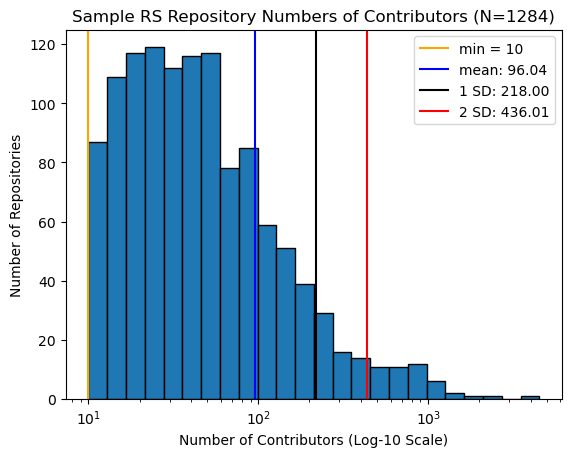

In [30]:
ax = sns.histplot(x=repo_size.contributors, alpha=1, log_scale=10)
ax.set_title("Sample RS Repository Numbers of Contributors (N=1284)")
ax.set_ylabel("Number of Repositories")

ax.set_xlabel("Number of Contributors (Log-10 Scale)")
pop2SD = (repo_size.contributors.std()*2)
ax.axvline(x=10, color="orange").set_label("min = 10")
ax.axvline(x=repo_size.contributors.mean(), color="blue").set_label("mean: 96.04") ## THIS IS mean
ax.axvline(x=repo_size.contributors.std(), color="black").set_label("1 SD: 218.00") ## THIS IS 1 Std Deviation 
ax.axvline(x=pop2SD, color="red").set_label("2 SD: 436.01") ## THIS IS 2 Std Deviations 
ax.legend()  # adds the line legend in 
plt.savefig("../../images/analysis_run_sample_45pc_2025-05-15/45pc_sample_teamsizes_logplot.pdf", **saveout_args)

In [244]:
repo_size.contributors.describe()

count    1193.000000
mean       96.040235
std       218.002621
min        10.000000
25%        21.000000
50%        40.000000
75%        84.000000
max      4509.000000
Name: contributors, dtype: float64

In [235]:
repo_size.contributors.mean()

96.04023470243085

In [233]:
repo_size.contributors.std()

218.00262079872508

In [234]:
repo_size.contributors.std()*2

436.00524159745015

Text(0, 0.5, 'Number of Repositories')

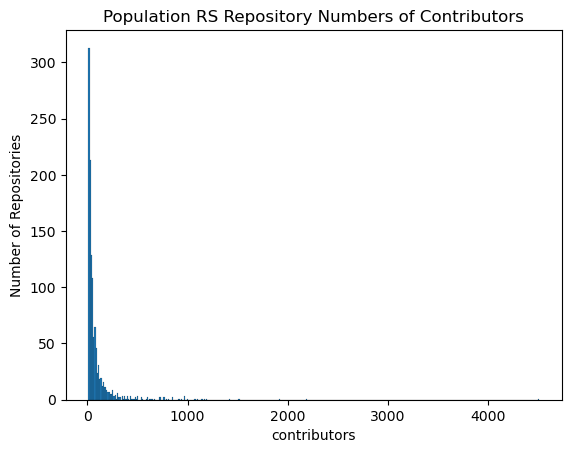

In [229]:
ax = sns.histplot(x=repo_size.contributors, alpha=1, log_scale=False)
ax.set_title("Population RS Repository Numbers of Contributors")
ax.set_ylabel("Number of Repositories")

In [225]:
repo_size.query("contributors > 307")

,repo_name,contributors
11,ActivityWatch/activitywatch,498
12,AlDanial/cloc,650
82,Day8/re-frame,390
83,Deci-AI/super-gradients,506
94,DistrictDataLabs/yellowbrick,324
...,...,...
1234,tree-sitter/tree-sitter,1170
1240,tweepy/tweepy,1414
1248,unionai-oss/pandera,591
1265,wkentaro/labelme,769


In [222]:
repo_size.contributors.describe()

count    1284.000000
mean       89.699377
std       211.381740
min         1.000000
25%        18.000000
50%        36.000000
75%        79.000000
max      4509.000000
Name: contributors, dtype: float64

Text(0, 0.5, 'Number of Repositories')

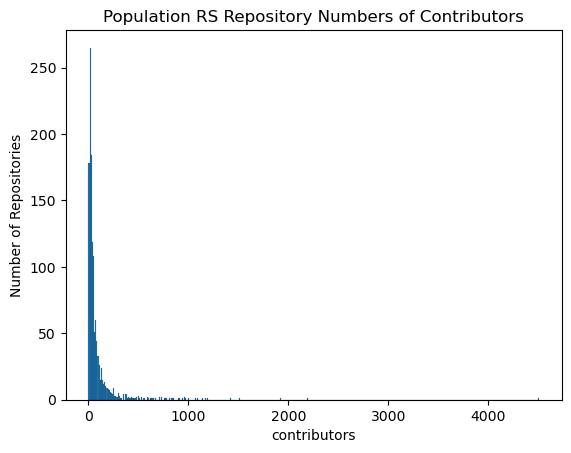

In [221]:
ax = sns.histplot(x=repo_size.contributors, alpha=1, log_scale=False)
ax.set_title("Population RS Repository Numbers of Contributors")
ax.set_ylabel("Number of Repositories")

In [210]:
analysis_dataset.query("repo_name == 'zfit/zfit'")

,cluster_labels,repo_name,author_username,n_of_commit_creators,n_commits,n_changes,mean_n_changes,median_n_changes_changed,std_n_changes_changed,n_files_changed,...,which_interactions,breadth_interactions,pc_pull_request_created,pc_pull_request_closed,pc_commit_created,pc_issue_created,pc_issue_closed,pc_sum_n_interactions,pc_interaction_days,pc_DC
21844,2,zfit/zfit,AstroViking,27.0,7.0,613.0,87.571429,71.0,99.644129,7.0,...,"commit_created, pull_request_created",2,0.220751,0.000000,0.160957,0.000000,0.000000,0.144326,0.071839,0.076341
21845,2,zfit/zfit,ConnorStoneAstro,27.0,5.0,529.0,105.800000,159.0,74.489597,5.0,...,"commit_created, pull_request_created",2,0.220751,0.000000,0.114969,0.000000,0.000000,0.108245,0.143678,0.067144
21846,2,zfit/zfit,ImgBotApp,27.0,1.0,3166.0,3166.000000,3166.0,NaN,4.0,...,commit_created,1,0.000000,0.000000,0.022994,0.000000,0.000000,0.018041,0.071839,0.004599
21847,2,zfit/zfit,SebastianJL,27.0,173.0,13535.0,78.236994,12.0,294.295822,1001.0,...,"pull_request_closed, issue_created, commit_cre...",5,4.856512,2.242152,4.000920,1.290323,0.714286,3.770521,3.160920,2.172408
21848,2,zfit/zfit,a-maur,27.0,19.0,7529.0,396.263158,51.0,530.555458,137.0,...,"commit_created, pull_request_created, pull_req...",4,1.103753,0.672646,0.436882,0.000000,0.000000,0.487101,0.359195,0.974794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83680,2,zfit/zfit,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,issue_created,1,0.000000,0.000000,0.000000,1.290323,0.000000,0.036082,0.143678,0.258065
83681,2,zfit/zfit,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,"pull_request_created, pull_request_closed",2,0.441501,0.224215,0.000000,0.000000,0.000000,0.054122,0.143678,0.088300
83682,2,zfit/zfit,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,"issue_closed, issue_created",2,0.000000,0.000000,0.000000,0.645161,0.714286,0.036082,0.143678,0.271889
83683,2,zfit/zfit,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,issue_created,1,0.000000,0.000000,0.000000,1.290323,0.000000,0.036082,0.143678,0.258065


In [25]:
ax = sns.histplot(x=population.devs, alpha=1, log_scale=10)
ax.set_title("Population RS Repository Numbers of Contributors")
ax.set_ylabel("Number of Repositories")
ax.set_xlabel("Number of Contributors (Log-10 Scale)")
pop2SD = (population.devs.std()*2)
ax.axvline(x=population.devs.mean(), color="blue").set_label("mean: 9.32") ## THIS IS mean
ax.axvline(x=population.devs.std(), color="black").set_label("1 SD: 153.68") ## THIS IS 1 Std Deviation 
ax.axvline(x=pop2SD, color="red").set_label("2 SD: 307.36") ## THIS IS 2 Std Deviations 
ax.legend()  # adds the line legend in 
plt.savefig("../../images/analysis_run_sample_45pc_2025-05-15/45pc_sample_teamsizes_logplot.pdf", **saveout_args)

NameError: name 'population' is not defined

In [7]:

from githubanalysis.visualization.plot_dendrogram import Dendrogrammer

dendrogrammer = Dendrogrammer(
    in_notebook=True,
    logger=dataanalyser.logger,
    image_write_location=dataanalyser.image_write_location,
)



In [8]:
dataanalyser.image_write_location

PosixPath('../../images/analysis_run_sample_45pc_notebook_pca_2025-05-15')

In [9]:
cluster_data_df = pd.read_csv("../../data/analysis_run_sample_45pc_2025-05-12/sample_clustering_data_2025-05-12.csv", header=0, low_memory=False,)

In [10]:
cluster_data_df.sample(n=5000)#

,pc_commit_created,pc_issue_created,pc_issue_closed,pc_issues_assigned_of_assigned,pc_pull_request_created,pc_pull_request_closed,pc_DC,pc_sum_n_interactions,pc_interaction_days,pc_created-closed_issues
72923,0.000000,0.096525,0.000000,0.0,0.000000,0.0,0.019305,0.010147,0.037411,0.000965
38597,0.000000,0.719424,0.000000,0.0,0.000000,0.0,0.143885,0.314465,0.487805,0.007194
73907,0.000000,0.483092,0.000000,0.0,0.000000,0.0,0.096618,0.091158,0.155763,0.004831
96591,0.000000,0.130208,0.000000,0.0,0.000000,0.0,0.026042,0.024919,0.064061,0.001302
18019,0.009604,0.187970,0.119760,0.0,0.138122,0.0,0.091091,0.036406,0.076726,-0.117881
...,...,...,...,...,...,...,...,...,...,...
80248,0.000000,0.171527,0.000000,0.0,0.000000,0.0,0.034305,0.052274,0.083022,0.001715
101669,0.000000,0.070175,0.000000,0.0,0.000000,0.0,0.014035,0.019662,0.038730,0.000702
106615,0.000000,0.465116,0.478469,0.0,0.000000,0.0,0.188717,0.045167,0.074239,-0.473818
87025,0.000000,0.000000,0.000000,0.0,0.142653,0.0,0.028531,0.018328,0.041085,0.000000


In [11]:
# dendrogrammer.plot_dendrogram_with_leaf_counts(
#     clustering_data=cluster_data_df,
#     file_name="45pc_dendrogram_w_leafcounts_2357",
#     save_type="pdf",)

In [12]:
# from scipy.cluster.hierarchy import linkage, dendrogram

# label_color_dict = [
#             "#D50032",
#             "#1D2A3D",
#             "#FDBC42",
#         ]  # REVERESED COLOUR ORDER AS I'VE SET DISTANCE_SORT to TRUE!!!
# sns.set_palette(label_color_dict)

# #sys.setrecursionlimit(100000)  # attempt to address recursion limit error
# #gc.collect()  # garbage collection to free up space/mem: spring cleaning!

# ward_clustering = linkage(cluster_data_df.sample(n=10000), method="ward", metric="euclidean")


# plt.figure(figsize=(25, 10))
# plt.xlabel("Clustered Repo-individuals")
# plt.ylabel("Distance")
# dendrogram(
#     ward_clustering,
#     show_contracted=True,
#     no_labels=False, # set this to false to re-allow values under leafs.
#     color_threshold=1500,
#     above_threshold_color="black",
#     count_sort=False,
#     distance_sort=False,
#     show_leaf_counts=True, # use =True to add numbers below leaves
#     truncate_mode="level",  # show only the last p merged clusters
#     p=5,  # show only the last p merged clusters
#     leaf_rotation=360, # this does nothing if show_leaf_counts is false
# )
# plt.show()

In [13]:
# try:
#     dendrogrammer.plot_dendrogram_with_leaf_counts(
#         clustering_data=cluster_data_df,
#         file_name="45pc_dendrogram_w_leafcounts",
#         save_type="pdf",
#     )
# except Exception as e:
#     dendrogrammer.logger.error(f"Problem running data analysis workflow: {e}.")
# raise RuntimeError

In [17]:
orig_dataset.groupby(["repo_name", "gh_username"]).ngroups

244143

In [18]:
orig_dataset.n_commits.sum() # number of commits 4.7million across all 262,706 repo-individs

4746707.0

In [19]:
orig_dataset.n_issues.sum() # number of issues 1.7 million across all 262,706 repo-indiviuals 

1772477.0

In [20]:
orig_dataset.n_issues_assigned.sum() # 400,000 issues assigned across all 262,706 repo-individuals

404572.0

In [21]:
orig_dataset.groupby("repo_name").size()
# SHOWS FIX IN NAMES: 
# repo_name
# 1313e/CMasher                         33
# 3MAH/microgen                         13
# 3dct/open_iA                          18
# 4DNucleome/PartSeg                    23
# 52North/javaPS                        16
#                                     ... 
# zfit/zfit                             65
# zkbt/chromatic                        19
# zooniverse/aggregation-for-caesar     33
# zqfang/GSEApy                        190
# zwicker-group/py-pde                  65

# PREVIOUS PUIR EFFORT:
# repo_name
# 1313e/CMasher                         33
# 3MAH/microgen                         13
# 3dct/open_iA                          18
# 4DNucleome/PartSeg                    23
# 52North/javaPS                        16
#                                     ... 
# zooniverse/aggregation-for-caesar     32
# zooniverse/aggregation/for/caesar     19
# zqfang/GSEApy                        190
# zwicker-group/py-pde                  65
# zwicker/group/py/pde                   7

repo_name
1313e/CMasher                         33
3MAH/microgen                         13
3dct/open_iA                          18
4DNucleome/PartSeg                    23
52North/javaPS                        16
                                    ... 
zfit/zfit                             65
zkbt/chromatic                        19
zooniverse/aggregation-for-caesar     33
zqfang/GSEApy                        190
zwicker-group/py-pde                  65
Length: 2868, dtype: int64

In [22]:
# read in the analysed dataset with cluster labels
analysis_dataset = pd.read_csv(analysis_dataset_file, header=0, low_memory=False)
#analysis_dataset.columns

In [23]:
len(analysis_dataset)

115174

In [24]:
len(analysis_dataset) * 0.005

575.87

In [25]:
print(analysis_dataset.cluster_labels.value_counts(dropna=False))
# cluster_labels
# 2    112117
# 0      2357
# 1       700

print(analysis_dataset.cluster_labels.value_counts(dropna=False, normalize=True)*100)

cluster_labels
2    112117
0      2357
1       700
Name: count, dtype: int64
cluster_labels
2    97.345755
0     2.046469
1     0.607776
Name: proportion, dtype: float64


In [26]:
# label_color_dict = ['#D50032', '#1D2A3D','#FDBC42'] # REVERESED COLOUR ORDER AS I'VE SET DISTANCE_SORT to TRUE!!!
# sns.set_palette(label_color_dict)

# sys.setrecursionlimit(100000)  # attempt to address recursion limit error
# gc.collect()  # garbage collection to free up space/mem: spring cleaning!

# ward_clustering = linkage(clustering_data, method="ward", metric="euclidean")    

# dendrogram(
#     ward_clustering, 
#     show_contracted=True, 
#     no_labels=True, 
#     color_threshold = 400, 
#     above_threshold_color='black', 
#     count_sort=False, 
#     distance_sort=False, 
#     show_leaf_counts=True,
# )

In [27]:
analysis_dataset.cluster_labels.nunique() == 3

True

In [28]:
subsample_cluster0 = analysis_dataset.query("cluster_labels == 0")[["repo_name", "gh_username", "cluster_labels"]]
subsample_cluster0

,repo_name,gh_username,cluster_labels
13,SINTEF/AutoActive-ActivityPresenter,aliverud,0
28,feelpp/book.feelpp.org,dependabot[bot],0
42,feelpp/book.feelpp.org,vincentchabannes,0
46,LDflex/LDflex,RubenVerborgh,0
48,LDflex/LDflex,dependabot[bot],0
...,...,...,...
115133,ctuning/ck-math,ens-lg4,0
115134,ctuning/ck-math,gfursin,0
115136,coin-or/python-mip,h-g-s,0
115151,Open-Science-Training-Handbook/handbook_content,helenebr,0


In [29]:
subsample_0 = pd.merge(subsample_cluster0, orig_dataset, on=["gh_username", "repo_name"], )
subsample_0.drop(columns=["cluster_labels"], inplace=True)

dataanalyser.writeout_data_to_csv(subsample_0, "subsample_45pc_cluster_0_data_") 

PosixPath('../../data/analysis_run_sample_45pc_notebook_pca_2025-05-15/subsample_45pc_cluster_0_data__2025-05-15.csv')

In [30]:
subsample_cluster1 = analysis_dataset.query("cluster_labels == 1")[["repo_name", "gh_username", "cluster_labels"]]
subsample_cluster1

,repo_name,gh_username,cluster_labels
4,WIPACrepo/iceprod,dsschult,1
39,feelpp/book.feelpp.org,prudhomm,1
100,dswah/pyGAM,dswah,1
188,JuliaMath/MeasureTheory.jl,cscherrer,1
286,sintefmath/Jutul.jl,moyner,1
...,...,...,...
111917,cohenlabUNC/clpipe,wasciutto,1
112181,ncihtan/data-models,adamjtaylor,1
113908,desy-ml/cheetah,jank324,1
114556,cytoscape/cytoscape.js,maxkfranz,1


In [31]:
subsample_1 = pd.merge(subsample_cluster1, orig_dataset, on=["gh_username", "repo_name"], )
subsample_1.drop(columns=["cluster_labels"], inplace=True)

dataanalyser.writeout_data_to_csv(subsample_1, "subsample_45pc_cluster_1_data_") 

PosixPath('../../data/analysis_run_sample_45pc_notebook_pca_2025-05-15/subsample_45pc_cluster_1_data__2025-05-15.csv')

In [32]:
subsample_cluster2 = analysis_dataset.query("cluster_labels == 2")[["repo_name", "gh_username", "cluster_labels"]]
subsample_cluster2

,repo_name,gh_username,cluster_labels
0,WIPACrepo/iceprod,actions-user,2
1,WIPACrepo/iceprod,alemsh,2
2,WIPACrepo/iceprod,carlwitt,2
3,WIPACrepo/iceprod,dependabot[bot],2
5,WIPACrepo/iceprod,hskarlupka,2
...,...,...,...
115169,ncihtan/data-models,GiaJordan,2
115170,INCATools/ontology-access-kit,jmcmurry,2
115171,nf-core/epitopeprediction,SusiJo,2
115172,Ouranosinc/raven,aulemahal,2


In [33]:
subsample_2 = pd.merge(subsample_cluster2, orig_dataset, on=["gh_username", "repo_name"], )
subsample_2.drop(columns=["cluster_labels"], inplace=True)

dataanalyser.writeout_data_to_csv(subsample_2, "subsample_45pc_cluster_2_data_") 

PosixPath('../../data/analysis_run_sample_45pc_notebook_pca_2025-05-15/subsample_45pc_cluster_2_data__2025-05-15.csv')

In [34]:
len(analysis_dataset)

115174

In [35]:
cluster1_issues_only = len(analysis_dataset.query("cluster_labels == 1 and which_interactions == 'issue_created'")[["gh_username", "repo_name", "cluster_labels", "breadth_interactions", "which_interactions"]])
cluster0_issues_only = len(analysis_dataset.query("cluster_labels == 0 and which_interactions == 'issue_created'")[["gh_username", "repo_name", "cluster_labels", "breadth_interactions", "which_interactions"]])
cluster2_issues_only = len(analysis_dataset.query("cluster_labels == 2 and which_interactions == 'issue_created'")[["gh_username", "repo_name", "cluster_labels", "breadth_interactions", "which_interactions"]])

print(f'Cluster 0 contains {cluster0_issues_only} issues_only folks of {len(analysis_dataset.query("cluster_labels == 0"))}; cluster 1 contains {cluster1_issues_only} issues_only folks of {len(analysis_dataset.query("cluster_labels == 1"))} and  cluster 2 contains {cluster2_issues_only} issues_only folks of {len(analysis_dataset.query("cluster_labels == 2"))}.')

Cluster 0 contains 27 issues_only folks of 2357; cluster 1 contains 0 issues_only folks of 700 and  cluster 2 contains 56199 issues_only folks of 112117.


In [36]:
cluster1_commits_only = len(analysis_dataset.query("cluster_labels == 1 and which_interactions == 'commit_created'")[["gh_username", "repo_name", "cluster_labels", "breadth_interactions", "which_interactions"]])
cluster0_commits_only = len(analysis_dataset.query("cluster_labels == 0 and which_interactions == 'commit_created'")[["gh_username", "repo_name", "cluster_labels", "breadth_interactions", "which_interactions"]])
cluster2_commits_only = len(analysis_dataset.query("cluster_labels == 2 and which_interactions == 'commit_created'")[["gh_username", "repo_name", "cluster_labels", "breadth_interactions", "which_interactions"]])

print(f'Cluster 0 contains {cluster0_commits_only} commits_only folks of {len(analysis_dataset.query("cluster_labels == 0"))}; cluster 1 contains {cluster1_commits_only} commits_only folks of {len(analysis_dataset.query("cluster_labels == 1"))} and  cluster 2 contains {cluster2_commits_only} commits_only folks of {len(analysis_dataset.query("cluster_labels == 2"))}.')

Cluster 0 contains 0 commits_only folks of 2357; cluster 1 contains 0 commits_only folks of 700 and  cluster 2 contains 2891 commits_only folks of 112117.


In [37]:
#analysis_dataset.query("cluster_labels == 0 and which_interactions == 'issue_created'")[["gh_username", "repo_name", "cluster_labels", "breadth_interactions", "which_interactions"]]
# 53736 rows × 5 columns

no_issues_only = analysis_dataset.query("which_interactions != 'issue_created'")[["repo_name","gh_username",]]
no_issues_only_sample = pd.merge(no_issues_only, orig_dataset, on=["repo_name","gh_username"], )
no_issues_only_sample
dataanalyser.writeout_data_to_csv(no_issues_only_sample, "subsample_no_issues_only_data_") 
#no_issues_only_sample

# no initial cluster 1 w/ issues only; cluster 0 only. 
# Removing issues_only leaves 52595 repo-individuals in analysis dataset (ie total 107958 - issues-only 55363). 

PosixPath('../../data/analysis_run_sample_45pc_notebook_pca_2025-05-15/subsample_no_issues_only_data__2025-05-15.csv')

In [38]:
analysis_dataset.columns

Index(['cluster_labels', 'repo_name', 'author_username',
       'n_of_commit_creators', 'n_commits', 'n_changes', 'mean_n_changes',
       'median_n_changes_changed', 'std_n_changes_changed', 'n_files_changed',
       'mean_n_files', 'median_n_files_changed', 'std_n_files_changed',
       'hattori_lanza_size_cat_tiny', 'hattori_lanza_size_cat_small',
       'hattori_lanza_size_cat_medium', 'hattori_lanza_size_cat_large',
       'hattori_lanza_content_cat_forward_engineering',
       'hattori_lanza_content_cat_reengineering',
       'hattori_lanza_content_cat_corrective_engineering',
       'hattori_lanza_content_cat_management',
       'hattori_lanza_content_cat_empty_message',
       'hattori_lanza_content_cat_no_categorisation', 'vasilescu_category_doc',
       'vasilescu_category_img', 'vasilescu_category_l10n',
       'vasilescu_category_ui', 'vasilescu_category_media',
       'vasilescu_category_code', 'vasilescu_category_meta',
       'vasilescu_category_config', 'vasilescu_categ

In [39]:
analysis_dataset[['commit_created', 'issue_closed',
       'issue_created', 'n_issues_assigned', 'pull_request_created',
'pull_request_closed',]]

,commit_created,issue_closed,issue_created,n_issues_assigned,pull_request_created,pull_request_closed
0,7.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,1.0,1.0,1.0
2,1.0,0.0,1.0,0.0,1.0,0.0
3,11.0,0.0,0.0,0.0,23.0,8.0
4,2480.0,211.0,264.0,216.0,97.0,119.0
...,...,...,...,...,...,...
115169,0.0,1.0,0.0,1.0,0.0,0.0
115170,0.0,1.0,0.0,1.0,0.0,0.0
115171,0.0,1.0,0.0,2.0,0.0,0.0
115172,0.0,1.0,0.0,1.0,0.0,0.0


In [40]:
interactions_totals = analysis_dataset[['commit_created', 'issue_closed',
       'issue_created', 'n_issues_assigned', 'pull_request_created',
'pull_request_closed',]].sum().reset_index(name="sample_interactions_total").sort_values(by="sample_interactions_total")
interactions_totals
pd.reset_option('display.float_format')

#interactions_totals.sample_interactions_total = interactions_totals.sample_interactions_total.astype(int)
#sample_interactions = interactions_totals
sum_interactions = interactions_totals.sample_interactions_total.sum()
interactions_totals["pc_sample_interactions"] = (interactions_totals.sample_interactions_total / sum_interactions)*100
#pd.options.display.float_format = 
interactions_totals

,index,sample_interactions_total,pc_sample_interactions
3,n_issues_assigned,193588.0,4.920877
1,issue_closed,282613.0,7.183833
2,issue_created,352913.0,8.970812
5,pull_request_closed,460965.0,11.717421
4,pull_request_created,471677.0,11.989713
0,commit_created,2172258.0,55.217343


In [41]:
sum_interactions

3934014.0

In [190]:
193588.0/3934014.0

0.04920877251580701

Text(0.5, 1.0, 'Total Sample Interactions Per Included Type')

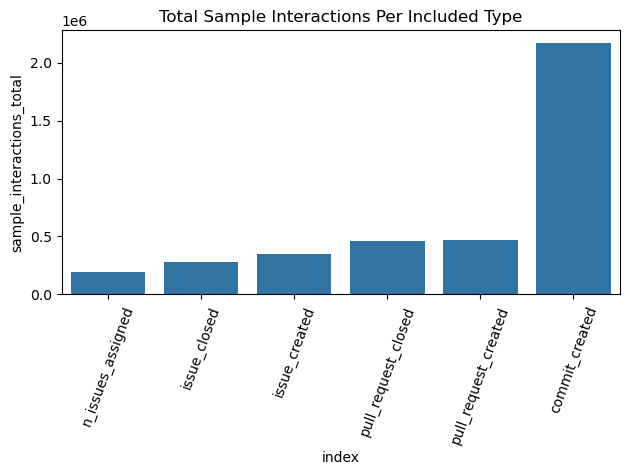

In [42]:
#interactions_totals.sample_interactions_total
#interactions_totals.loc['sample_interactions_totals'] = interactions_totals.sample_interactions_total.apply(int)

sns.barplot(data=analysis_dataset[['commit_created', 'issue_closed',
       'issue_created', 'n_issues_assigned', 'pull_request_created',
'pull_request_closed',]].sum().reset_index(name="sample_interactions_total").sort_values(by="sample_interactions_total"),
            x='index', y='sample_interactions_total', )
plt.xticks(rotation=70)
plt.tight_layout()
plt.title("Total Sample Interactions Per Included Type")
#plt.ticklabel_format(style='plain')


In [43]:
analysis_dataset[['interaction_days', 'interaction_period_days',]].sum().reset_index(name="total_days").sort_values(by="total_days")

,index,total_days
0,interaction_days,1174207
1,interaction_period_days,23677172


In [44]:
1174207/365

3217.0054794520547

In [45]:
#analysis_dataset[['interaction_days', 'interaction_period_days',]].sum().reset_index(name="total_days").sort_values(by="total_days")

analysis_dataset[['interaction_days', 'interaction_period_days',]].sum().reset_index(name="total_days").sort_values(by="total_days")['total_days'].apply(lambda x: x/365)

0     3217.005479
1    64868.964384
Name: total_days, dtype: float64

In [46]:
analysis_dataset.groupby("repo_name")["n_of_commit_creators"].mean().max()

283.0

In [47]:
analysis_dataset.repo_name.nunique()
sample_repo_names = analysis_dataset.repo_name.unique()
sample_repo_names

array(['WIPACrepo/iceprod', 'SINTEF/AutoActive-ActivityPresenter',
       'feelpp/book.feelpp.org', ..., 'desy-ml/cheetah',
       'cytoscape/cytoscape.js', 'OpenChemistry/avogadrolibs'],
      dtype=object)

In [48]:
sample_repo_stats = pd.read_csv(repo_stats_file, header=0, low_memory=False)
#sample_repo_stats.columns
sample_repo_stats = sample_repo_stats[sample_repo_stats["repo_name"].isin(sample_repo_names)]
sample_repo_stats.to_csv(f"../../data/analysis_run_sample_45pc_2025-05-12/summarised_SAMPLE_repos_stats_2025-05-15.csv", index=False, header=True)

In [49]:
sample_repo_stats.repo_license.value_counts(dropna=False,normalize=True)*100

repo_license
MIT                   35.981308
Apache-2.0            17.056075
GPL-3.0               16.199377
BSD-3-Clause          15.420561
GPL-2.0                3.426791
LGPL-3.0               2.258567
BSD-2-Clause           2.180685
AGPL-3.0               1.869159
CC-BY-4.0              1.557632
CC0-1.0                1.012461
MPL-2.0                0.856698
LGPL-2.1               0.700935
CC-BY-SA-4.0           0.467290
Unlicense              0.311526
ISC                    0.311526
EUPL-1.2               0.155763
EPL-1.0                0.077882
EPL-2.0                0.077882
BSD-3-Clause-Clear     0.077882
Name: proportion, dtype: float64

In [50]:
sample_repo_stats.repo_license.value_counts(dropna=False,normalize=False)

repo_license
MIT                   462
Apache-2.0            219
GPL-3.0               208
BSD-3-Clause          198
GPL-2.0                44
LGPL-3.0               29
BSD-2-Clause           28
AGPL-3.0               24
CC-BY-4.0              20
CC0-1.0                13
MPL-2.0                11
LGPL-2.1                9
CC-BY-SA-4.0            6
Unlicense               4
ISC                     4
EUPL-1.2                2
EPL-1.0                 1
EPL-2.0                 1
BSD-3-Clause-Clear      1
Name: count, dtype: int64

In [51]:
sample_repo_stats.repo_license.nunique()

19

## N Repos

In [52]:
print(f"There are {analysis_dataset.groupby(['repo_name'], as_index=False).ngroups} repos") 

There are 1284 repos


## N Repo-Individuals

In [53]:
grouped_by_devs = analysis_dataset.groupby(["gh_username", "repo_name"], as_index=False)
print(f"There are {grouped_by_devs.ngroups} repo-individuals")

There are 115174 repo-individuals


## N GH-Usernames

In [54]:
multi_repo_users = analysis_dataset.groupby("gh_username")[["repo_name"]].count().reset_index(names=["gh_username", "count"])
multi_repo_users = multi_repo_users.query("repo_name > 1")
total_gh_users = analysis_dataset.groupby("gh_username").ngroups

print(f"There are {len(multi_repo_users)} gh-usernames which appear in more than one repository within the sample; this represents {round((len(multi_repo_users)/total_gh_users)*100, 2)}% of all {total_gh_users} unique gh-usernames \n")

uptotenrepos = multi_repo_users.query("repo_name <= 10")
tentohundredrepos = multi_repo_users.query("repo_name > 10 and repo_name <= 100")
hundredup = multi_repo_users.query("repo_name > 100")


if len(uptotenrepos) > 1: 
    print(f"There are {len(uptotenrepos)} gh-usernames in between 2 and 10 repos in the sample. \n")

else:
    print("no users in 2+ repos")

if len(tentohundredrepos) > 1: 
    print(f"There are {len(tentohundredrepos)} gh-usernames in between 11 and 100 repos in the sample. \n")
    #print(tentohundredrepos.query("repo_name > 50").sort_values(by="repo_name"))
else: 
    print("no users in 10+ repos")
    
if len(hundredup) > 1: 
    print(f"There are {len(hundredup)} gh-usernames in > 100 repos in the sample. \n")
    print(hundredup.sort_values(by="repo_name"))

else: 
     print("no users in 100+ repos")

There are 10079 gh-usernames which appear in more than one repository within the sample; this represents 10.4% of all 96947 unique gh-usernames 

There are 9973 gh-usernames in between 2 and 10 repos in the sample. 

There are 102 gh-usernames in between 11 and 100 repos in the sample. 

There are 4 gh-usernames in > 100 repos in the sample. 

               gh_username  repo_name
76311   pre-commit-ci[bot]        133
47694  github-actions[bot]        160
47465                ghost        294
39932      dependabot[bot]        533


In [261]:
(973/96947)*100

1.0036411647601267

In [55]:
(hundredup.sort_values(by="repo_name")["repo_name"]/1284)*100

76311    10.358255
47694    12.461059
47465    22.897196
39932    41.510903
Name: repo_name, dtype: float64

In [56]:
multi_repo_users.repo_name.mean()

2.8084135330886

In [57]:
print(tentohundredrepos.query("repo_name > 20").sort_values(by="repo_name")) # how many of these are bots?

                   gh_username  repo_name
88628               timgates42         21
41788                 dstansby         22
61958            lgtm-com[bot]         23
37794                   cthoyt         23
22290          TrellixVulnTeam         24
29675                    arfon         24
45852                 fossabot         25
43029                  elfring         25
76864                 pyup-bot         25
75780                    pllim         26
94602               yarikoptic         28
36949            codacy-badger         28
84596                 snyk-bot         30
35044                  cclauss         31
25363             actions-user         33
52187    invalid-email-address         34
27599     allcontributors[bot]         36
95478                 yurivict         44
39930  dependabot-preview[bot]         49
11443              JuliaTagBot         58
47724            gitter-badger         71


In [58]:
print("BOTS: anything ending [bot], anything ending -badger, probably anything ending Bot or -bot")

BOTS: anything ending [bot], anything ending -badger, probably anything ending Bot or -bot


<Axes: xlabel='repo_name', ylabel='Count'>

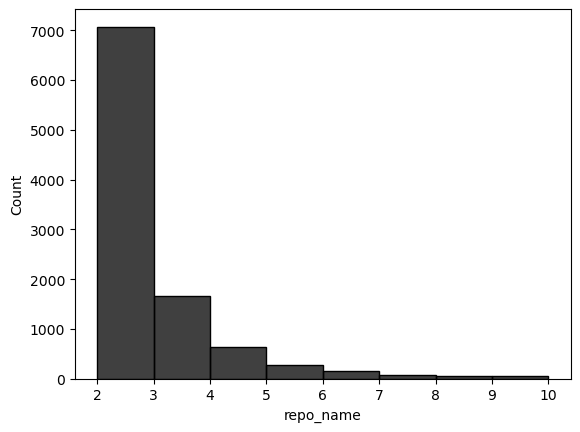

In [59]:
sns.histplot(data=uptotenrepos, x="repo_name", stat="count", binwidth=1, color="black")

<Axes: xlabel='repo_name', ylabel='Count'>

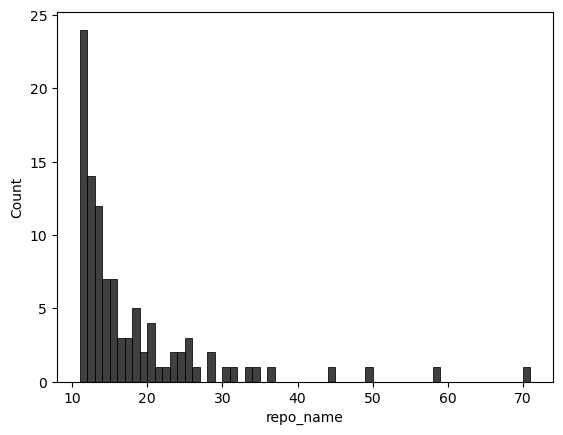

In [60]:
sns.histplot(data=tentohundredrepos, x="repo_name", stat="count", binwidth=1, color="black")

<Axes: xlabel='repo_name', ylabel='Count'>

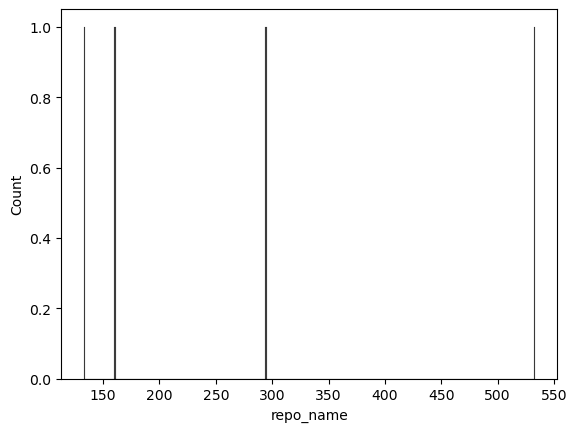

In [61]:
sns.histplot(data=hundredup, x="repo_name", stat="count", binwidth=1, color="black")

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns


patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]

# Initial Clustering:

In [62]:
# N clusters: 
# distribution of repo-individuals amongst cluster labels: 
# distirbution of clusters within repos 
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 

In [63]:
analysis_dataset.cluster_labels.value_counts()


cluster_labels
2    112117
0      2357
1       700
Name: count, dtype: int64

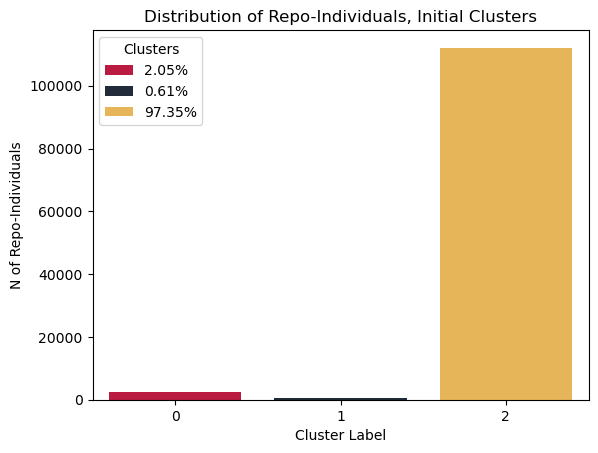

In [37]:
cl0 = round((analysis_dataset.cluster_labels.value_counts(normalize=True)[0]*100), 2)
cl1 = round((analysis_dataset.cluster_labels.value_counts(normalize=True)[1]*100), 2)
cl2 = round((analysis_dataset.cluster_labels.value_counts(normalize=True)[2]*100), 2)

# how are the users distributed across clusters: what size are the clusters? 
g = sns.countplot(
    data=analysis_dataset, 
    x="cluster_labels", 
    hue="cluster_labels", 
    stat="count", 
    palette=label_color_dict, 
)
#g.tick_params(axis='x', which='both', rotation=70)
g.set_title("Distribution of Repo-Individuals, Initial Clusters")
g.set_xlabel("Cluster Label")
g.set_ylabel("N of Repo-Individuals")
plt.legend(title="Clusters", loc='upper left', labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_initial_cluster_distribution_{current_date_info}.pdf", **saveout_args) 
plt.show(g)

In [40]:
devs_per_cluster = analysis_dataset.groupby(["repo_name", "cluster_labels"])["gh_username"].count().reset_index(name="n_devs")
devs_per_cluster

cl0 = f'{devs_per_cluster.groupby("cluster_labels")["n_devs"].count()[0]} repos'
cl1 = f'{devs_per_cluster.groupby("cluster_labels")["n_devs"].count()[1]} repos'
cl2 = f'{devs_per_cluster.groupby("cluster_labels")["n_devs"].count()[2]} repos'

# labels = [cl0, cl1, cl2]

# g = sns.barplot(
#     data=devs_per_cluster, 
#     x="cluster_labels", 
#     y="n_devs", 
#     hue="cluster_labels",
#     estimator="mean", 
#     palette=label_color_dict, 
#     legend="full",
# )
# g.set_title("Distribution of Clusters Across Repositories")
# g.set_xlabel("Cluster Label")
# g.set_ylabel("Mean Number of Repo-Individuals")
# h, l = g.get_legend_handles_labels()
# g.legend(h, labels, title="Clusters", loc="upper right")

# plt.legend(labels, title="Clusters", loc='upper left')
# plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_initial_cluster_repo_distribution_{current_date_info}.pdf", **saveout_args) 
# plt.show(g)
# print(f"There are {analysis_dataset.groupby('repo_name').ngroups} unique repositories in this sample")

In [41]:
devs_per_cluster.groupby("cluster_labels")["repo_name"].count()

cluster_labels
0    1003
1     700
2    1276
Name: repo_name, dtype: int64

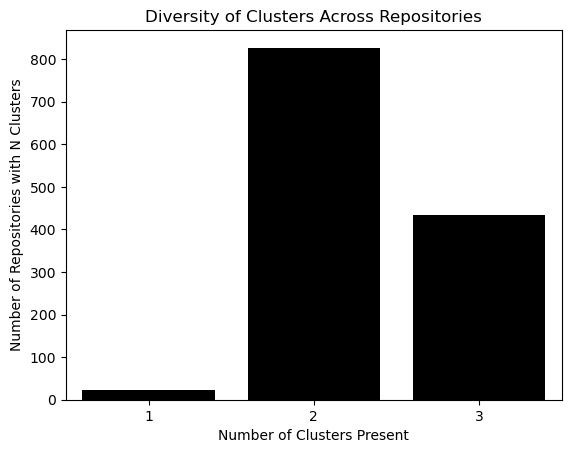

In [43]:
clusters_per_repo = devs_per_cluster.groupby("repo_name")["cluster_labels"].nunique().reset_index(name="n_clusters")
clusters_per_repo

clusters_per_repo.n_clusters.mean()

g = sns.countplot(
    data=clusters_per_repo, 
    x="n_clusters",
    color="black"
    #hue="cluster_labels",
    #palette=label_color_dict, 
)
g.set_title("Diversity of Clusters Across Repositories")
g.set_xlabel("Number of Clusters Present")
g.set_ylabel("Number of Repositories with N Clusters")
#h, l = g.get_legend_handles_labels()
#g.legend(h, labels, title="Clusters", loc="upper right")
#plt.legend(labels, title="Clusters", loc='upper right',)
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_intial_n-clusters-present-per-repo_{current_date_info}.pdf", **saveout_args) 
plt.show(g)


In [249]:
23677172 /365

64868.964383561644

In [250]:
1174207 / 115174

10.195070067897268

In [68]:
115174-112117


3057

In [69]:
len(analysis_dataset)

115174

## Interaction Types

### UIT: number of different types

In [70]:
# aka. breadth_interactions in df
sum(analysis_dataset.breadth_interactions.isna()) # no missing data in this col

0

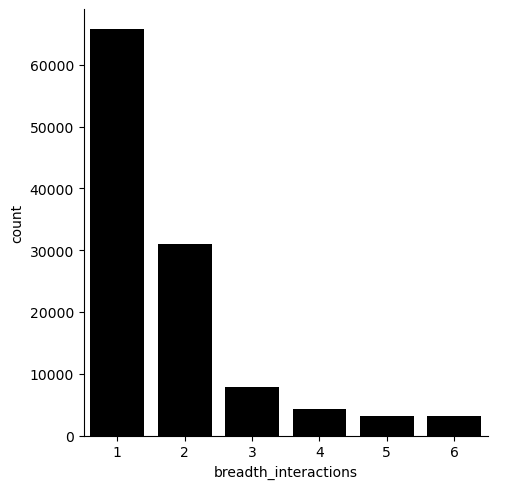

In [71]:
sns.catplot(data=analysis_dataset, x="breadth_interactions", kind="count", color="black")
# distribution of interaction types per repo-individual

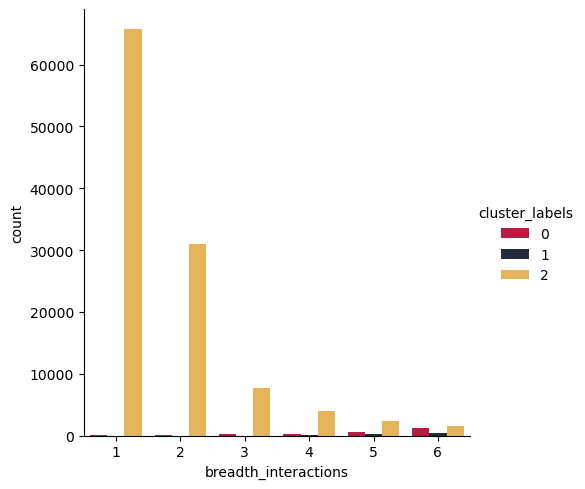

In [72]:
sns.catplot(data=analysis_dataset, x="breadth_interactions", kind="count", hue="cluster_labels", palette=label_color_dict,  )
# distribution of interaction types per repo-individual by initial cluster 

In [73]:
print(f"Min breadth of interactions by repo-individuals is: {analysis_dataset.breadth_interactions.min()}; and max is: {analysis_dataset.breadth_interactions.max()}.")
print(f"Mode breadth of interactions by repo-individuals is: {analysis_dataset.breadth_interactions.mode()[0]} interaction type.")

Min breadth of interactions by repo-individuals is: 1; and max is: 6.
Mode breadth of interactions by repo-individuals is: 1 interaction type.


In [74]:
# how many only single type?
print(f"There are {len(analysis_dataset.query('breadth_interactions == 1'))} repo-individuals with single interaction types")
# which type? (see later)

There are 65725 repo-individuals with single interaction types


In [75]:
# which many show >1 type?
print(f"There are {len(analysis_dataset.query('breadth_interactions > 1'))} repo-individuals with more than one interaction type")

There are 49449 repo-individuals with more than one interaction type


In [76]:
# repo-individ UIT vs their repo mean UITs: TODO

In [77]:
# per-repo mean UIT value: 
analysis_dataset.groupby(["repo_name"])["breadth_interactions"].mean()

repo_name
3MAH/microgen                  2.769231
3dct/open_iA                   1.888889
52North/javaPS                 2.437500
AAROC/AnsibleBootCamp          1.892857
AIDASoft/DD4hep                2.065359
                                 ...   
zarr-developers/zarr-python    1.987374
zfit/phasespace                2.384615
zfit/zfit                      2.138462
zqfang/GSEApy                  1.463158
zwicker-group/py-pde           1.630769
Name: breadth_interactions, Length: 1284, dtype: float64

In [78]:
analysis_dataset.groupby(["repo_name"])["breadth_interactions"].mean().mean()

2.176420516397536

In [79]:
analysis_dataset.groupby(["repo_name"])["breadth_interactions"].mean()

repo_name
3MAH/microgen                  2.769231
3dct/open_iA                   1.888889
52North/javaPS                 2.437500
AAROC/AnsibleBootCamp          1.892857
AIDASoft/DD4hep                2.065359
                                 ...   
zarr-developers/zarr-python    1.987374
zfit/phasespace                2.384615
zfit/zfit                      2.138462
zqfang/GSEApy                  1.463158
zwicker-group/py-pde           1.630769
Name: breadth_interactions, Length: 1284, dtype: float64

In [80]:
# sample mean UIT value:
print(f"The overall sample mean UIT (average number of included interaction interaction types) per repo-individual is {round(analysis_dataset['breadth_interactions'].mean(), 3)}")

The overall sample mean UIT (average number of included interaction interaction types) per repo-individual is 1.762


In [81]:
print("The mean breadth of interactions per initial cluster labelling are:")
analysis_dataset.groupby(["cluster_labels"])["breadth_interactions"].mean()

The mean breadth of interactions per initial cluster labelling are:


cluster_labels
0    5.022910
1    5.524286
2    1.669729
Name: breadth_interactions, dtype: float64

In [82]:
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

variable = "breadth_interactions"
df = analysis_dataset

# One-Way ANOVA: 
anova = f_oneway(
    df.groupby("cluster_labels")[variable].get_group(0),
    df.groupby("cluster_labels")[variable].get_group(1),
    df.groupby("cluster_labels")[variable].get_group(2),
)
    
print(f"{anova}")


# perform Tukey's test
tukey = pairwise_tukeyhsd(endog=df[variable],
                          groups=df['cluster_labels'],
                          alpha=0.05)

#display results
print(tukey)

print(f"For {variable}, anova result p-value is {anova.pvalue}; groups are significantly different = {anova.pvalue < 0.05}")
print(f"For {variable}, Tukey HSD test result p-value is {tukey.pvalues}; groups are significantly different = {tukey.reject == True}")



F_onewayResult(statistic=16394.17266013766, pvalue=0.0)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     0      1   0.5014   0.0  0.3958   0.607   True
     0      2  -3.3532   0.0 -3.4042 -3.3021   True
     1      2  -3.8546   0.0 -3.9476 -3.7615   True
---------------------------------------------------
For breadth_interactions, anova result p-value is 0.0; groups are significantly different = True
For breadth_interactions, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]


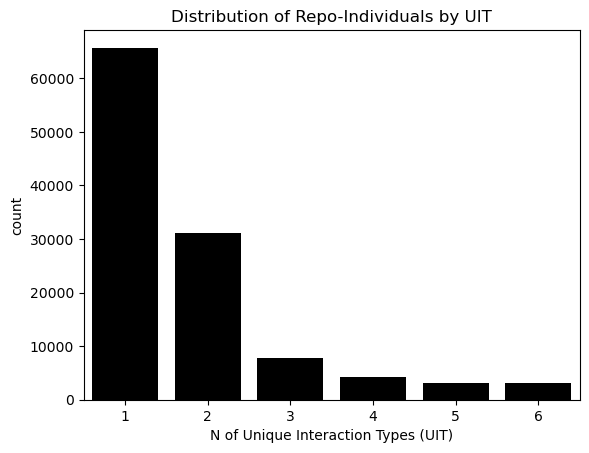

In [44]:
# how are the users distributed across clusters: what size are the clusters? 
g = sns.countplot(
    data=analysis_dataset, 
    x="breadth_interactions", 
    stat="count", 
    color="black"
)
#g.tick_params(axis='x', which='both', rotation=70)
g.set_title("Distribution of Repo-Individuals by UIT")
g.set_xlabel("N of Unique Interaction Types (UIT)")
#plt.legend(title="Clusters", loc='upper right',) #labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_UIT_{current_date_info}.pdf", **saveout_args)
plt.show(g)

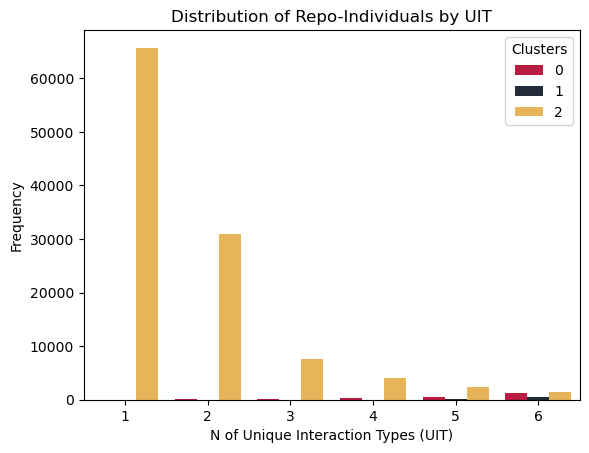

In [46]:
# how are the users distributed across clusters: what size are the clusters? 
g = sns.countplot(
    data=analysis_dataset, 
    x="breadth_interactions", 
    hue="cluster_labels", 
    stat="count", 
    palette=label_color_dict, 
)
#g.tick_params(axis='x', which='both', rotation=70)
g.set_title("Distribution of Repo-Individuals by UIT")
g.set_xlabel("N of Unique Interaction Types (UIT)")
g.set_ylabel("Frequency")
plt.legend(title="Clusters", loc='upper right',) #labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_UIT_distribution_{current_date_info}.pdf", **saveout_args) 
plt.show(g)

In [47]:
sklearn_hcwdata = analysis_dataset

                pc_commit_created
cluster_labels                   
0                       15.450765
1                       57.460602
2                        0.239553


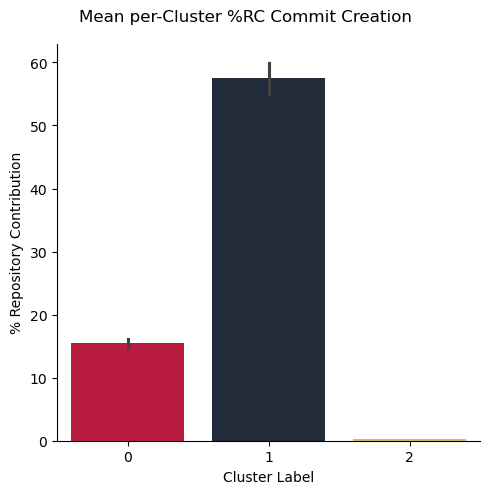

In [48]:
# COMMIT CREATION
print(sklearn_hcwdata.groupby("cluster_labels")[["pc_commit_created"]].mean())
g = sns.catplot(
    data=analysis_dataset, 
    x="cluster_labels", 
    y="pc_commit_created",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict, 
    legend = False,
)
#g.tick_params(axis='x', which='both', rotation=70)
#g.axes.legend().set_title("")
#g.legend(title="Clusters", loc='upper right',) #labels=['0', '1', '2']))
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle("Mean per-Cluster %RC Commit Creation")
g.axes[0,0].set_xlabel('Cluster Label')
g.axes[0,0].set_ylabel('% Repository Contribution')
plt.tight_layout()
#.axes.set_le
#plt.legend(title="Clusters", loc='upper left',) #labels=['0', '1', '2'])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_mean_pc_commit_created_cluster_{current_date_info}.pdf", **saveout_args) 
plt.show(g)

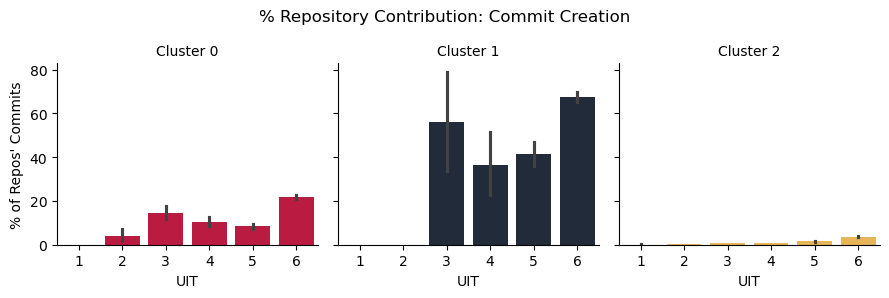

In [49]:

# how are the users distributed across clusters: what size are the clusters? 
g = sns.FacetGrid(data=analysis_dataset, sharey=True, col="cluster_labels",)
g.map_dataframe(sns.barplot,
    x="breadth_interactions", 
    y="pc_commit_created",
    hue="cluster_labels", 
    #binwidth=1,
    estimator="mean",
    palette=label_color_dict, 
)
g.set_axis_labels("")
g.set_titles("Cluster {col_name}")
g.figure.subplots_adjust(top=0.80)
g.figure.suptitle("% Repository Contribution: Commit Creation")
g.set_xlabels("UIT")
g.set_ylabels("% of Repos' Commits")
#g.set_xlabels("Percentage Contribution Depth (% of repo commits)")
#plt.legend(title="Clusters", loc='upper right', labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_RC-commit_creation_UIT_distribution_{current_date_info}.pdf", **saveout_args) 
plt.show(g)

                pc_issue_created
cluster_labels                  
0                      14.820810
1                      39.505821
2                       0.562923


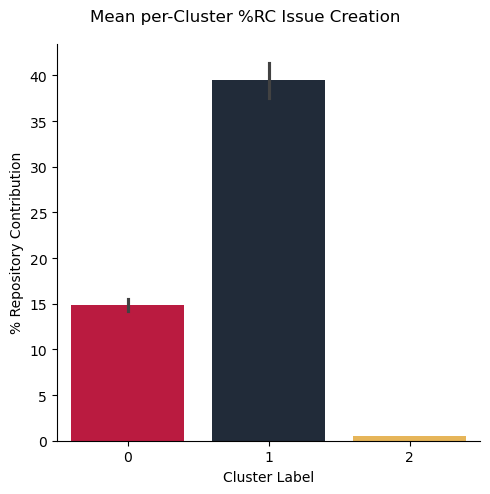

In [50]:
# ISSUE CREATION
print(sklearn_hcwdata.groupby("cluster_labels")[["pc_issue_created"]].mean())
g = sns.catplot(
    data=analysis_dataset, 
    x="cluster_labels", 
    y="pc_issue_created",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict, 
    legend = False,
)
#g.tick_params(axis='x', which='both', rotation=70)
#g.axes.legend().set_title("")
#g.add_legend(title="Clusters", loc='upper right',) #labels=['0', '1', '2']))
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle("Mean per-Cluster %RC Issue Creation")
g.axes[0,0].set_xlabel('Cluster Label')
g.axes[0,0].set_ylabel('% Repository Contribution')
plt.tight_layout()
#.axes.set_le
#plt.legend(title="Clusters", loc='upper left',) #labels=['0', '1', '2'])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_mean_pc_issue_created_cluster_{current_date_info}.pdf", **saveout_args) 
plt.show(g)

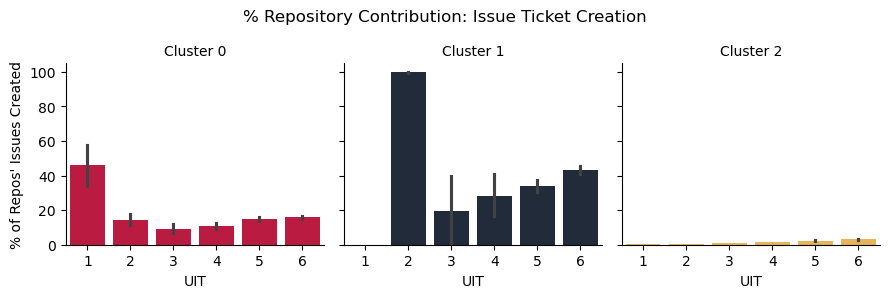

In [51]:
# Issue creation
# how are the users distributed across clusters: what size are the clusters? 
g = sns.FacetGrid(data=analysis_dataset, sharey=True, col="cluster_labels",)
g.map_dataframe(sns.barplot,
    x="breadth_interactions", 
    y="pc_issue_created",
    hue="cluster_labels", 
    #binwidth=1,
    #stat="count", 
    palette=label_color_dict, 
)
g.set_axis_labels("")
g.set_titles("Cluster {col_name}")
g.figure.subplots_adjust(top=0.80)
g.figure.suptitle("% Repository Contribution: Issue Ticket Creation")
g.set_xlabels("UIT")
g.set_ylabels("% of Repos' Issues Created")
#g.set_xlabels("Percentage Contribution Depth (% of repo commits)")
#plt.legend(title="Clusters", loc='upper right', labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_RC-issue_creation_UIT_distribution_{current_date_info}.pdf", **saveout_args) 
plt.show(g)

                pc_issue_closed
cluster_labels                 
0                     20.451390
1                     76.977509
2                      0.192834


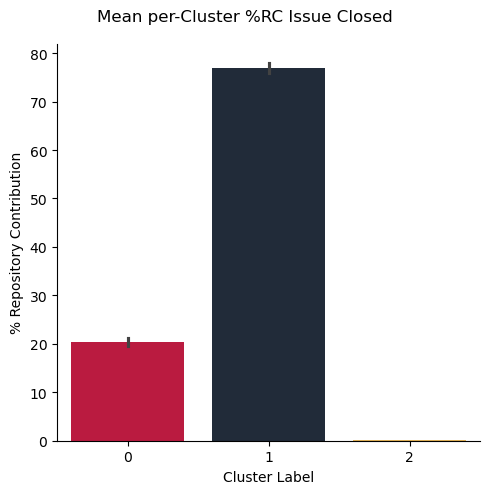

In [52]:
# ISSUE CLOSURE
print(sklearn_hcwdata.groupby("cluster_labels")[["pc_issue_closed"]].mean())
g = sns.catplot(
    data=analysis_dataset, 
    x="cluster_labels", 
    y="pc_issue_closed",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict, 
    legend = False,
)
#g.tick_params(axis='x', which='both', rotation=70)
#g.axes.legend().set_title("")
#g.add_legend(title="Clusters", loc='upper right',) #labels=['0', '1', '2']))
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle("Mean per-Cluster %RC Issue Closed")
g.axes[0,0].set_xlabel('Cluster Label')
g.axes[0,0].set_ylabel('% Repository Contribution')
plt.tight_layout()
#.axes.set_le
#plt.legend(title="Clusters", loc='upper left',) #labels=['0', '1', '2'])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_mean_pc_issue_closed_cluster_{current_date_info}.pdf", **saveout_args) 
plt.show(g)

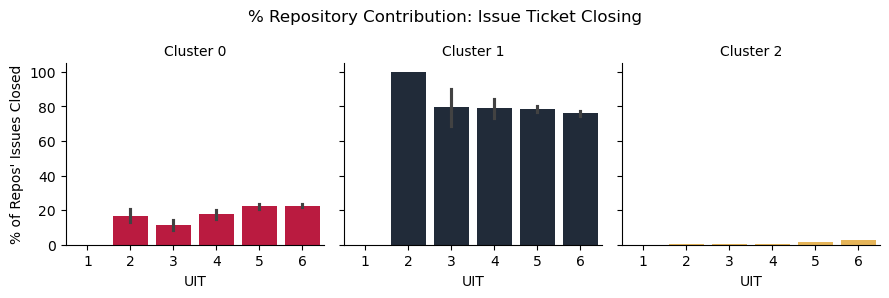

In [53]:
# Issue closure
# how are the users distributed across clusters: what size are the clusters? 
g = sns.FacetGrid(data=analysis_dataset, sharey=True, col="cluster_labels",)
g.map_dataframe(sns.barplot,
    x="breadth_interactions", 
    y="pc_issue_closed",
    hue="cluster_labels", 
    #binwidth=1,
    #stat="count", 
    palette=label_color_dict, 
)
g.set_axis_labels("")
g.set_titles("Cluster {col_name}")
g.figure.subplots_adjust(top=0.80)
g.figure.suptitle("% Repository Contribution: Issue Ticket Closing")
g.set_xlabels("UIT")
g.set_ylabels("% of Repos' Issues Closed")
#g.set_xlabels("Percentage Contribution Depth (% of repo commits)")
#plt.legend(title="Clusters", loc='upper right', labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_RC-issue_closure_UIT_distribution_{current_date_info}.pdf", **saveout_args) 
plt.show(g)

                pc_issues_assigned_of_assigned
cluster_labels                                
0                                    25.674216
1                                    59.045096
2                                     0.187007


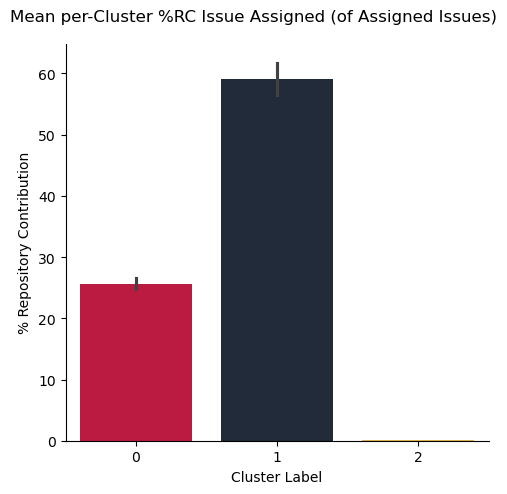

In [54]:
# ISSUE ASSIGNMENT
print(sklearn_hcwdata.groupby("cluster_labels")[["pc_issues_assigned_of_assigned"]].mean())
g = sns.catplot(
    data=analysis_dataset, 
    x="cluster_labels", 
    y="pc_issues_assigned_of_assigned",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict, 
    legend = False,
)
#g.tick_params(axis='x', which='both', rotation=70)
#g.axes.legend().set_title("")
#g.add_legend(title="Clusters", loc='upper right',) #labels=['0', '1', '2']))
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle("Mean per-Cluster %RC Issue Assigned (of Assigned Issues)")
g.axes[0,0].set_xlabel('Cluster Label')
g.axes[0,0].set_ylabel('% Repository Contribution')
plt.tight_layout()
#.axes.set_le
#plt.legend(title="Clusters", loc='upper left',) #labels=['0', '1', '2'])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_mean_pc_issues_assigned_of_assigned_cluster_{current_date_info}.pdf", **saveout_args) 
plt.show(g)

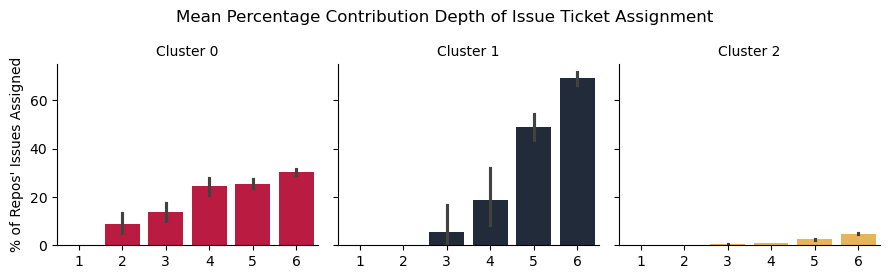

In [55]:
# Issue assignment
# how are the users distributed across clusters: what size are the clusters? 
g = sns.FacetGrid(data=analysis_dataset, sharey=True, col="cluster_labels",)
g.map_dataframe(sns.barplot,
    x="breadth_interactions", 
    y="pc_issues_assigned_of_assigned",
    hue="cluster_labels", 
    #binwidth=1,
    #stat="count", 
    palette=label_color_dict, 
)
g.set_axis_labels("")
g.set_titles("Cluster {col_name}")
g.figure.subplots_adjust(top=0.80)
g.figure.suptitle("Mean Percentage Contribution Depth of Issue Ticket Assignment")
g.set_ylabels("% of Repos' Issues Assigned")
#g.set_xlabels("Percentage Contribution Depth (% of repo commits)")
#plt.legend(title="Clusters", loc='upper right', labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_breadth_depth_pc_issue_assignment_distribution_{current_date_info}.pdf", **saveout_args) 
plt.show(g)

                pc_pull_request_created
cluster_labels                         
0                             17.993994
1                             41.459747
2                              0.493826


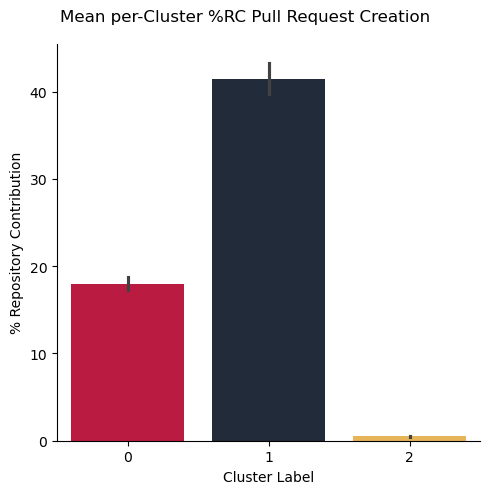

In [56]:
# PULL REQUEST CREATION
print(sklearn_hcwdata.groupby("cluster_labels")[["pc_pull_request_created"]].mean())
g = sns.catplot(
    data=analysis_dataset, 
    x="cluster_labels", 
    y="pc_pull_request_created",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict, 
    legend = False,
)
#g.tick_params(axis='x', which='both', rotation=70)
#g.axes.legend().set_title("")
#g.add_legend(title="Clusters", loc='upper right',) #labels=['0', '1', '2']))
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle("Mean per-Cluster %RC Pull Request Creation")
g.axes[0,0].set_xlabel('Cluster Label')
g.axes[0,0].set_ylabel('% Repository Contribution')
plt.tight_layout()
#.axes.set_le
#plt.legend(title="Clusters", loc='upper left',) #labels=['0', '1', '2'])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_mean_pc_pull_request_created_cluster_{current_date_info}.pdf", **saveout_args) 
plt.show(g)

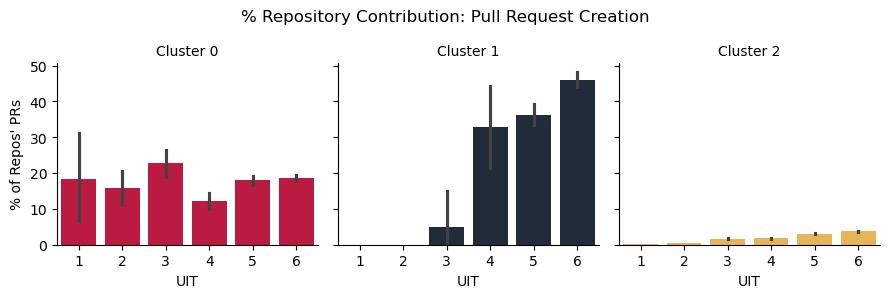

In [57]:
# PRs
# how are the users distributed across clusters: what size are the clusters? 
g = sns.FacetGrid(data=analysis_dataset, sharey=True, col="cluster_labels",)
g.map_dataframe(sns.barplot,
    x="breadth_interactions", 
    y="pc_pull_request_created",
    hue="cluster_labels", 
    #binwidth=1,
    #stat="count", 
    palette=label_color_dict, 
)
g.set_axis_labels("")
g.set_titles("Cluster {col_name}")
g.figure.subplots_adjust(top=0.80)
g.figure.suptitle("% Repository Contribution: Pull Request Creation")
g.set_xlabels("UIT")
g.set_ylabels("% of Repos' PRs")
#g.set_xlabels("Percentage Contribution Depth (% of repo commits)")
#plt.legend(title="Clusters", loc='upper right', labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_RC-PRs_UIT_distribution_{current_date_info}.pdf", **saveout_args) 
plt.show(g)

                pc_pull_request_closed
cluster_labels                        
0                            23.125001
1                            78.830223
2                             0.141536


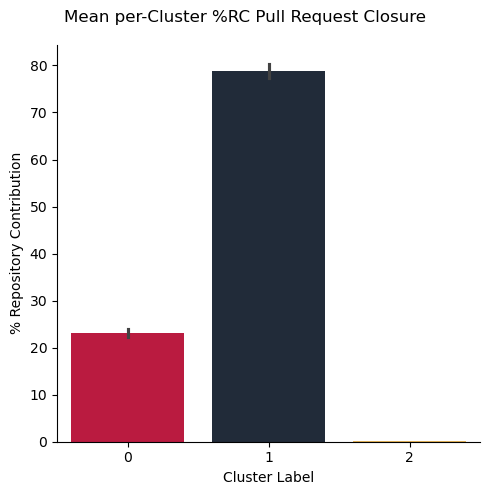

In [58]:
# PULL REQUEST CLOSURE
print(sklearn_hcwdata.groupby("cluster_labels")[["pc_pull_request_closed"]].mean())
g = sns.catplot(
    data=analysis_dataset, 
    x="cluster_labels", 
    y="pc_pull_request_closed",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict, 
    legend = False,
)
#g.tick_params(axis='x', which='both', rotation=70)
#g.axes.legend().set_title("")
#g.add_legend(title="Clusters", loc='upper right',) #labels=['0', '1', '2']))
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle("Mean per-Cluster %RC Pull Request Closure")
g.axes[0,0].set_xlabel('Cluster Label')
g.axes[0,0].set_ylabel('% Repository Contribution')
plt.tight_layout()
#.axes.set_le
#plt.legend(title="Clusters", loc='upper left',) #labels=['0', '1', '2'])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_mean_pc_pull_request_closed_cluster_{current_date_info}.pdf", **saveout_args) 
plt.show(g)

                pc_pull_request_closed
cluster_labels                        
0                            23.125001
1                            78.830223
2                             0.141536


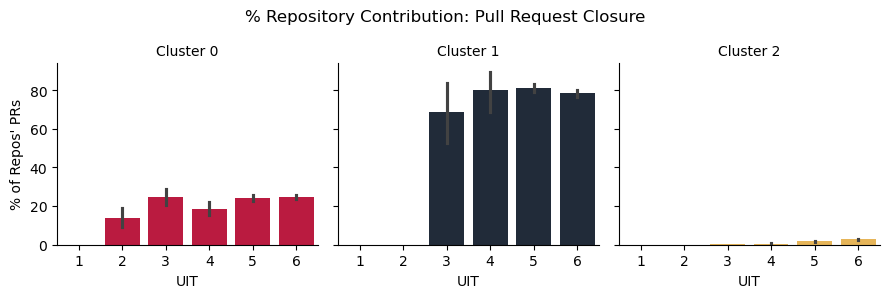

In [59]:
# PRs
print(sklearn_hcwdata.groupby("cluster_labels")[["pc_pull_request_closed"]].mean())
# how are the users distributed across clusters: what size are the clusters? 
g = sns.FacetGrid(data=analysis_dataset, sharey=True, col="cluster_labels",)
g.map_dataframe(sns.barplot,
    x="breadth_interactions", 
    y="pc_pull_request_closed",
    hue="cluster_labels", 
    #binwidth=1,
    #stat="count", 
    palette=label_color_dict, 
)
g.set_axis_labels("")
g.set_titles("Cluster {col_name}")
g.figure.subplots_adjust(top=0.80)
g.figure.suptitle("% Repository Contribution: Pull Request Closure")
g.set_xlabels("UIT")
g.set_ylabels("% of Repos' PRs")
#g.set_xlabels("Percentage Contribution Depth (% of repo commits)")
#plt.legend(title="Clusters", loc='upper right', labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_RC-PRs_closure_UIT_distribution_{current_date_info}.pdf", **saveout_args) 
plt.show(g)

In [97]:
analysis_dataset.columns

Index(['cluster_labels', 'repo_name', 'author_username',
       'n_of_commit_creators', 'n_commits', 'n_changes', 'mean_n_changes',
       'median_n_changes_changed', 'std_n_changes_changed', 'n_files_changed',
       'mean_n_files', 'median_n_files_changed', 'std_n_files_changed',
       'hattori_lanza_size_cat_tiny', 'hattori_lanza_size_cat_small',
       'hattori_lanza_size_cat_medium', 'hattori_lanza_size_cat_large',
       'hattori_lanza_content_cat_forward_engineering',
       'hattori_lanza_content_cat_reengineering',
       'hattori_lanza_content_cat_corrective_engineering',
       'hattori_lanza_content_cat_management',
       'hattori_lanza_content_cat_empty_message',
       'hattori_lanza_content_cat_no_categorisation', 'vasilescu_category_doc',
       'vasilescu_category_img', 'vasilescu_category_l10n',
       'vasilescu_category_ui', 'vasilescu_category_media',
       'vasilescu_category_code', 'vasilescu_category_meta',
       'vasilescu_category_config', 'vasilescu_categ

### Combinations of Types: 

In [98]:
sum(analysis_dataset.which_interactions.isna()) # no missing data

0

In [99]:
def upset_plot(
    cluster: int | None,
    data: pd.DataFrame,
    show_min: float = 0.005,
    show_counts: bool = False,
    sort_combos_by: str = "cardinality",
    data_set_name: str = "dataset",  # manual naming, goes into title of plots
    file_name: str = "upset_plot_",
    save_type: str = "pdf",  # one of: ['png', 'pdf', 'svg']
):
    assert (
        isinstance(cluster, int) or cluster is None
    ), f"give valid input for 'cluster': should be a number or None. You supplied {cluster}."
    assert save_type in [
        "svg",
        "pdf",
        "png",
    ], "save_type is not valid; check you have entered one of: 'svg', 'pdf', 'png'."
    assert (
        sort_combos_by
        in ["cardinality", "-cardinality", "degree", "-degree", "input", "-input"]
    ), "sort_combos_by is not valid, check you've entered one of: 'cardinality', 'degree', 'input' or '-cardinality', '-degree', '-input'."

    # what type is data?
    if isinstance(data, pd.DataFrame):
        assert data.empty is False, "Dataframe data is empty; check inputs."
        print(f"data is df, with shape: {data.shape}.")

    # colours = list(sns.color_palette("colorblind").as_hex())

    data_by_interaction = from_memberships(  # format data to upsetplot requirements
        data.which_interactions.apply(lambda x: [x.strip() for x in x.split(",")]),
        data=data,
    )
    assert isinstance(
        data_by_interaction, pd.DataFrame
    ), "data_by_interaction needs to be a dataframe, check this was generated correctly."

    if cluster is not None:
        cluster_query = f"cluster_labels == {cluster}"
        data = data_by_interaction.query("@cluster_query", engine="python")
        # plot_colour = colours[cluster]
        cluster_name = f"cluster{cluster}"
    else:  # if no clusters supplied:
        data = data_by_interaction
        # plot_colour = "auto"
        cluster_name = data_set_name


    smallest_n_to_show = round(len(data) * show_min)

    print(
        f"Attempting to plot cluster {cluster_name} and showing as far as {show_min}%, which is {smallest_n_to_show} repo-individuals from the data"  # {plot_colour}."
    )

    if show_counts:
        format = "{:,}"
    else:
        format = ""
        
    upset = UpSet(
        data=data,
        how_counts=format,
        sort_by=sort_combos_by,
        # facecolor=plot_colour,
        orientation="horizontal",
        min_subset_size=smallest_n_to_show,
    )
    upset.plot()
    plt.suptitle(
        f"{data_set_name} Interaction-Combinations (showing >{smallest_n_to_show} ({show_min}%) Repo-Individuals),  N={len(data)}"
    )
    plot_file = Path(
        image_write_location,
        f"{file_name}_{cluster_name}_{current_date_info}.{save_type}",
    )
    plt.savefig(fname=plot_file, format=save_type, bbox_inches="tight")
    plt.close()
    print(f"Plot saved out to file {plot_file}.")

In [100]:

def plot_upset_plot_interaction_combinations(
    
    data: pd.DataFrame,
    # colours: list | dict = sns.color_palette("colorblind"),
    separate_by_clusters: bool = False,
    show_min: float = 0.005,
    show_counts: bool = False,
    sort_combos_by: str = "cardinality",
    data_set_name: str = "dataset",
    file_name: str = "upset_plot_",
    save_type: str = "pdf",  # one of: ['png', 'pdf', 'svg']
    # min_repo_individs_per_combo: int = 2,
    # show_counts_per_combo: boolean = True,
    # show_pc: boolean = False,
):
    """
    This generates UpSet plots from GH interaction data from a dataframe or csv file.
    Data must be in a per-repo-individual format, and cluster labels must be in column titled "cluster_labels".

    """
    assert isinstance(
        data, (pd.DataFrame, Path)
    ), "Data is not of type pandas dataframe or Path; check your inputs."
    if isinstance(data, Path):
        print(f"data is a path: {data}")
        data = pd.read_csv(filepath_or_buffer=data, header=0)
        assert isinstance(data, pd.DataFrame), "data could not be read in properly."
        print(f"data is df, with shape: {data.shape}.")
    # if colours is a list and separate_by_clusters is true, does len(colours) match nunique('cluster_labels')?

    assert isinstance(
        data, pd.DataFrame
    ), "data should be dataframe format by now, check why this isn't correct"

    if separate_by_clusters:
        assert (
            "cluster_labels" in data.columns
        ), "df has no column 'cluster_labels - please check this is present in the data."
        n_clusters = data.cluster_labels.nunique()
        print(
                f"Plotting upset plot for {data_set_name}, separating by {n_clusters} clusters from data labels."
        )

        for cluster in range(0, n_clusters - 1, 1):
            # range: start at 0 because this is how they're named by clustering
            # end on n_clusters - 1 because we're starting at 0 and off-by-one; increases by 1
            upset_plot(
                    cluster=cluster,
                    data=data,
                    show_min=show_min,
                    data_set_name=data_set_name,
                    show_counts=show_counts,
                    file_name=f"{file_name}_cluster-{cluster}_",
                )
        print(
            f"Completed UpSet plotting for {n_clusters} clusters from data labels."
        )
    else:
        print("Plotting upset plot without separating by clusters")
        upset_plot(
                cluster=None,
                data=data,
                show_min=show_min,
                show_counts=show_counts,
                sort_combos_by="cardinality",
                data_set_name=data_set_name,
                file_name=file_name,
                save_type="pdf",  # one of: ['png', 'pdf', 'svg']
        )
        print("Completed UpSet plotting.")


In [183]:
print("{Plotting single combined sample UpSet Plot")
upsetplotter.plot_upset_plot_interaction_combinations(
    separate_by_clusters=False,
    data=analysis_dataset,
    show_min = 0.005,
    show_counts=True,
    sort_combos_by="cardinality",
    data_set_name="Sample",
    file_name="sample_upset_plot_45pc_counts",
    save_type="pdf",  # one of: ['png', 'pdf', 'svg']
)
plt.show()

INFO:Plotting upset plot for Sample without separating by clusters
INFO:data is df, with shape: (115174, 86).


{Plotting single combined sample UpSet Plot


INFO:Attempting to plot cluster Sample and showing as far as 0.005%, which is 576 repo-individuals from the data
INFO:Plot saved out to file ../../images/analysis_run_sample_45pc_2025-05-15/sample_upset_plot_45pc_counts_Sample_2025-05-15.pdf.
INFO:Completed UpSet plotting.


In [101]:
print("{Plotting single combined sample UpSet Plot")
upsetplotter.plot_upset_plot_interaction_combinations(
    separate_by_clusters=False,
    data=analysis_dataset,
    show_min = 0.005,
    sort_combos_by="cardinality",
    data_set_name="Sample",
    file_name="sample_upset_plot_45pc",
    save_type="pdf",  # one of: ['png', 'pdf', 'svg']
)
plt.show()

INFO:Plotting upset plot for Sample without separating by clusters
INFO:data is df, with shape: (115174, 86).


{Plotting single combined sample UpSet Plot


INFO:Attempting to plot cluster Sample and showing as far as 0.005%, which is 576 repo-individuals from the data
INFO:Plot saved out to file ../../images/analysis_run_sample_45pc_2025-05-15/sample_upset_plot_45pc_Sample_2025-05-15.pdf.
INFO:Completed UpSet plotting.


In [102]:
print("Plotting separate clusters into UpSet Plot: this doesn't currently work in the script")

tmp0 = analysis_dataset.query("cluster_labels == 0")
tmp1 = analysis_dataset.query("cluster_labels == 1")
tmp2 = analysis_dataset.query("cluster_labels == 2")

Plotting separate clusters into UpSet Plot: this doesn't currently work in the script


In [186]:
# plot cluster 0
upsetplotter.plot_upset_plot_interaction_combinations(
    separate_by_clusters=False,
    data=tmp0,
    show_min = 0.005,
    sort_combos_by="cardinality",
    data_set_name="Cluster 0",
    file_name="sample_upset_plot_45pc_subcluster0_",
    save_type="pdf",  # one of: ['png', 'pdf', 'svg']
)

INFO:Plotting upset plot for Cluster 0 without separating by clusters
INFO:data is df, with shape: (2357, 86).
INFO:Attempting to plot cluster Cluster 0 and showing as far as 0.005%, which is 12 repo-individuals from the data
INFO:Plot saved out to file ../../images/analysis_run_sample_45pc_2025-05-15/sample_upset_plot_45pc_subcluster0__Cluster 0_2025-05-15.pdf.
INFO:Completed UpSet plotting.


In [187]:
# plot cluster 0 WITH COUNTS
upsetplotter.plot_upset_plot_interaction_combinations(
    separate_by_clusters=False,
    data=tmp0,
    show_min = 0.005,
    show_counts=True,
    sort_combos_by="cardinality",
    data_set_name="Cluster 0",
    file_name="sample_upset_plot_45pc_subcluster0_counts",
    save_type="pdf",  # one of: ['png', 'pdf', 'svg']
)

INFO:Plotting upset plot for Cluster 0 without separating by clusters
INFO:data is df, with shape: (2357, 86).
INFO:Attempting to plot cluster Cluster 0 and showing as far as 0.005%, which is 12 repo-individuals from the data
INFO:Plot saved out to file ../../images/analysis_run_sample_45pc_2025-05-15/sample_upset_plot_45pc_subcluster0_counts_Cluster 0_2025-05-15.pdf.
INFO:Completed UpSet plotting.


In [104]:
# plot cluster 1
upsetplotter.plot_upset_plot_interaction_combinations(
    separate_by_clusters=False,
    data=tmp1,
    show_min = 0.005,
    sort_combos_by="cardinality",
    data_set_name="Cluster 1",
    file_name="sample_upset_plot_45pc_subcluster1_",
    save_type="pdf",  # one of: ['png', 'pdf', 'svg']
)

INFO:Plotting upset plot for Cluster 1 without separating by clusters
INFO:data is df, with shape: (700, 86).
INFO:Attempting to plot cluster Cluster 1 and showing as far as 0.005%, which is 4 repo-individuals from the data
INFO:Plot saved out to file ../../images/analysis_run_sample_45pc_2025-05-15/sample_upset_plot_45pc_subcluster1__Cluster 1_2025-05-15.pdf.
INFO:Completed UpSet plotting.


In [188]:
# plot cluster 1 WITH COUNTS
upsetplotter.plot_upset_plot_interaction_combinations(
    separate_by_clusters=False,
    data=tmp1,
    show_min = 0.005,
    show_counts=True,
    sort_combos_by="cardinality",
    data_set_name="Cluster 1",
    file_name="sample_upset_plot_45pc_subcluster1_counts_",
    save_type="pdf",  # one of: ['png', 'pdf', 'svg']
)

INFO:Plotting upset plot for Cluster 1 without separating by clusters
INFO:data is df, with shape: (700, 86).
INFO:Attempting to plot cluster Cluster 1 and showing as far as 0.005%, which is 4 repo-individuals from the data
INFO:Plot saved out to file ../../images/analysis_run_sample_45pc_2025-05-15/sample_upset_plot_45pc_subcluster1_counts__Cluster 1_2025-05-15.pdf.
INFO:Completed UpSet plotting.


In [105]:
# plot cluster 2
upsetplotter.plot_upset_plot_interaction_combinations(
    separate_by_clusters=False,
    show_min = 0.005,
    data=tmp2,
    sort_combos_by="cardinality",
    data_set_name="Cluster 2",
    file_name="sample_upset_plot_45pc_subcluster2_",
    save_type="pdf",  # one of: ['png', 'pdf', 'svg']
)

INFO:Plotting upset plot for Cluster 2 without separating by clusters
INFO:data is df, with shape: (112117, 86).
INFO:Attempting to plot cluster Cluster 2 and showing as far as 0.005%, which is 561 repo-individuals from the data
INFO:Plot saved out to file ../../images/analysis_run_sample_45pc_2025-05-15/sample_upset_plot_45pc_subcluster2__Cluster 2_2025-05-15.pdf.
INFO:Completed UpSet plotting.


In [189]:
# plot cluster 2 WITH COUNTS
upsetplotter.plot_upset_plot_interaction_combinations(
    separate_by_clusters=False,
    show_min = 0.005,
    show_counts = True,
    data=tmp2,
    sort_combos_by="cardinality",
    data_set_name="Cluster 2",
    file_name="sample_upset_plot_45pc_subcluster2_counts_",
    save_type="pdf",  # one of: ['png', 'pdf', 'svg']
)

INFO:Plotting upset plot for Cluster 2 without separating by clusters
INFO:data is df, with shape: (112117, 86).
INFO:Attempting to plot cluster Cluster 2 and showing as far as 0.005%, which is 561 repo-individuals from the data
INFO:Plot saved out to file ../../images/analysis_run_sample_45pc_2025-05-15/sample_upset_plot_45pc_subcluster2_counts__Cluster 2_2025-05-15.pdf.
INFO:Completed UpSet plotting.


In [106]:
analysis_dataset.which_interactions.value_counts() 

which_interactions
issue_created                                                                                             56226
issue_closed, issue_created                                                                               16453
commit_created, pull_request_created                                                                       8243
pull_request_created                                                                                       6608
commit_created, pull_request_created, issue_created                                                        3594
pull_request_created, pull_request_closed                                                                  3112
pull_request_closed, issue_created, commit_created, pull_request_created, issue_closed, assigned_issue     3112
commit_created                                                                                             2891
pull_request_created, issue_created                                                  

In [107]:
round(analysis_dataset.which_interactions.value_counts(normalize=True)*100, 2)

which_interactions
issue_created                                                                                             48.82
issue_closed, issue_created                                                                               14.29
commit_created, pull_request_created                                                                       7.16
pull_request_created                                                                                       5.74
commit_created, pull_request_created, issue_created                                                        3.12
pull_request_created, pull_request_closed                                                                  2.70
pull_request_closed, issue_created, commit_created, pull_request_created, issue_closed, assigned_issue     2.70
commit_created                                                                                             2.51
pull_request_created, issue_created                                                  

## MRC: 

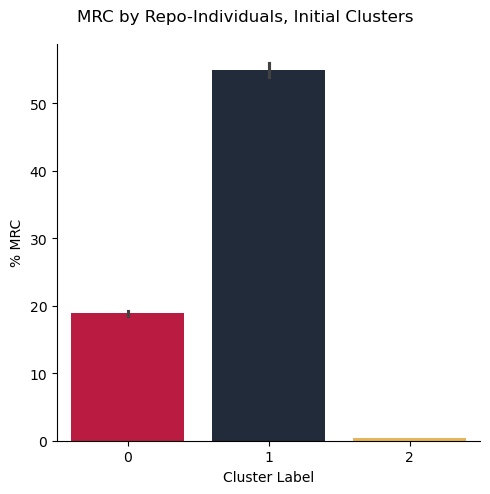

In [61]:
# pc_DC (percentage DEPTH of contribution across all of users' interactions)

g = sns.catplot(
    data=analysis_dataset, 
    x="cluster_labels", 
    y="pc_DC",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict, 
    legend = False,
)
#g.tick_params(axis='x', which='both', rotation=70)
#g.axes.legend().set_title("")
#g.add_legend(title="Clusters", loc='upper right',) #labels=['0', '1', '2']))
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle("MRC by Repo-Individuals, Initial Clusters")
g.axes[0,0].set_xlabel('Cluster Label')
g.axes[0,0].set_ylabel('% MRC')
plt.tight_layout()
#.axes.set_le
#plt.legend(title="Clusters", loc='upper left',) #labels=['0', '1', '2'])
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_mrc_cluster_{current_date_info}.pdf", **saveout_args) 
plt.show(g)

In [194]:
analysis_dataset.groupby("cluster_labels")["pc_DC"].mean()

cluster_labels
0    18.878235
1    54.889755
2     0.335229
Name: pc_DC, dtype: float64

In [109]:
analysis_dataset.groupby("breadth_interactions")["pc_DC"].mean()

breadth_interactions
1     0.128035
2     0.346193
3     1.108746
4     2.157190
5     8.375623
6    18.404694
Name: pc_DC, dtype: float64

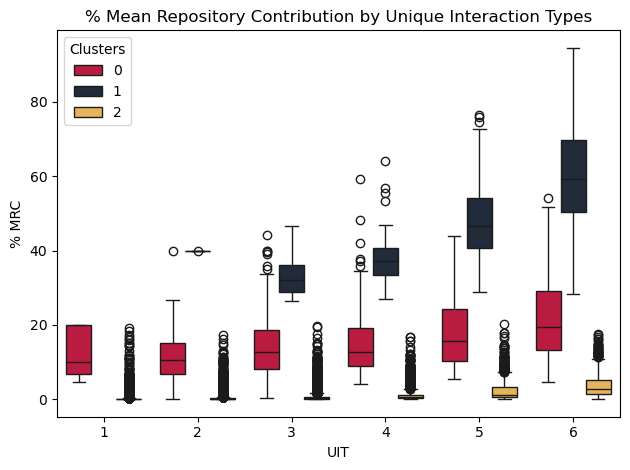

In [63]:
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
g = sns.boxplot(data=analysis_dataset,
    x="breadth_interactions", 
    y="pc_DC",
    hue="cluster_labels",
    #notch=True, # this param from matplotlib gives CI around the median: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html
    palette = label_color_dict, )
g.set_title("% Mean Repository Contribution by Unique Interaction Types")
g.set_xlabel("UIT")
g.set_ylabel("% MRC")
plt.legend(title="Clusters", loc='upper left',)# labels=[0,1,2])
plt.tight_layout()
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_uit_mrc_cluster_{current_date_info}.pdf", **saveout_args) 
plt.show(g)


In [111]:
analysis_dataset

,cluster_labels,repo_name,author_username,n_of_commit_creators,n_commits,n_changes,mean_n_changes,median_n_changes_changed,std_n_changes_changed,n_files_changed,...,which_interactions,breadth_interactions,pc_pull_request_created,pc_pull_request_closed,pc_commit_created,pc_issue_created,pc_issue_closed,pc_sum_n_interactions,pc_interaction_days,pc_DC
0,2,WIPACrepo/iceprod,actions-user,12.0,7.0,40.0,5.714286,5.0,1.253566,14.0,...,commit_created,1,0.000000,0.000000,0.258207,0.000000,0.000000,0.199430,0.730689,0.051641
1,2,WIPACrepo/iceprod,alemsh,12.0,1.0,151.0,151.000000,151.0,NaN,6.0,...,"commit_created, pull_request_created, pull_req...",4,0.751880,0.757576,0.036887,0.000000,0.000000,0.085470,0.104384,0.235878
2,2,WIPACrepo/iceprod,carlwitt,12.0,1.0,2.0,2.000000,2.0,NaN,1.0,...,"commit_created, pull_request_created, issue_cr...",3,0.751880,0.000000,0.036887,0.340136,0.000000,0.085470,0.208768,0.225781
3,2,WIPACrepo/iceprod,dependabot[bot],12.0,10.0,24.0,2.400000,2.0,1.264911,12.0,...,"commit_created, pull_request_created, pull_req...",3,17.293233,6.060606,0.405754,0.000000,0.000000,1.196581,2.818372,3.539797
4,1,WIPACrepo/iceprod,dsschult,12.0,2275.0,1117264.0,491.105055,10.0,4118.362826,10371.0,...,"pull_request_closed, issue_created, commit_cre...",6,72.932331,90.151515,91.479159,89.795918,87.916667,90.341880,77.244259,85.299815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115169,2,ncihtan/data-models,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,"issue_closed, assigned_issue",2,0.000000,0.000000,0.000000,0.000000,0.438596,0.102881,0.237530,0.160712
115170,2,INCATools/ontology-access-kit,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,"issue_closed, assigned_issue",2,0.000000,0.000000,0.000000,0.000000,0.510204,0.044723,0.134228,0.324263
115171,2,nf-core/epitopeprediction,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,"issue_closed, assigned_issue",2,0.000000,0.000000,0.000000,0.000000,1.785714,0.067935,0.248139,1.409774
115172,2,Ouranosinc/raven,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,"issue_closed, assigned_issue",2,0.000000,0.000000,0.000000,0.000000,0.436681,0.090580,0.188324,0.183955


In [34]:
sklearn_hcwdata = analysis_dataset 

### how does pc_DC vary between clusters? 

In [113]:
sklearn_hcwdata.pc_DC.describe()

count    115174.000000
mean          1.046275
std           5.363220
min           0.000651
25%           0.021680
50%           0.066890
75%           0.235294
max          94.550828
Name: pc_DC, dtype: float64

pc_DC across each cluster


,breadth_interactions
cluster_labels,
0,5.022910
1,5.524286
2,1.669729


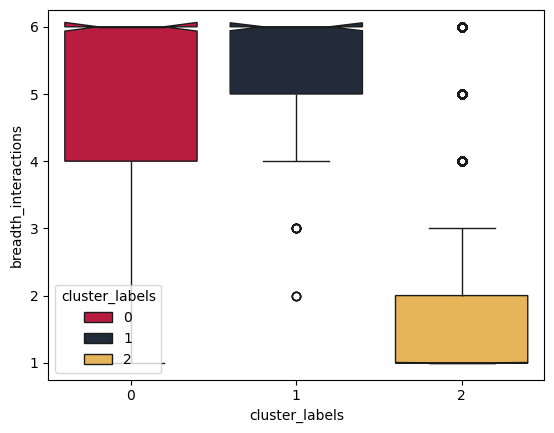

In [35]:
sns.boxplot(data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="breadth_interactions",
    hue="cluster_labels", palette=label_color_dict)
print("pc_DC across each cluster")
sklearn_hcwdata.groupby("cluster_labels")[["breadth_interactions"]].mean() # proves UIT LOW VS HIGH.

pc_DC across each cluster


,pc_DC
cluster_labels,
0,18.878235
1,54.889755
2,0.335229


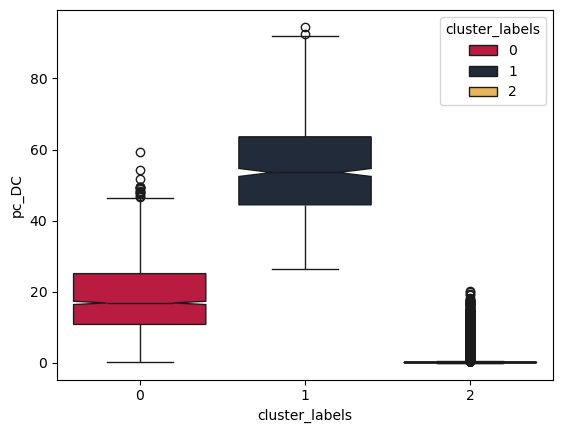

In [36]:
sns.boxplot(data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_DC",
    hue="cluster_labels",palette=label_color_dict)
print("pc_DC across each cluster")
sklearn_hcwdata.groupby("cluster_labels")[["pc_DC"]].mean()

In [115]:
sklearn_hcwdata.columns


Index(['cluster_labels', 'repo_name', 'author_username',
       'n_of_commit_creators', 'n_commits', 'n_changes', 'mean_n_changes',
       'median_n_changes_changed', 'std_n_changes_changed', 'n_files_changed',
       'mean_n_files', 'median_n_files_changed', 'std_n_files_changed',
       'hattori_lanza_size_cat_tiny', 'hattori_lanza_size_cat_small',
       'hattori_lanza_size_cat_medium', 'hattori_lanza_size_cat_large',
       'hattori_lanza_content_cat_forward_engineering',
       'hattori_lanza_content_cat_reengineering',
       'hattori_lanza_content_cat_corrective_engineering',
       'hattori_lanza_content_cat_management',
       'hattori_lanza_content_cat_empty_message',
       'hattori_lanza_content_cat_no_categorisation', 'vasilescu_category_doc',
       'vasilescu_category_img', 'vasilescu_category_l10n',
       'vasilescu_category_ui', 'vasilescu_category_media',
       'vasilescu_category_code', 'vasilescu_category_meta',
       'vasilescu_category_config', 'vasilescu_categ

pc_DC across breadth_interactions by Cluster


pc_DC
breadth_interactions cluster_labels           
1                    0               12.846896
                     2                0.121452
2                    0               11.962243
                     1               39.937759
                     2                0.297116
3                    0               14.259033
                     1               33.131278
                     2                0.723311
4                    0               15.075677
                     1               39.069735
                     2                1.090832
5                    0               17.798280
                     1               47.816358
                     2                2.206906
6                    0               21.836160
                     1               60.337171
                     2                3.590891

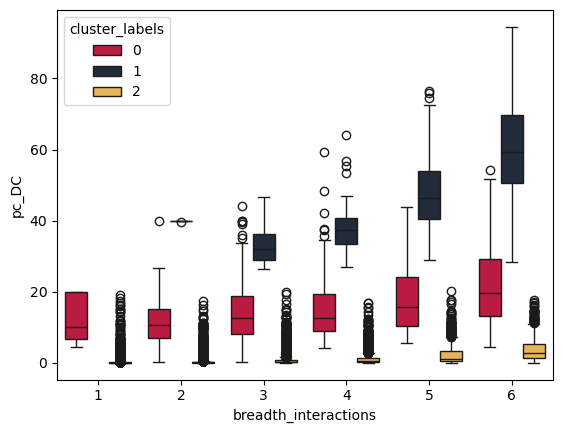

In [116]:
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
sns.boxplot(data=sklearn_hcwdata,
    x="breadth_interactions", 
    y="pc_DC",
    hue="cluster_labels", 
    palette = label_color_dict)
print("pc_DC across breadth_interactions by Cluster")
sklearn_hcwdata.groupby(["breadth_interactions", "cluster_labels"])[["pc_DC"]].mean()

mean pc_DC across each clusters


,pc_DC
cluster_labels,
0,18.878235
1,54.889755
2,0.335229


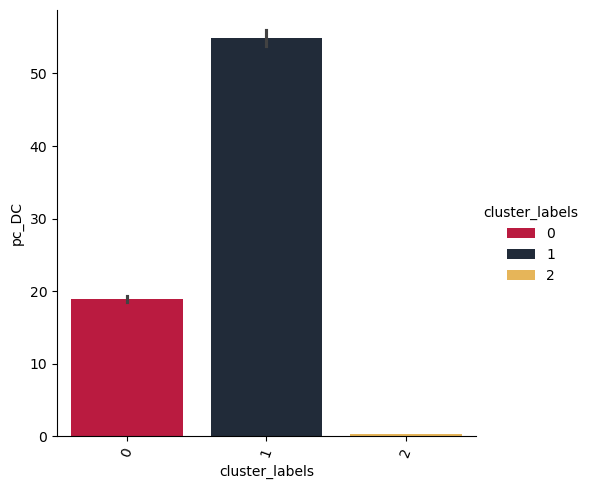

In [117]:
# pc_DC (percentage DEPTH of contribution across all of users' interactions)

g = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_DC",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict 
)
g.tick_params(axis='x', which='both', rotation=70)
print("mean pc_DC across each clusters")

sklearn_hcwdata.groupby("cluster_labels")[["pc_DC"]].mean()

cluster x % of repo's commits


,pc_commit_created
cluster_labels,
0,15.450765
1,57.460602
2,0.239553


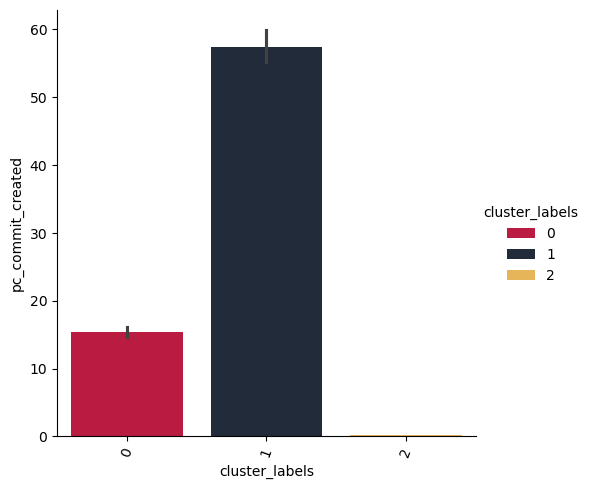

In [118]:
# # cluster 1 has highest pc of repo's commits values, 0 is minimal. 
g = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_commit_created",
    hue="cluster_labels", 
    kind="bar", 
    palette=label_color_dict,
    #rder=ordered_contributions_by_user_categories
)
g.tick_params(axis='x', which='both', rotation=70)
print("cluster x % of repo's commits")
sklearn_hcwdata.groupby("cluster_labels")[["pc_commit_created"]].mean()

#### pc_commit_created: \~59% more of repos' commits by cluster 1 (\~62%) vs Cluster 0 (~3%)

cluster x % of repo's issues created


,pc_issue_created
cluster_labels,
0,14.820810
1,39.505821
2,0.562923


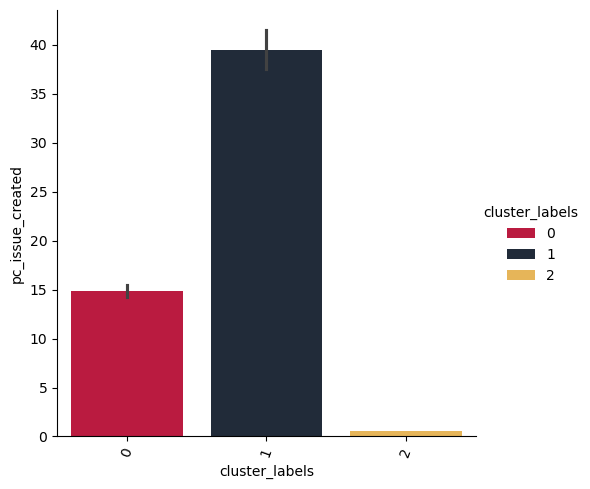

In [119]:
# # cluster 1 has highest pc of repo's issue ticket creation  values, 0 is minimal
g = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_issue_created",
    hue="cluster_labels", 
    kind="bar", 
    palette=label_color_dict,
    #rder=ordered_contributions_by_user_categories
)
g.tick_params(axis='x', which='both', rotation=70)
print("cluster x % of repo's issues created")
sklearn_hcwdata.groupby("cluster_labels")[["pc_issue_created"]].mean()

cluster x % of repo's issues closed


,pc_issue_closed
cluster_labels,
0,20.451390
1,76.977509
2,0.192834


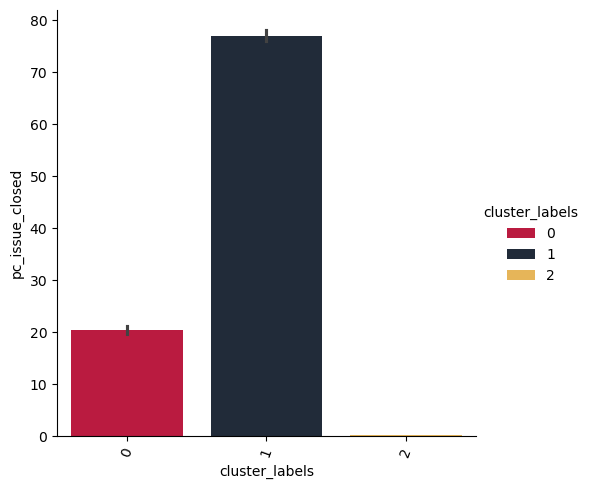

In [120]:
# # cluster 1 has highest pc of repo's issue ticket creation  values, 0 is minimal
g = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_issue_closed",
    hue="cluster_labels", 
    kind="bar", 
    palette=label_color_dict, 
    #rder=ordered_contributions_by_user_categories
)
g.tick_params(axis='x', which='both', rotation=70)
print("cluster x % of repo's issues closed")
sklearn_hcwdata.groupby("cluster_labels")[["pc_issue_closed"]].mean()

cluster x % of repo's issues assigned to user


,pc_issues_assigned_of_assigned
cluster_labels,
0,25.674216
1,59.045096
2,0.187007


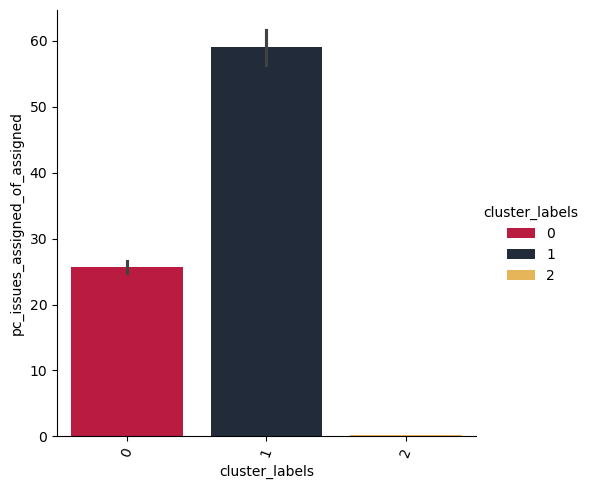

In [121]:
# assignment pcs
g = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_issues_assigned_of_assigned",
    hue="cluster_labels", 
    kind="bar", 
    palette=label_color_dict,
    #rder=ordered_contributions_by_user_categories
)
g.tick_params(axis='x', which='both', rotation=70)
print("cluster x % of repo's issues assigned to user")
sklearn_hcwdata.groupby("cluster_labels")[["pc_issues_assigned_of_assigned"]].mean()

cluster x % of repo's pull requests created by user


,pc_pull_request_created
cluster_labels,
0,17.993994
1,41.459747
2,0.493826


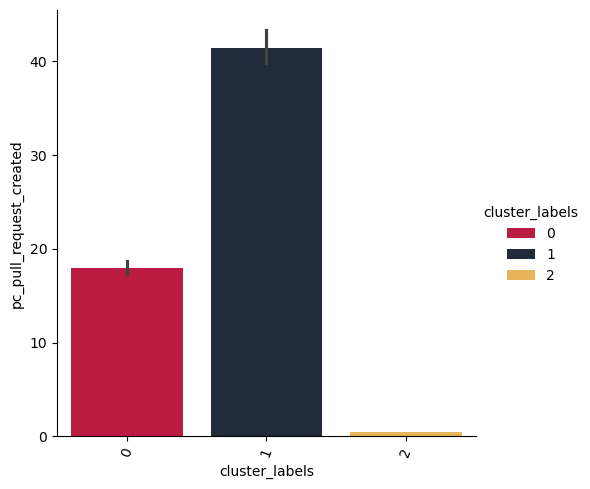

In [122]:
# assignment pcs
g = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_pull_request_created",
    hue="cluster_labels", 
    kind="bar", 
    palette=label_color_dict,
    #rder=ordered_contributions_by_user_categories
)
g.tick_params(axis='x', which='both', rotation=70)
print("cluster x % of repo's pull requests created by user")
sklearn_hcwdata.groupby("cluster_labels")[["pc_pull_request_created"]].mean()

cluster x % of repo's pull requests closed by user


,pc_pull_request_closed
cluster_labels,
0,23.125001
1,78.830223
2,0.141536


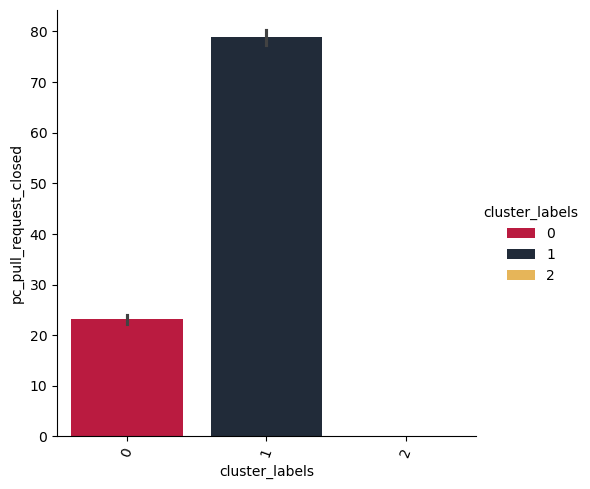

In [123]:
# assignment pcs
g = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_pull_request_closed",
    hue="cluster_labels", 
    kind="bar", 
    palette=label_color_dict,
    #rder=ordered_contributions_by_user_categories
)
g.tick_params(axis='x', which='both', rotation=70)
print("cluster x % of repo's pull requests closed by user")
sklearn_hcwdata.groupby("cluster_labels")[["pc_pull_request_closed"]].mean()

#### Number of repo committers: `n_of_commit_creators`

In [124]:
sklearn_hcwdata.groupby("cluster_labels")['repo_name'].nunique() # how many repos fall into each category?  

cluster_labels
0    1003
1     700
2    1276
Name: repo_name, dtype: int64

cluster labels x mean number of repo commit creators
   cluster_labels  mean_n_of_commit_creators
0               0                  26.985951
1               1                  19.181661
2               2                  25.397672


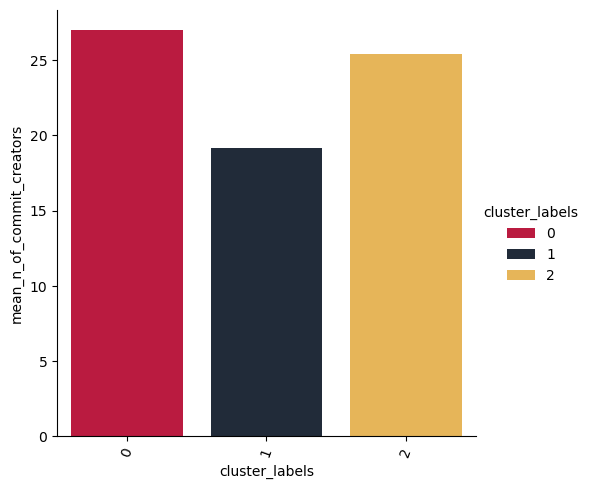

In [125]:
# THIS IS A REALLY HACKY WAY OF PLOTTING THE ACTUAL MEAN APPX REPO SIZES. 
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} 
approx_repo_sizes = pd.DataFrame({
    "cluster_labels": [0, 1, 2], 
    "mean_n_of_commit_creators": [sklearn_hcwdata.query("cluster_labels == 0").groupby("repo_name")[["n_of_commit_creators"]].mean().mean().item() , sklearn_hcwdata.query("cluster_labels == 1").groupby("repo_name")[["n_of_commit_creators"]].mean().mean().item(), sklearn_hcwdata.query("cluster_labels == 2").groupby("repo_name")[["n_of_commit_creators"]].mean().mean().item() ]
})

#sklearn_hcwdata.query("cluster_labels == 1").groupby("repo_name")[["n_of_commit_creators"]].mean().mean()
  # double .mean() gets first the mean of all n_of_commit_creators per repo_name 
    # (which is legit, since it's the same for each dev inside it) 
  # THEN it gets the mean of THOSE MEANS (ie for the cluster group)
  # THEN .item gets the value afterwards 

g = sns.catplot(
    data=approx_repo_sizes, 
    x="cluster_labels", 
    y="mean_n_of_commit_creators",
    hue="cluster_labels", 
    kind="bar", 
    palette=label_color_dict,
)
g.tick_params(axis='x', which='both', rotation=70)
print("cluster labels x mean number of repo commit creators")
print(approx_repo_sizes)

Users from different sizes of n_of_commit_creators counts, shown with cluster labels  


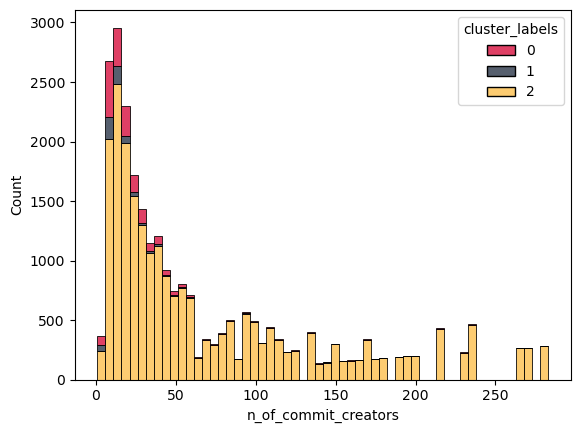

In [126]:
# users from different sizes of n_of_commit_creators counts, shown with cluster labels  
ax = sns.histplot(
    data=sklearn_hcwdata, 
    x="n_of_commit_creators", 
    #y="cluster_labels",
    hue="cluster_labels", 
    binwidth=5,
    #alpha=1, 
    multiple="stack", 
    palette=label_color_dict,
)
#ax.tick_params(axis='x', which='both', rotation=90)
print("Users from different sizes of n_of_commit_creators counts, shown with cluster labels  ")
# spread of cluster 1 repo 'appx sizes' is much lower, but sample is TINY comparatively

Counts of users in repos of varying sizes + cluster label distributions


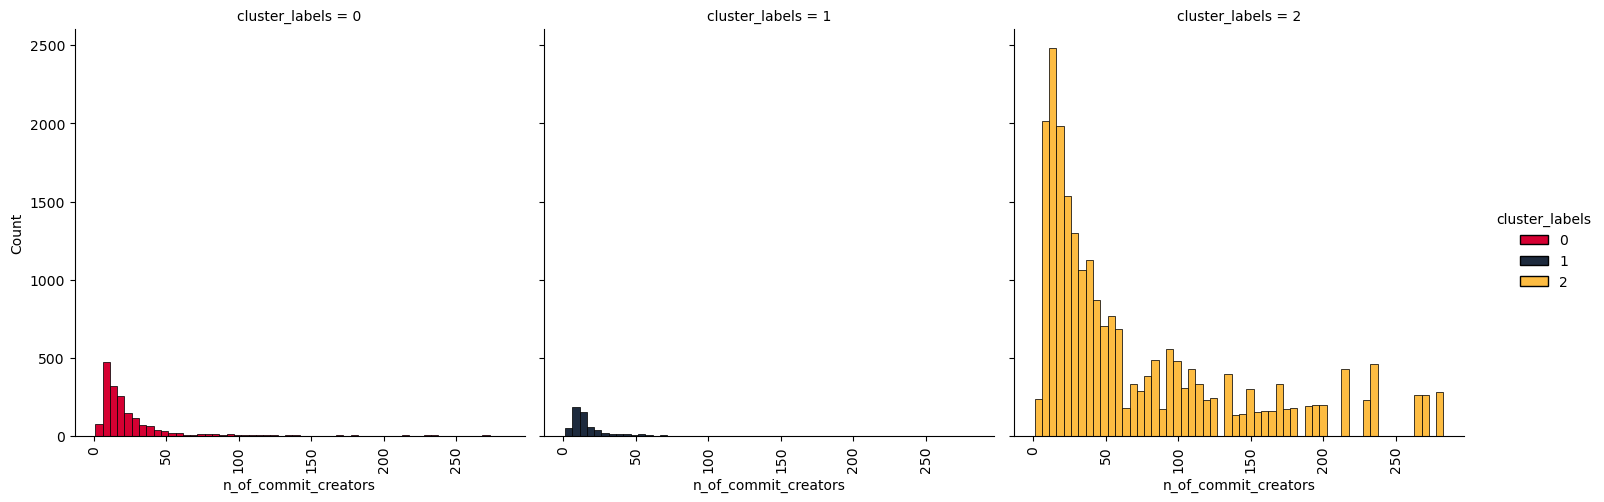

In [127]:
# Counts of users in repos of varying sizes + cluster label distributions
ax = sns.displot(
    data=sklearn_hcwdata, 
    #x="repo_name", 
    x="n_of_commit_creators",
    col="cluster_labels",
    hue="cluster_labels", 
    binwidth=5,
    alpha=1, 
    palette=label_color_dict,
    #multiple="stack", 
    #kde="true"
)
ax.tick_params(axis='x', which='both', rotation=90)
print("Counts of users in repos of varying sizes + cluster label distributions")

### CBRIs across clusters

How are project-individuals with different CBRI values spread across the clusters? 

count of breadth_interactions across 'clusters'


breadth_interactions
cluster_labels breadth_interactions                      
0              1                                       34
               2                                      117
               3                                      195
               4                                      249
               5                                      582
               6                                     1180
1              2                                        4
               3                                       12
               4                                       30
               5                                      221
               6                                      433
2              1                                    65691
               2                                    30920
               3                                     7650
               4                                     4055
               5                                     2302
               6                                     1499

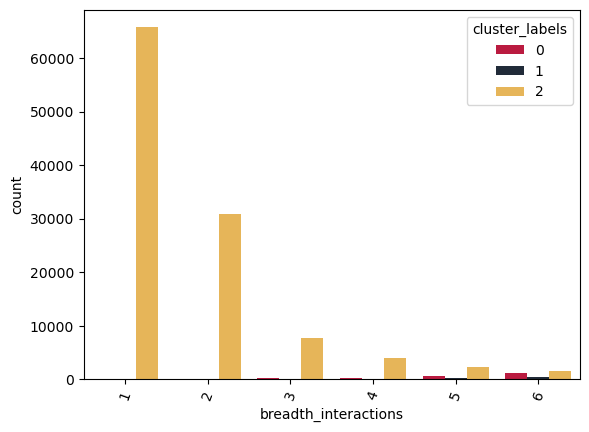

In [128]:
g = sns.countplot(
    data=sklearn_hcwdata, 
    x="breadth_interactions", 
    hue="cluster_labels", 
    palette=label_color_dict,
)
g.tick_params(axis='x', which='both', rotation=70)
print("count of breadth_interactions across 'clusters'")

sklearn_hcwdata.groupby(["cluster_labels", "breadth_interactions"])[["breadth_interactions"]].count()

count of breadth_interactions across 'clusters'


breadth_interactions
cluster_labels breadth_interactions                      
0              1                                       34
               2                                      117
               3                                      195
               4                                      249
               5                                      582
               6                                     1180
1              2                                        4
               3                                       12
               4                                       30
               5                                      221
               6                                      433
2              1                                    65691
               2                                    30920
               3                                     7650
               4                                     4055
               5                                     2302
               6                                     1499

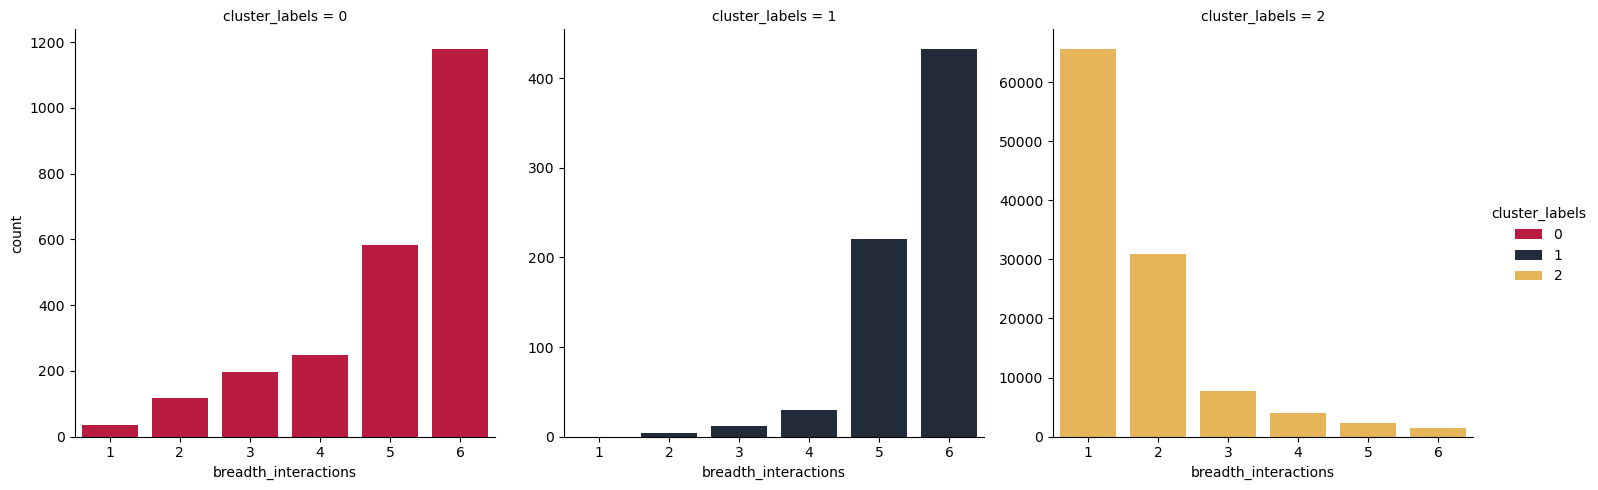

In [64]:
g = sns.catplot(
    data=sklearn_hcwdata, 
    x="breadth_interactions", 
    hue="cluster_labels", 
    palette=label_color_dict,
    col="cluster_labels",
    kind="count",
    sharey=False,
)
g.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_initial_cluster_breadth_counts_cols_{current_date_info}.pdf", **saveout_args)
#g.tick_params(axis='x', which='both', rotation=70)


print("count of breadth_interactions across 'clusters'")

sklearn_hcwdata.groupby(["cluster_labels", "breadth_interactions"])[["breadth_interactions"]].count()

In [130]:
sklearn_hcwdata.cluster_labels.value_counts()

cluster_labels
2    112117
0      2357
1       700
Name: count, dtype: int64

### Contribution-Type-Combos (contributions_by_user)

### Commit Classification Variations (HL- and V-)

#### HL-MANAGEMENT

# Percentage of user's commits which categorised as HL commit content category MANAGEMENT by cluster


,pc_HL-mgmt
cluster_labels,
0,28.923116
1,22.647573
2,20.009839


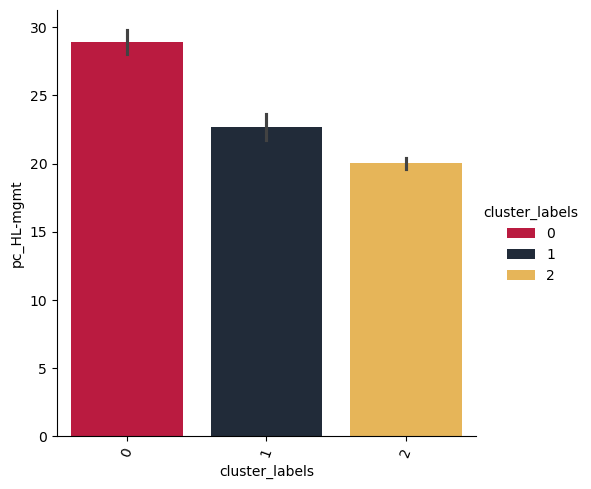

In [131]:
# Percentage of user's commits which categorised as HL commit content category MANAGEMENT
g = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_HL-mgmt",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict,
)
g.tick_params(axis='x', which='both', rotation=70)
print("# Percentage of user's commits which categorised as HL commit content category MANAGEMENT by cluster")
sklearn_hcwdata.groupby("cluster_labels")[["pc_HL-mgmt"]].mean()

#### V-DOCS

# Percentage of user's commits which categorised as V-cat Docs by cluster


,pc_V-doc
cluster_labels,
0,25.738420
1,25.041019
2,26.507203


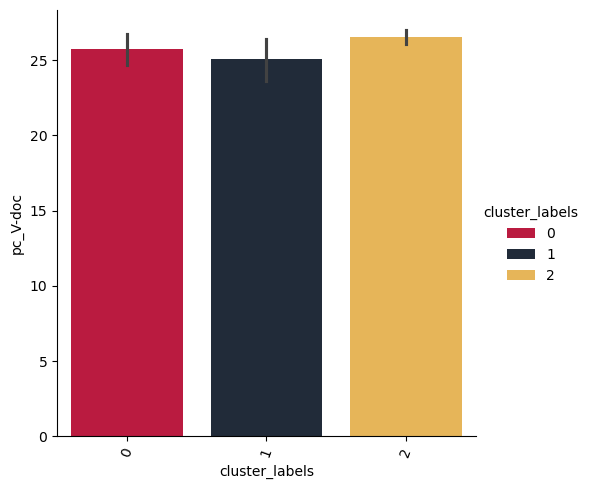

In [132]:
# Percentage of user's commits which categorised as V commit filetype category DOCS
g = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_V-doc",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict,
)
g.tick_params(axis='x', which='both', rotation=70)
print("# Percentage of user's commits which categorised as V-cat Docs by cluster")
sklearn_hcwdata.groupby("cluster_labels")[["pc_V-doc"]].mean()

#### HL-FORWARD-ENGINEERING

# Percentage of user's commits which categorised as HL-FWENG (Forward Engineering) by cluster


,pc_HL-fweng
cluster_labels,
0,13.642045
1,14.217357
2,16.387856


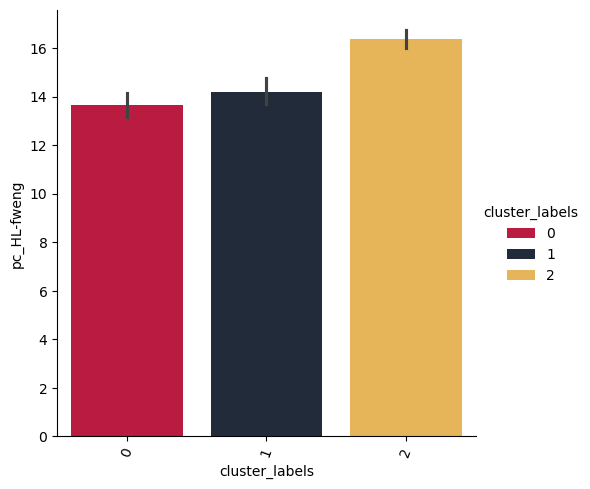

In [133]:
# Percentage of user's commits which categorised as HL commit content category FORWARD ENGINEERING
g = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_HL-fweng",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict,
)
g.tick_params(axis='x', which='both', rotation=70)
print("# Percentage of user's commits which categorised as HL-FWENG (Forward Engineering) by cluster")
sklearn_hcwdata.groupby("cluster_labels")[["pc_HL-fweng"]].mean()

#### V-CODE

# Percentage of user's commits which categorised as V-cat CODE by cluster


,pc_V-code
cluster_labels,
0,65.908775
1,65.096954
2,65.670152


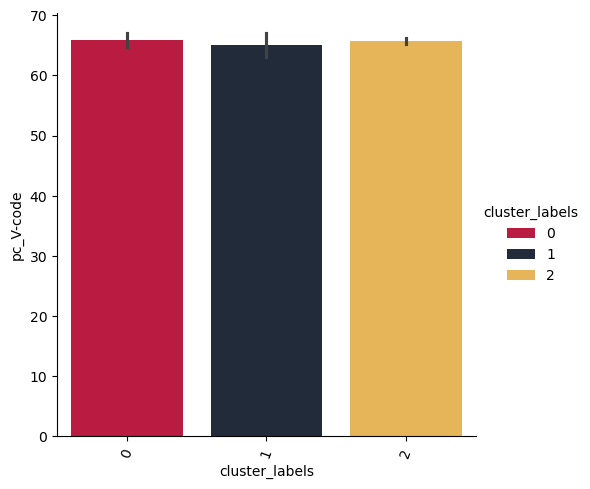

In [134]:
# Percentage of user's commits which categorised as V commit filetype category CODE
g = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_V-code",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict,
)
g.tick_params(axis='x', which='both', rotation=70)
print("# Percentage of user's commits which categorised as V-cat CODE by cluster")
sklearn_hcwdata.groupby("cluster_labels")[["pc_V-code"]].mean()

#### HL-RE-ENGINEERING 

# Percentage of user's commits which categorised as HL-RE-ENG (Re-Engineering) by cluster


,pc_HL-reeng
cluster_labels,
0,25.763393
1,26.689868
2,28.947871


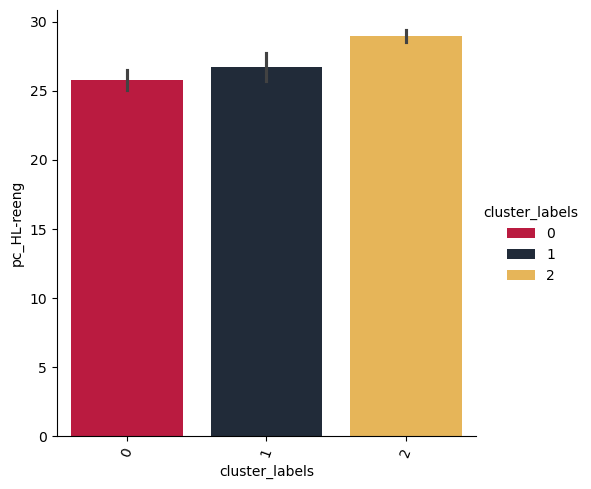

In [135]:
# Percentage of user's commits which categorised as HL commit content category RE-ENGINEERING
g = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_HL-reeng",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict,
)
g.tick_params(axis='x', which='both', rotation=70)
print("# Percentage of user's commits which categorised as HL-RE-ENG (Re-Engineering) by cluster")
sklearn_hcwdata.groupby("cluster_labels")[["pc_HL-reeng"]].mean()

#### HL-CORRECTIVE-ENGINEERING

# Percentage of user's commits which categorised as HL-CORR (Corrective-Engineering) by cluster


,pc_HL-corr
cluster_labels,
0,12.050669
1,13.414801
2,18.452978


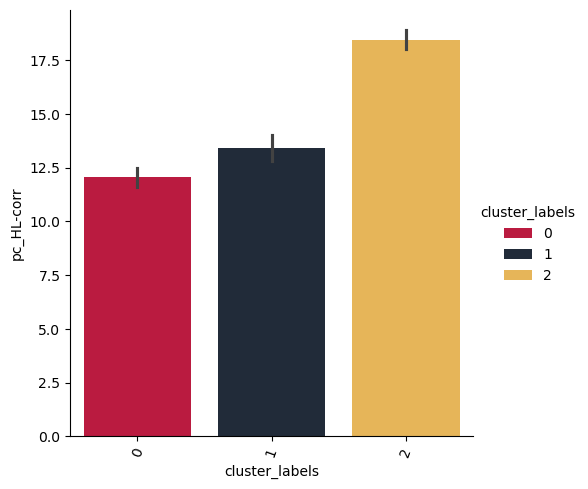

In [136]:
# Percentage of user's commits which categorised as HL commit content category CORRECTIVE-ENGINEERING
g = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_HL-corr",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict,
)
g.tick_params(axis='x', which='both', rotation=70)
print("# Percentage of user's commits which categorised as HL-CORR (Corrective-Engineering) by cluster")
sklearn_hcwdata.groupby("cluster_labels")[["pc_HL-corr"]].mean()

### HLs-cats

### HL-Cats

In [137]:
sklearn_hcwdata.groupby("cluster_labels")[['pc_HL-fweng', 'pc_HL-reeng', 'pc_HL-corr','pc_HL-mgmt']].mean()

,pc_HL-fweng,pc_HL-reeng,pc_HL-corr,pc_HL-mgmt
cluster_labels,,,,
0,13.642045,25.763393,12.050669,28.923116
1,14.217357,26.689868,13.414801,22.647573
2,16.387856,28.947871,18.452978,20.009839


In [138]:
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

def run_anova(variable, data):
        variable = variable
        df = analysis_dataset

        # One-Way ANOVA: 
        anova = f_oneway(
            df.groupby("cluster_labels")[variable].get_group(0),
            df.groupby("cluster_labels")[variable].get_group(1),
            df.groupby("cluster_labels")[variable].get_group(2),
        )

        print("\n")
        print(f"{anova}")


        # perform Tukey's test
        tukey = pairwise_tukeyhsd(endog=df[variable],
                                  groups=df['cluster_labels'],
                                  alpha=0.05)

        #display results
        print(tukey)

        print(f"For {variable}, anova result p-value is {anova.pvalue}; groups are significantly different = {anova.pvalue < 0.05}")
        print(f"For {variable}, Tukey HSD test result p-value is {tukey.pvalues}; groups are significantly different = {tukey.reject == True}")
        
        if anova.pvalue < 0.05:
            print(f">>>>>> {variable} ^^^ is significant <<<<<< \n ")

        return df.groupby("cluster_labels")[variable].mean()

In [139]:
run_anova("breadth_interactions", analysis_dataset)



F_onewayResult(statistic=16394.17266013766, pvalue=0.0)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     0      1   0.5014   0.0  0.3958   0.607   True
     0      2  -3.3532   0.0 -3.4042 -3.3021   True
     1      2  -3.8546   0.0 -3.9476 -3.7615   True
---------------------------------------------------
For breadth_interactions, anova result p-value is 0.0; groups are significantly different = True
For breadth_interactions, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
>>>>>> breadth_interactions ^^^ is significant <<<<<< 
 


cluster_labels
0    5.022910
1    5.524286
2    1.669729
Name: breadth_interactions, dtype: float64

In [140]:
tukey = pairwise_tukeyhsd(endog=df["breadth_interactions"],
                                  groups=df['cluster_labels'],
                                  alpha=0.05)
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
0,1,0.5014,0.0,0.3958,0.607,True
0,2,-3.3532,0.0,-3.4042,-3.3021,True
1,2,-3.8546,0.0,-3.9476,-3.7615,True


In [141]:
run_anova("pc_DC", analysis_dataset)



F_onewayResult(statistic=342100.14082319144, pvalue=0.0)
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
     0      1  36.0115   0.0  35.8061  36.2169   True
     0      2  -18.543   0.0 -18.6423 -18.4437   True
     1      2 -54.5545   0.0 -54.7354 -54.3736   True
-----------------------------------------------------
For pc_DC, anova result p-value is 0.0; groups are significantly different = True
For pc_DC, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
>>>>>> pc_DC ^^^ is significant <<<<<< 
 


cluster_labels
0    18.878235
1    54.889755
2     0.335229
Name: pc_DC, dtype: float64

In [142]:
list_of_vars = ['n_commits', 'n_changes', 'mean_n_changes',
       'median_n_changes_changed', 'std_n_changes_changed', 'n_files_changed',
       'mean_n_files', 'median_n_files_changed', 'std_n_files_changed',]

for var in list_of_vars:
    print(run_anova(variable=var, data=analysis_dataset))
    
# F_onewayResult(statistic=14544.082262946404, pvalue=0.0)
#   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
# ========================================================
# group1 group2  meandiff p-adj   lower     upper   reject
# --------------------------------------------------------
#      0      1   626.717   0.0  609.1739  644.2601   True
#      0      2 -330.1436   0.0 -338.6261  -321.661   True
#      1      2 -956.8606   0.0 -972.3128 -941.4084   True
# --------------------------------------------------------
# For n_commits, anova result p-value is 0.0; groups are significantly different = True
# For n_commits, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> n_commits ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    336.142978
# 1    962.860000
# 2      5.999402
# Name: n_commits, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For n_changes, anova result p-value is nan; groups are significantly different = False
# For n_changes, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    9.641295e+05
# 1    2.198393e+06
# 2    5.554633e+04
# Name: n_changes, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For mean_n_changes, anova result p-value is nan; groups are significantly different = False
# For mean_n_changes, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    3158.162905
# 1    1944.760013
# 2    1699.557282
# Name: mean_n_changes, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For median_n_changes_changed, anova result p-value is nan; groups are significantly different = False
# For median_n_changes_changed, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    761.803872
# 1     43.501730
# 2    692.851274
# Name: median_n_changes_changed, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For std_n_changes_changed, anova result p-value is nan; groups are significantly different = False
# For std_n_changes_changed, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    16271.910009
# 1    15692.172779
# 2     5684.936874
# Name: std_n_changes_changed, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For n_files_changed, anova result p-value is nan; groups are significantly different = False
# For n_files_changed, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    3027.520763
# 1    7035.212803
# 2     192.723614
# Name: n_files_changed, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For mean_n_files, anova result p-value is nan; groups are significantly different = False
# For mean_n_files, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    6.337150
# 1    5.747835
# 2    4.849972
# Name: mean_n_files, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For median_n_files_changed, anova result p-value is nan; groups are significantly different = False
# For median_n_files_changed, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    2.079686
# 1    1.706747
# 2    3.264573
# Name: median_n_files_changed, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For std_n_files_changed, anova result p-value is nan; groups are significantly different = False
# For std_n_files_changed, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    14.661404
# 1    14.951657
# 2     8.526055
# Name: std_n_files_changed, dtype: float64



F_onewayResult(statistic=14544.082262946404, pvalue=0.0)
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj   lower     upper   reject
--------------------------------------------------------
     0      1   626.717   0.0  609.1739  644.2601   True
     0      2 -330.1436   0.0 -338.6261  -321.661   True
     1      2 -956.8606   0.0 -972.3128 -941.4084   True
--------------------------------------------------------
For n_commits, anova result p-value is 0.0; groups are significantly different = True
For n_commits, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
>>>>>> n_commits ^^^ is significant <<<<<< 
 
cluster_labels
0    336.142978
1    962.860000
2      5.999402
Name: n_commits, dtype: float64


F_onewayResult(statistic=nan, pvalue=nan)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
     0

In [143]:
# list_of_vars = ['hattori_lanza_size_cat_tiny', 'hattori_lanza_size_cat_small',
#        'hattori_lanza_size_cat_medium', 'hattori_lanza_size_cat_large',]

# for var in list_of_vars:
#     print(run_anova(variable=var, data=analysis_dataset))

In [144]:
list_of_vars = ['hattori_lanza_content_cat_forward_engineering',
       'hattori_lanza_content_cat_reengineering',
       'hattori_lanza_content_cat_corrective_engineering',
       'hattori_lanza_content_cat_management',
       'hattori_lanza_content_cat_empty_message',
       'hattori_lanza_content_cat_no_categorisation', ]
for var in list_of_vars:
    print(run_anova(variable=var, data=analysis_dataset))



F_onewayResult(statistic=nan, pvalue=nan)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
     0      1      nan   nan   nan   nan  False
     0      2      nan   nan   nan   nan  False
     1      2      nan   nan   nan   nan  False
-----------------------------------------------
For hattori_lanza_content_cat_forward_engineering, anova result p-value is nan; groups are significantly different = False
For hattori_lanza_content_cat_forward_engineering, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
cluster_labels
0     57.575196
1    163.939446
2      4.007218
Name: hattori_lanza_content_cat_forward_engineering, dtype: float64


F_onewayResult(statistic=nan, pvalue=nan)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
     0      1 

In [145]:
list_of_vars = [ 'vasilescu_category_doc',
       'vasilescu_category_img', 'vasilescu_category_l10n',
       'vasilescu_category_ui', 'vasilescu_category_media',
       'vasilescu_category_code', 'vasilescu_category_meta',
       'vasilescu_category_config', 'vasilescu_category_build',
       'vasilescu_category_devdoc', 'vasilescu_category_db',
       'vasilescu_category_test', 'vasilescu_category_unknown',]
for var in list_of_vars:
    print(run_anova(variable=var, data=analysis_dataset))



F_onewayResult(statistic=nan, pvalue=nan)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
     0      1      nan   nan   nan   nan  False
     0      2      nan   nan   nan   nan  False
     1      2      nan   nan   nan   nan  False
-----------------------------------------------
For vasilescu_category_doc, anova result p-value is nan; groups are significantly different = False
For vasilescu_category_doc, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
cluster_labels
0     97.744669
1    251.688581
2      5.489194
Name: vasilescu_category_doc, dtype: float64


F_onewayResult(statistic=nan, pvalue=nan)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
     0      1      nan   nan   nan   nan  False
     0      2      nan   nan   nan 

In [146]:
list_of_vars = ['pc_HLs-tiny', 'pc_HLs-sml', 'pc_HLs-med', 'pc_HLs-lrg', ]
for var in list_of_vars:
    print(run_anova(variable=var, data=analysis_dataset))

# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_HLs-tiny, anova result p-value is nan; groups are significantly different = False
# For pc_HLs-tiny, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    83.021705
# 1    83.593859
# 2    88.505708
# Name: pc_HLs-tiny, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_HLs-sml, anova result p-value is nan; groups are significantly different = False
# For pc_HLs-sml, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    12.997186
# 1    13.025529
# 2     8.878404
# Name: pc_HLs-sml, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_HLs-med, anova result p-value is nan; groups are significantly different = False
# For pc_HLs-med, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    3.174114
# 1    2.743674
# 2    1.984785
# Name: pc_HLs-med, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_HLs-lrg, anova result p-value is nan; groups are significantly different = False
# For pc_HLs-lrg, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    0.806996
# 1    0.636938
# 2    0.631103
# Name: pc_HLs-lrg, dtype: float64



F_onewayResult(statistic=nan, pvalue=nan)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
     0      1      nan   nan   nan   nan  False
     0      2      nan   nan   nan   nan  False
     1      2      nan   nan   nan   nan  False
-----------------------------------------------
For pc_HLs-tiny, anova result p-value is nan; groups are significantly different = False
For pc_HLs-tiny, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
cluster_labels
0    83.021705
1    83.593859
2    88.505708
Name: pc_HLs-tiny, dtype: float64


F_onewayResult(statistic=nan, pvalue=nan)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
     0      1      nan   nan   nan   nan  False
     0      2      nan   nan   nan   nan  False
     1      2      nan 

In [147]:
list_of_vars = ['pc_HL-fweng', 'pc_HL-reeng', 'pc_HL-corr', 'pc_HL-mgmt', 'pc_HL-empty', 'pc_HL-nocat',]
for var in list_of_vars:
    print(run_anova(variable=var, data=analysis_dataset))

    


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_HL-fweng, anova result p-value is nan; groups are significantly different = False
# For pc_HL-fweng, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    13.642045
# 1    14.217357
# 2    16.387856
# Name: pc_HL-fweng, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_HL-reeng, anova result p-value is nan; groups are significantly different = False
# For pc_HL-reeng, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    25.763393
# 1    26.689868
# 2    28.947871
# Name: pc_HL-reeng, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_HL-corr, anova result p-value is nan; groups are significantly different = False
# For pc_HL-corr, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    12.050669
# 1    13.414801
# 2    18.452978
# Name: pc_HL-corr, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_HL-mgmt, anova result p-value is nan; groups are significantly different = False
# For pc_HL-mgmt, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    28.923116
# 1    22.647573
# 2    20.009839
# Name: pc_HL-mgmt, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_HL-empty, anova result p-value is nan; groups are significantly different = False
# For pc_HL-empty, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    0.025347
# 1    0.018985
# 2    0.015514
# Name: pc_HL-empty, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_HL-nocat, anova result p-value is nan; groups are significantly different = False
# For pc_HL-nocat, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    19.595430
# 1    23.011416
# 2    16.185942
# Name: pc_HL-nocat, dtype: float64



F_onewayResult(statistic=nan, pvalue=nan)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
     0      1      nan   nan   nan   nan  False
     0      2      nan   nan   nan   nan  False
     1      2      nan   nan   nan   nan  False
-----------------------------------------------
For pc_HL-fweng, anova result p-value is nan; groups are significantly different = False
For pc_HL-fweng, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
cluster_labels
0    13.642045
1    14.217357
2    16.387856
Name: pc_HL-fweng, dtype: float64


F_onewayResult(statistic=nan, pvalue=nan)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
     0      1      nan   nan   nan   nan  False
     0      2      nan   nan   nan   nan  False
     1      2      nan 

In [148]:
list_of_vars = ['pc_V-doc', 'pc_V-code', 'pc_V-confg', 'pc_V-build', 'pc_V-dvdoc',
       'pc_V-test', 'pc_V-meta', 'pc_V-img', 'pc_V-l10n', 'pc_V-ui',
       'pc_V-media', 'pc_V-nocat',]
for var in list_of_vars:
    print(run_anova(variable=var, data=analysis_dataset))
    


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_V-doc, anova result p-value is nan; groups are significantly different = False
# For pc_V-doc, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    25.738420
# 1    25.041019
# 2    26.507203
# Name: pc_V-doc, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_V-code, anova result p-value is nan; groups are significantly different = False
# For pc_V-code, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    65.908775
# 1    65.096954
# 2    65.670152
# Name: pc_V-code, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_V-confg, anova result p-value is nan; groups are significantly different = False
# For pc_V-confg, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    0.868115
# 1    1.030166
# 2    0.548866
# Name: pc_V-confg, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_V-build, anova result p-value is nan; groups are significantly different = False
# For pc_V-build, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    0.860608
# 1    0.817470
# 2    0.592421
# Name: pc_V-build, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_V-dvdoc, anova result p-value is nan; groups are significantly different = False
# For pc_V-dvdoc, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    0.602130
# 1    0.447810
# 2    0.352957
# Name: pc_V-dvdoc, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_V-test, anova result p-value is nan; groups are significantly different = False
# For pc_V-test, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    0.419844
# 1    0.658751
# 2    0.447791
# Name: pc_V-test, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_V-meta, anova result p-value is nan; groups are significantly different = False
# For pc_V-meta, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    0.000101
# 1    0.000311
# 2    0.000065
# Name: pc_V-meta, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_V-img, anova result p-value is nan; groups are significantly different = False
# For pc_V-img, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    0.102183
# 1    0.165531
# 2    0.116010
# Name: pc_V-img, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_V-l10n, anova result p-value is nan; groups are significantly different = False
# For pc_V-l10n, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    0.371590
# 1    0.193834
# 2    0.372238
# Name: pc_V-l10n, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_V-ui, anova result p-value is nan; groups are significantly different = False
# For pc_V-ui, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    0.093707
# 1    0.184245
# 2    0.113731
# Name: pc_V-ui, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_V-media, anova result p-value is nan; groups are significantly different = False
# For pc_V-media, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    0.112203
# 1    0.063251
# 2    0.076541
# Name: pc_V-media, dtype: float64


# F_onewayResult(statistic=nan, pvalue=nan)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===============================================
# group1 group2 meandiff p-adj lower upper reject
# -----------------------------------------------
#      0      1      nan   nan   nan   nan  False
#      0      2      nan   nan   nan   nan  False
#      1      2      nan   nan   nan   nan  False
# -----------------------------------------------
# For pc_V-nocat, anova result p-value is nan; groups are significantly different = False
# For pc_V-nocat, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
# cluster_labels
# 0    4.673643
# 1    6.175811
# 2    5.059490
# Name: pc_V-nocat, dtype: float64



F_onewayResult(statistic=nan, pvalue=nan)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
     0      1      nan   nan   nan   nan  False
     0      2      nan   nan   nan   nan  False
     1      2      nan   nan   nan   nan  False
-----------------------------------------------
For pc_V-doc, anova result p-value is nan; groups are significantly different = False
For pc_V-doc, Tukey HSD test result p-value is [nan nan nan]; groups are significantly different = [False False False]
cluster_labels
0    25.738420
1    25.041019
2    26.507203
Name: pc_V-doc, dtype: float64


F_onewayResult(statistic=nan, pvalue=nan)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
     0      1      nan   nan   nan   nan  False
     0      2      nan   nan   nan   nan  False
     1      2      nan   nan   n

### V-Cats

In [149]:
sklearn_hcwdata.groupby("cluster_labels")[['pc_V-code','pc_V-doc', 'pc_V-dvdoc', 'pc_V-confg', 'pc_V-build','pc_V-test']].mean()

,pc_V-code,pc_V-doc,pc_V-dvdoc,pc_V-confg,pc_V-build,pc_V-test
cluster_labels,,,,,,
0,65.908775,25.738420,0.602130,0.868115,0.860608,0.419844
1,65.096954,25.041019,0.447810,1.030166,0.817470,0.658751
2,65.670152,26.507203,0.352957,0.548866,0.592421,0.447791


### Commit Size (more about depth)  

#### Raw n_commits: 

In [150]:
sklearn_hcwdata.groupby("cluster_labels")[["pc_n_commits"]].mean()  

,pc_n_commits
cluster_labels,
0,0.015715
1,0.045016
2,0.000280


In [151]:
sklearn_hcwdata.groupby("cluster_labels")[["pc_n_commits"]].describe() 
# pc_n_commits didn't need to be scaled for this clustering, and represents the average of users' contributions the repo, so this seems more likely to be legit?  

pc_n_commits                                               \
                      count      mean       std  min       25%       50%   
cluster_labels                                                             
0                    2357.0  0.015715  0.037015  0.0  0.000047  0.003927   
1                     700.0  0.045016  0.065754  0.0  0.005610  0.022839   
2                  112117.0  0.000280  0.003486  0.0  0.000000  0.000000   

                                    
                     75%       max  
cluster_labels                      
0               0.015008  0.531902  
1               0.055682  0.490292  
2               0.000000  0.422268

#### Commit Size: HLs-

In [152]:
sklearn_hcwdata.groupby("cluster_labels")[['pc_HLs-tiny', 'pc_HLs-sml', 'pc_HLs-med', 'pc_HLs-lrg']].mean()

,pc_HLs-tiny,pc_HLs-sml,pc_HLs-med,pc_HLs-lrg
cluster_labels,,,,
0,83.021705,12.997186,3.174114,0.806996
1,83.593859,13.025529,2.743674,0.636938
2,88.505708,8.878404,1.984785,0.631103


# Percentage of user's commits which categorised as HLs-TINY commit size by cluster


,pc_HLs-tiny
cluster_labels,
0,83.021705
1,83.593859
2,88.505708


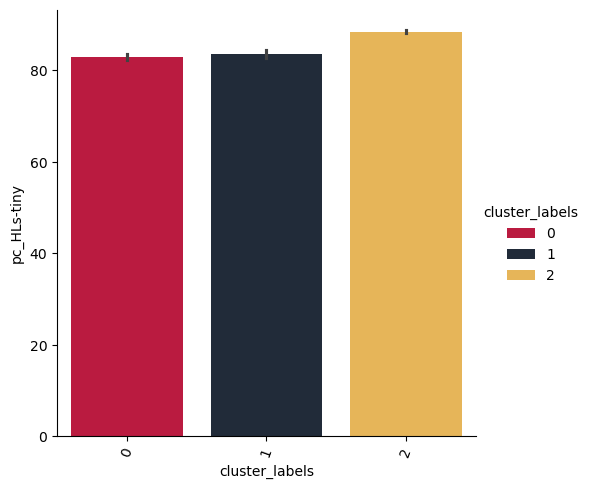

In [153]:
# Percentage of user's commits which categorised as HL commit size category TINY
ax = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_HLs-tiny",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict,
)
ax.tick_params(axis='x', which='both', rotation=70)
print("# Percentage of user's commits which categorised as HLs-TINY commit size by cluster")
sklearn_hcwdata.groupby("cluster_labels")[["pc_HLs-tiny"]].mean()

# Percentage of user's commits which categorised as HLs-SMALL commit size by cluster


,pc_HLs-sml
cluster_labels,
0,12.997186
1,13.025529
2,8.878404


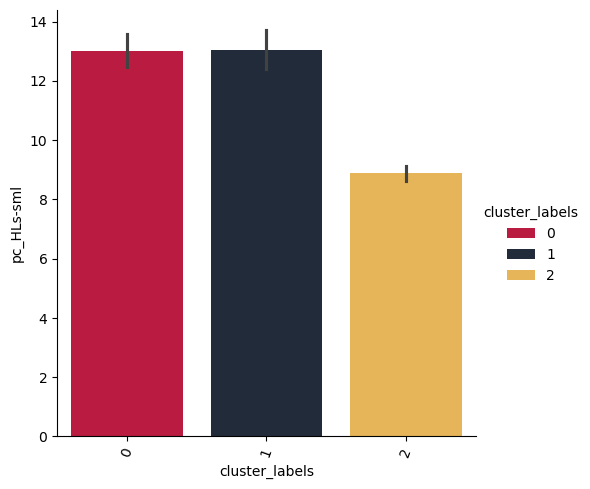

In [154]:
# Percentage of user's commits which categorised as HL commit size category SMALL
ax = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_HLs-sml",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict,
)
ax.tick_params(axis='x', which='both', rotation=70)
print("# Percentage of user's commits which categorised as HLs-SMALL commit size by cluster")
sklearn_hcwdata.groupby("cluster_labels")[["pc_HLs-sml"]].mean()

# Percentage of user's commits which categorised as HLs-MEDIUM commit size by cluster


,pc_HLs-med
cluster_labels,
0,3.174114
1,2.743674
2,1.984785


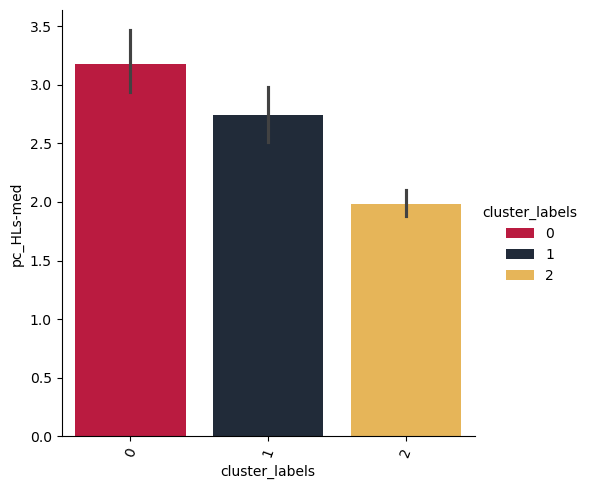

In [155]:
# Percentage of user's commits which categorised as HL commit size category MEDIUM
ax = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_HLs-med",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict,
)
ax.tick_params(axis='x', which='both', rotation=70)
print("# Percentage of user's commits which categorised as HLs-MEDIUM commit size by cluster")
sklearn_hcwdata.groupby("cluster_labels")[["pc_HLs-med"]].mean()

# Percentage of user's commits which categorised as HLs-LARGE commit size by cluster


,pc_HLs-lrg
cluster_labels,
0,0.806996
1,0.636938
2,0.631103


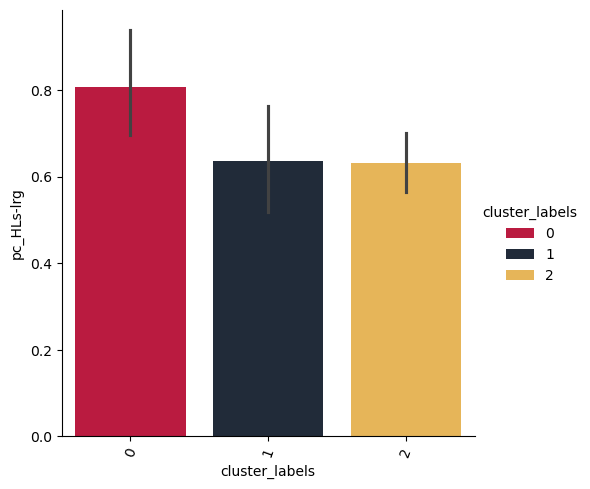

In [156]:
# Percentage of user's commits which categorised as HL commit size category LARGE
ax = sns.catplot(
    data=sklearn_hcwdata, 
    x="cluster_labels", 
    y="pc_HLs-lrg",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict,
)
ax.tick_params(axis='x', which='both', rotation=70)
print("# Percentage of user's commits which categorised as HLs-LARGE commit size by cluster")
sklearn_hcwdata.groupby("cluster_labels")[["pc_HLs-lrg"]].mean()

### (Raw) Number of Commits: `n_commits`: depth (commits) 

#### Number of Commits: n_commits

### DEPTH

In [157]:
sklearn_hcwdata.columns

Index(['cluster_labels', 'repo_name', 'author_username',
       'n_of_commit_creators', 'n_commits', 'n_changes', 'mean_n_changes',
       'median_n_changes_changed', 'std_n_changes_changed', 'n_files_changed',
       'mean_n_files', 'median_n_files_changed', 'std_n_files_changed',
       'hattori_lanza_size_cat_tiny', 'hattori_lanza_size_cat_small',
       'hattori_lanza_size_cat_medium', 'hattori_lanza_size_cat_large',
       'hattori_lanza_content_cat_forward_engineering',
       'hattori_lanza_content_cat_reengineering',
       'hattori_lanza_content_cat_corrective_engineering',
       'hattori_lanza_content_cat_management',
       'hattori_lanza_content_cat_empty_message',
       'hattori_lanza_content_cat_no_categorisation', 'vasilescu_category_doc',
       'vasilescu_category_img', 'vasilescu_category_l10n',
       'vasilescu_category_ui', 'vasilescu_category_media',
       'vasilescu_category_code', 'vasilescu_category_meta',
       'vasilescu_category_config', 'vasilescu_categ

mean_n_interactions_per_interaction_day across breadth_interactions by Cluster
                                     mean_n_interactions_per_interaction_day
breadth_interactions cluster_labels                                         
1                    0                                              1.225271
                     2                                              1.074928
2                    0                                              2.125601
                     1                                              1.000000
                     2                                              1.598897
3                    0                                              2.876324
                     1                                              3.620564
                     2                                              1.948590
4                    0                                              2.620057
                     1                                              3.5385

,mean_n_interactions_per_interaction_day
cluster_labels,
0,3.182809
1,4.079499
2,1.355539


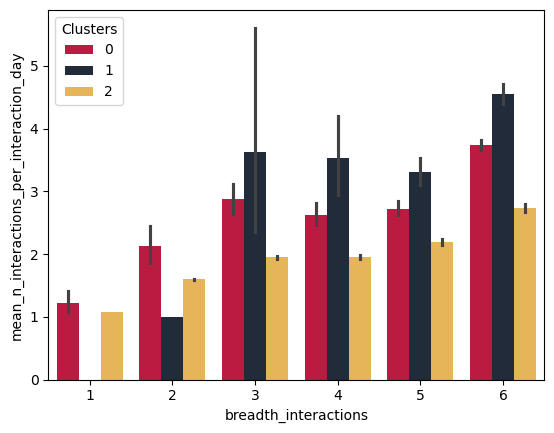

In [65]:
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
sns.barplot(data=sklearn_hcwdata.query("mean_n_interactions_per_interaction_day < 12.20"),
    x="breadth_interactions", 
    #x="cluster_labels",
    y="mean_n_interactions_per_interaction_day",
    hue="cluster_labels", 
    palette = label_color_dict)
plt.legend(title="Clusters", loc='best',) #labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
#plt.ylabel("%RC: Created-Closed Issues")
#plt.xlabel("Clusters")
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_initial_cluster_breadth_mean_n_interactions_interactionday_{current_date_info}.pdf", **saveout_args) 
print("mean_n_interactions_per_interaction_day across breadth_interactions by Cluster")
print(sklearn_hcwdata.query("mean_n_interactions_per_interaction_day < 12.20").groupby(["breadth_interactions", "cluster_labels"])[["mean_n_interactions_per_interaction_day"]].mean())
sklearn_hcwdata.query("mean_n_interactions_per_interaction_day < 12.20").groupby(["cluster_labels"])[["mean_n_interactions_per_interaction_day"]].mean()

## TIME

In [159]:
# interaction_days

#### mean_n_interactions_per_interaction_day: significantly different by breadth, cluster

mean_n_interactions_per_interaction_day across breadth_interactions by Cluster
                                     mean_n_interactions_per_interaction_day
breadth_interactions cluster_labels                                         
1                    0                                              1.225271
                     2                                              1.079066
2                    0                                             10.100204
                     1                                            132.250000
                     2                                              1.613697
3                    0                                              8.310719
                     1                                              3.620564
                     2                                              1.977881
4                    0                                              2.786429
                     1                                              3.5385

,mean_n_interactions_per_interaction_day
cluster_labels,
0,4.090222
1,4.925348
2,1.365116


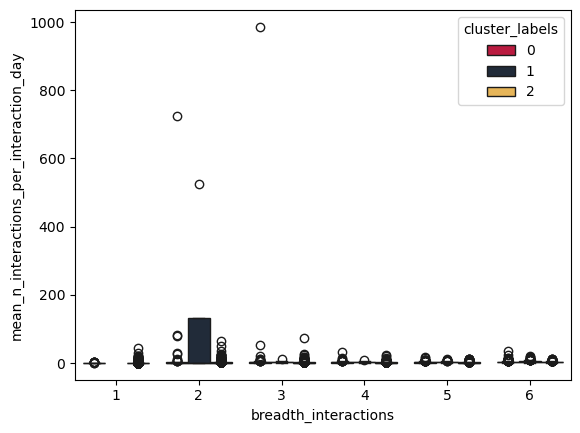

In [160]:
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
sns.boxplot(data=sklearn_hcwdata,
    x="breadth_interactions", 
    #x="cluster_labels",
    y="mean_n_interactions_per_interaction_day",
    hue="cluster_labels", 
    palette = label_color_dict)
print("mean_n_interactions_per_interaction_day across breadth_interactions by Cluster")
print(sklearn_hcwdata.groupby(["breadth_interactions", "cluster_labels"])[["mean_n_interactions_per_interaction_day"]].mean())
sklearn_hcwdata.groupby(["cluster_labels"])[["mean_n_interactions_per_interaction_day"]].mean()

In [161]:
sklearn_hcwdata.columns

Index(['cluster_labels', 'repo_name', 'author_username',
       'n_of_commit_creators', 'n_commits', 'n_changes', 'mean_n_changes',
       'median_n_changes_changed', 'std_n_changes_changed', 'n_files_changed',
       'mean_n_files', 'median_n_files_changed', 'std_n_files_changed',
       'hattori_lanza_size_cat_tiny', 'hattori_lanza_size_cat_small',
       'hattori_lanza_size_cat_medium', 'hattori_lanza_size_cat_large',
       'hattori_lanza_content_cat_forward_engineering',
       'hattori_lanza_content_cat_reengineering',
       'hattori_lanza_content_cat_corrective_engineering',
       'hattori_lanza_content_cat_management',
       'hattori_lanza_content_cat_empty_message',
       'hattori_lanza_content_cat_no_categorisation', 'vasilescu_category_doc',
       'vasilescu_category_img', 'vasilescu_category_l10n',
       'vasilescu_category_ui', 'vasilescu_category_media',
       'vasilescu_category_code', 'vasilescu_category_meta',
       'vasilescu_category_config', 'vasilescu_categ

In [162]:
sklearn_hcwdata["mean_n_interactions_per_interaction_day"].describe()

count    115174.000000
mean          1.442523
std           4.068137
min           1.000000
25%           1.000000
50%           1.000000
75%           1.500000
max         986.000000
Name: mean_n_interactions_per_interaction_day, dtype: float64

In [163]:
sklearn_hcwdata["mean_n_interactions_per_interaction_day"].std()*2

8.136274513444846

In [164]:
extreme_per_day_mean_interactions = sklearn_hcwdata.query("mean_n_interactions_per_interaction_day > 100")[['cluster_labels', 'repo_name', 'gh_username',  'commit_created', 'issue_closed',
       'issue_created', 'pull_request_closed', 'pull_request_created',
       'interaction_days', 'interaction_period_days', 'created-closed_issues',
       'pc_created-closed_issues', 'sum_n_interactions',
       'mean_n_interactions_per_interaction_day', 'which_interactions',
       'breadth_interactions', 'pc_pull_request_created',
       'pc_pull_request_closed', 'pc_commit_created', 'pc_issue_created',
       'pc_issue_closed', 'pc_sum_n_interactions', 'pc_interaction_days',
       'pc_DC' ]]
print(extreme_per_day_mean_interactions.gh_username.unique())
extreme_per_day_mean_interactions

['GoogleCodeExporter' 'github-actions[bot]' 'spine-o-bot']


,cluster_labels,repo_name,gh_username,commit_created,issue_closed,issue_created,pull_request_closed,pull_request_created,interaction_days,interaction_period_days,...,which_interactions,breadth_interactions,pc_pull_request_created,pc_pull_request_closed,pc_commit_created,pc_issue_created,pc_issue_closed,pc_sum_n_interactions,pc_interaction_days,pc_DC
9247,0,shawnlaffan/biodiverse,GoogleCodeExporter,1.0,451.0,534.0,0.0,0.0,1,1,...,"commit_created, issue_closed, issue_created",3,0.0,0.0,0.019631,62.456140,58.344114,14.298144,0.068213,24.163977
41284,1,RADAR-base/radar-helm-charts,github-actions[bot],0.0,1594.0,2088.0,0.0,0.0,7,41,...,"issue_closed, issue_created",2,0.0,0.0,0.000000,99.192399,99.562773,69.867173,1.912568,39.751034
90737,0,spine-tools/Spine-Toolbox,spine-o-bot,0.0,979.0,1193.0,0.0,0.0,3,195,...,"issue_closed, issue_created",2,0.0,0.0,0.000000,47.191456,43.842365,21.269095,0.116777,18.206764


In [165]:
sklearn_hcwdata["mean_n_interactions_per_interaction_day"].std()*2
# 8.136274513444846

8.136274513444846

In [166]:
sklearn_hcwdata["mean_n_interactions_per_interaction_day"].std()*3

12.204411770167269

In [167]:
len(sklearn_hcwdata.query("mean_n_interactions_per_interaction_day <= 12.20"))

115093

In [168]:
len(sklearn_hcwdata.query("mean_n_interactions_per_interaction_day > 12.20"))

81

Repo-individuals' Mean Interactions Per Interaction_Day by Cluster (excluding 81 outliers > 3SD)
                mean_n_interactions_per_interaction_day
cluster_labels                                         
0                                              4.090222
1                                              4.925348
2                                              1.365116

 81 3SD outliers removed: VVV
                mean_n_interactions_per_interaction_day
cluster_labels                                         
0                                              3.182809
1                                              4.079499
2                                              1.355539


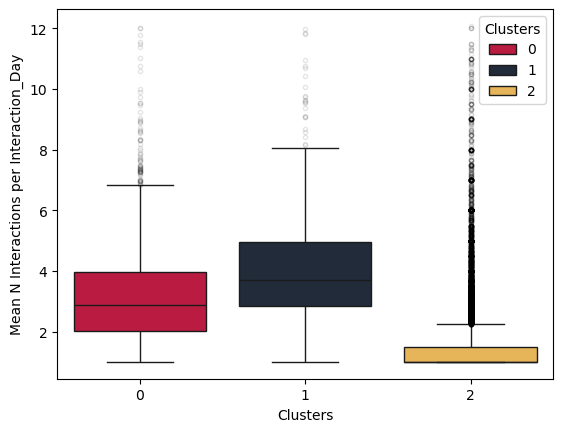

In [66]:
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
sns.boxplot(
    data=sklearn_hcwdata.query("mean_n_interactions_per_interaction_day <= 12.20"),
    #x="breadth_interactions", 
    x="cluster_labels",
    y="mean_n_interactions_per_interaction_day",
    hue="cluster_labels", 
    palette = label_color_dict, 
    fliersize = 3,
    flierprops={"marker": "o", "markeredgecolor":'black', "alpha":0.1}
)
plt.xlabel("Cluster")
plt.ylabel("Mean N Interactions per Interaction_Day")
plt.legend(title="Clusters", loc='best')
plt.xlabel("Clusters")
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_initial_cluster_mean_N_interactions_interactionday_{current_date_info}.pdf", **saveout_args) 

print("Repo-individuals' Mean Interactions Per Interaction_Day by Cluster (excluding 81 outliers > 3SD)")
#print(sklearn_hcwdata.groupby(["breadth_interactions", "cluster_labels"])[["mean_n_interactions_per_interaction_day"]].mean())
print(sklearn_hcwdata.groupby(["cluster_labels"])[["mean_n_interactions_per_interaction_day"]].mean())
print(f"\n {len(sklearn_hcwdata.query('mean_n_interactions_per_interaction_day > 12.20'))} 3SD outliers removed: VVV")
print(sklearn_hcwdata.query("mean_n_interactions_per_interaction_day < 12.20").groupby(["cluster_labels"])[["mean_n_interactions_per_interaction_day"]].mean())

#### interaction_days: 

interaction_days across breadth_interactions by Cluster
                                     interaction_days
breadth_interactions cluster_labels                  
1                    0                      12.382353
                     2                       2.055289
2                    0                      31.145299
                     1                       3.250000
                     2                       3.253913
3                    0                      90.415385
                     1                     154.500000
                     2                       8.728497
4                    0                      68.204819
                     1                     173.600000
                     2                      13.552158
5                    0                     118.240550
                     1                     280.579186
                     2                      35.995222
6                    0                     225.555085
                     1    

,interaction_days
cluster_labels,
0,158.527790
1,334.517143
2,5.051821


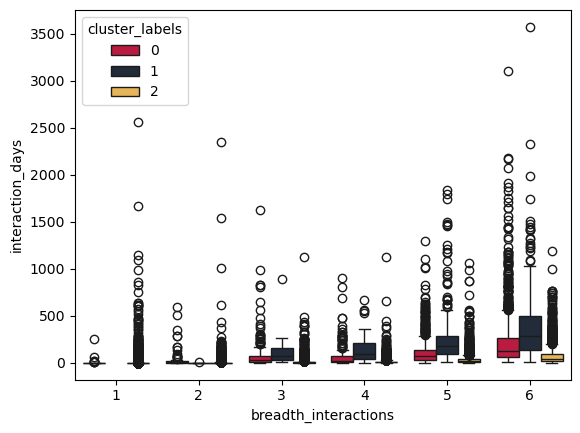

In [170]:
# interaction days
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
sns.boxplot(data=sklearn_hcwdata,
    x="breadth_interactions", 
    #x="cluster_labels",
    y="interaction_days",
    hue="cluster_labels", 
    palette = label_color_dict)
print("interaction_days across breadth_interactions by Cluster")
print(sklearn_hcwdata.groupby(["breadth_interactions", "cluster_labels"])[["interaction_days"]].mean())
sklearn_hcwdata.groupby(["cluster_labels"])[["interaction_days"]].mean()

In [171]:
list_of_vars = ['interaction_days', 'interaction_period_days', 'sum_n_interactions',
       'mean_n_interactions_per_interaction_day', 'pc_sum_n_interactions', 'pc_interaction_days',]
for var in list_of_vars:
    print(run_anova(variable=var, data=analysis_dataset))
    
# F_onewayResult(statistic=23564.090863160272, pvalue=0.0)
#   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
# ========================================================
# group1 group2  meandiff p-adj   lower     upper   reject
# --------------------------------------------------------
#      0      1  175.9894   0.0  170.7224  181.2563   True
#      0      2  -153.476   0.0 -156.0227 -150.9293   True
#      1      2 -329.4653   0.0 -334.1045 -324.8262   True
# --------------------------------------------------------
# For interaction_days, anova result p-value is 0.0; groups are significantly different = True
# For interaction_days, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> interaction_days ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    158.527790
# 1    334.517143
# 2      5.051821
# Name: interaction_days, dtype: float64


# F_onewayResult(statistic=17099.331169371384, pvalue=0.0)
#     Multiple Comparison of Means - Tukey HSD, FWER=0.05    
# ===========================================================
# group1 group2  meandiff  p-adj   lower      upper    reject
# -----------------------------------------------------------
#      0      1   869.5747   0.0   820.0417   919.1077   True
#      0      2 -1423.6179   0.0 -1447.5683 -1399.6674   True
#      1      2 -2293.1925   0.0 -2336.8218 -2249.5632   True
# -----------------------------------------------------------
# For interaction_period_days, anova result p-value is 0.0; groups are significantly different = True
# For interaction_period_days, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> interaction_period_days ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    1586.123886
# 1    2455.698571
# 2     162.506034
# Name: interaction_period_days, dtype: float64


# F_onewayResult(statistic=19431.045992600568, pvalue=0.0)
#    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
# ==========================================================
# group1 group2  meandiff  p-adj   lower     upper    reject
# ----------------------------------------------------------
#      0      1   893.8724   0.0  869.1242   918.6207   True
#      0      2    -595.93   0.0 -607.8964  -583.9636   True
#      1      2 -1489.8025   0.0 -1511.601 -1468.0039   True
# ----------------------------------------------------------
# For sum_n_interactions, anova result p-value is 0.0; groups are significantly different = True
# For sum_n_interactions, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> sum_n_interactions ^^^ is significant <<<<<< 
 
# cluster_labels
# 0     607.156131
# 1    1501.028571
# 2      11.226121
# Name: sum_n_interactions, dtype: float64


# F_onewayResult(statistic=786.6153117182643, pvalue=0.0)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===================================================
# group1 group2 meandiff p-adj  lower   upper  reject
# ---------------------------------------------------
#      0      1   0.8351   0.0  0.4275  1.2428   True
#      0      2  -2.7251   0.0 -2.9222  -2.528   True
#      1      2  -3.5602   0.0 -3.9193 -3.2012   True
# ---------------------------------------------------
# For mean_n_interactions_per_interaction_day, anova result p-value is 0.0; groups are significantly different = True
# For mean_n_interactions_per_interaction_day, Tukey HSD test result p-value is [4.70423361e-06 0.00000000e+00 0.00000000e+00]; groups are significantly different = [ True  True  True]
# >>>>>> mean_n_interactions_per_interaction_day ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    4.090222
# 1    4.925348
# 2    1.365116
# Name: mean_n_interactions_per_interaction_day, dtype: float64


# F_onewayResult(statistic=203977.04514772067, pvalue=0.0)
#  Multiple Comparison of Means - Tukey HSD, FWER=0.05 
# =====================================================
# group1 group2 meandiff p-adj  lower    upper   reject
# -----------------------------------------------------
#      0      1  45.6572   0.0   45.353  45.9615   True
#      0      2 -19.0211   0.0 -19.1682  -18.874   True
#      1      2 -64.6783   0.0 -64.9463 -64.4103   True
# -----------------------------------------------------
# For pc_sum_n_interactions, anova result p-value is 0.0; groups are significantly different = True
# For pc_sum_n_interactions, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> pc_sum_n_interactions ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    19.350140
# 1    65.007369
# 2     0.329042
# Name: pc_sum_n_interactions, dtype: float64


# F_onewayResult(statistic=157491.04040776836, pvalue=0.0)
#  Multiple Comparison of Means - Tukey HSD, FWER=0.05 
# =====================================================
# group1 group2 meandiff p-adj  lower    upper   reject
# -----------------------------------------------------
#      0      1  34.9868   0.0  34.7036  35.2701   True
#      0      2 -16.7342   0.0 -16.8712 -16.5973   True
#      1      2 -51.7211   0.0 -51.9706 -51.4716   True
# -----------------------------------------------------
# For pc_interaction_days, anova result p-value is 0.0; groups are significantly different = True
# For pc_interaction_days, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> pc_interaction_days ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    17.188258
# 1    52.175099
# 2     0.454011
# Name: pc_interaction_days, dtype: float64



F_onewayResult(statistic=23564.090863160272, pvalue=0.0)
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj   lower     upper   reject
--------------------------------------------------------
     0      1  175.9894   0.0  170.7224  181.2563   True
     0      2  -153.476   0.0 -156.0227 -150.9293   True
     1      2 -329.4653   0.0 -334.1045 -324.8262   True
--------------------------------------------------------
For interaction_days, anova result p-value is 0.0; groups are significantly different = True
For interaction_days, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
>>>>>> interaction_days ^^^ is significant <<<<<< 
 
cluster_labels
0    158.527790
1    334.517143
2      5.051821
Name: interaction_days, dtype: float64


F_onewayResult(statistic=17099.331169371384, pvalue=0.0)
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
group1 group2  meandiff  p-adj   lower      upper  

In [172]:
analysis_dataset.columns

Index(['cluster_labels', 'repo_name', 'author_username',
       'n_of_commit_creators', 'n_commits', 'n_changes', 'mean_n_changes',
       'median_n_changes_changed', 'std_n_changes_changed', 'n_files_changed',
       'mean_n_files', 'median_n_files_changed', 'std_n_files_changed',
       'hattori_lanza_size_cat_tiny', 'hattori_lanza_size_cat_small',
       'hattori_lanza_size_cat_medium', 'hattori_lanza_size_cat_large',
       'hattori_lanza_content_cat_forward_engineering',
       'hattori_lanza_content_cat_reengineering',
       'hattori_lanza_content_cat_corrective_engineering',
       'hattori_lanza_content_cat_management',
       'hattori_lanza_content_cat_empty_message',
       'hattori_lanza_content_cat_no_categorisation', 'vasilescu_category_doc',
       'vasilescu_category_img', 'vasilescu_category_l10n',
       'vasilescu_category_ui', 'vasilescu_category_media',
       'vasilescu_category_code', 'vasilescu_category_meta',
       'vasilescu_category_config', 'vasilescu_categ

In [173]:
list_of_vars = ['pc_issues_assigned_of_assigned', 
       'pc_created-closed_issues','mean_n_interactions_per_interaction_day', #'which_interactions',
       'breadth_interactions', 'pc_pull_request_created',
       'pc_pull_request_closed', 'pc_commit_created', 'pc_issue_created',
       'pc_issue_closed', 'pc_sum_n_interactions', 'pc_interaction_days',]
for var in list_of_vars:
    print(run_anova(variable=var, data=analysis_dataset))
    
#     F_onewayResult(statistic=90580.19361466574, pvalue=0.0)
#  Multiple Comparison of Means - Tukey HSD, FWER=0.05 
# =====================================================
# group1 group2 meandiff p-adj  lower    upper   reject
# -----------------------------------------------------
#      0      1  33.3709   0.0  32.9048   33.837   True
#      0      2 -25.4872   0.0 -25.7126 -25.2618   True
#      1      2 -58.8581   0.0 -59.2686 -58.4475   True
# -----------------------------------------------------
# For pc_issues_assigned_of_assigned, anova result p-value is 0.0; groups are significantly different = True
# For pc_issues_assigned_of_assigned, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> pc_issues_assigned_of_assigned ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    25.674216
# 1    59.045096
# 2     0.187007
# Name: pc_issues_assigned_of_assigned, dtype: float64


# F_onewayResult(statistic=267287.9192068027, pvalue=0.0)
#  Multiple Comparison of Means - Tukey HSD, FWER=0.05 
# =====================================================
# group1 group2 meandiff p-adj  lower    upper   reject
# -----------------------------------------------------
#      0      1 -56.2763   0.0 -56.5833 -55.9693   True
#      0      2  20.1189   0.0  19.9705  20.2674   True
#      1      2  76.3952   0.0  76.1248  76.6657   True
# -----------------------------------------------------
# For pc_created-closed_issues, anova result p-value is 0.0; groups are significantly different = True
# For pc_created-closed_issues, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> pc_created-closed_issues ^^^ is significant <<<<<< 
 
# cluster_labels
# 0   -20.306152
# 1   -76.582451
# 2    -0.187205
# Name: pc_created-closed_issues, dtype: float64


# F_onewayResult(statistic=786.6153117182643, pvalue=0.0)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===================================================
# group1 group2 meandiff p-adj  lower   upper  reject
# ---------------------------------------------------
#      0      1   0.8351   0.0  0.4275  1.2428   True
#      0      2  -2.7251   0.0 -2.9222  -2.528   True
#      1      2  -3.5602   0.0 -3.9193 -3.2012   True
# ---------------------------------------------------
# For mean_n_interactions_per_interaction_day, anova result p-value is 0.0; groups are significantly different = True
# For mean_n_interactions_per_interaction_day, Tukey HSD test result p-value is [4.70423361e-06 0.00000000e+00 0.00000000e+00]; groups are significantly different = [ True  True  True]
# >>>>>> mean_n_interactions_per_interaction_day ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    4.090222
# 1    4.925348
# 2    1.365116
# Name: mean_n_interactions_per_interaction_day, dtype: float64


# F_onewayResult(statistic=16394.17266013766, pvalue=0.0)
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ===================================================
# group1 group2 meandiff p-adj  lower   upper  reject
# ---------------------------------------------------
#      0      1   0.5014   0.0  0.3958   0.607   True
#      0      2  -3.3532   0.0 -3.4042 -3.3021   True
#      1      2  -3.8546   0.0 -3.9476 -3.7615   True
# ---------------------------------------------------
# For breadth_interactions, anova result p-value is 0.0; groups are significantly different = True
# For breadth_interactions, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> breadth_interactions ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    5.022910
# 1    5.524286
# 2    1.669729
# Name: breadth_interactions, dtype: float64


# F_onewayResult(statistic=59153.566469509125, pvalue=0.0)
#  Multiple Comparison of Means - Tukey HSD, FWER=0.05 
# =====================================================
# group1 group2 meandiff p-adj  lower    upper   reject
# -----------------------------------------------------
#      0      1  23.4658   0.0  23.0664  23.8651   True
#      0      2 -17.5002   0.0 -17.6933 -17.3071   True
#      1      2 -40.9659   0.0 -41.3177 -40.6141   True
# -----------------------------------------------------
# For pc_pull_request_created, anova result p-value is 0.0; groups are significantly different = True
# For pc_pull_request_created, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> pc_pull_request_created ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    17.993994
# 1    41.459747
# 2     0.493826
# Name: pc_pull_request_created, dtype: float64


# F_onewayResult(statistic=202095.7281192863, pvalue=0.0)
#  Multiple Comparison of Means - Tukey HSD, FWER=0.05 
# =====================================================
# group1 group2 meandiff p-adj  lower    upper   reject
# -----------------------------------------------------
#      0      1  55.7052   0.0  55.3339  56.0765   True
#      0      2 -22.9835   0.0  -23.163 -22.8039   True
#      1      2 -78.6887   0.0 -79.0158 -78.3616   True
# -----------------------------------------------------
# For pc_pull_request_closed, anova result p-value is 0.0; groups are significantly different = True
# For pc_pull_request_closed, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> pc_pull_request_closed ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    23.125001
# 1    78.830223
# 2     0.141536
# Name: pc_pull_request_closed, dtype: float64


# F_onewayResult(statistic=85560.01791630342, pvalue=0.0)
#  Multiple Comparison of Means - Tukey HSD, FWER=0.05 
# =====================================================
# group1 group2 meandiff p-adj  lower    upper   reject
# -----------------------------------------------------
#      0      1  42.0098   0.0  41.6027   42.417   True
#      0      2 -15.2112   0.0 -15.4081 -15.0143   True
#      1      2  -57.221   0.0 -57.5797 -56.8624   True
# -----------------------------------------------------
# For pc_commit_created, anova result p-value is 0.0; groups are significantly different = True
# For pc_commit_created, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> pc_commit_created ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    15.450765
# 1    57.460602
# 2     0.239553
# Name: pc_commit_created, dtype: float64


# F_onewayResult(statistic=64055.67140803247, pvalue=0.0)
#  Multiple Comparison of Means - Tukey HSD, FWER=0.05 
# =====================================================
# group1 group2 meandiff p-adj  lower    upper   reject
# -----------------------------------------------------
#      0      1   24.685   0.0  24.3388  25.0312   True
#      0      2 -14.2579   0.0 -14.4253 -14.0905   True
#      1      2 -38.9429   0.0 -39.2478  -38.638   True
# -----------------------------------------------------
# For pc_issue_created, anova result p-value is 0.0; groups are significantly different = True
# For pc_issue_created, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> pc_issue_created ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    14.820810
# 1    39.505821
# 2     0.562923
# Name: pc_issue_created, dtype: float64


# F_onewayResult(statistic=268053.1580039935, pvalue=0.0)
#  Multiple Comparison of Means - Tukey HSD, FWER=0.05 
# =====================================================
# group1 group2 meandiff p-adj  lower    upper   reject
# -----------------------------------------------------
#      0      1  56.5261   0.0  56.2179  56.8344   True
#      0      2 -20.2586   0.0 -20.4076 -20.1095   True
#      1      2 -76.7847   0.0 -77.0562 -76.5132   True
# -----------------------------------------------------
# For pc_issue_closed, anova result p-value is 0.0; groups are significantly different = True
# For pc_issue_closed, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> pc_issue_closed ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    20.451390
# 1    76.977509
# 2     0.192834
# Name: pc_issue_closed, dtype: float64


# F_onewayResult(statistic=203977.04514772067, pvalue=0.0)
#  Multiple Comparison of Means - Tukey HSD, FWER=0.05 
# =====================================================
# group1 group2 meandiff p-adj  lower    upper   reject
# -----------------------------------------------------
#      0      1  45.6572   0.0   45.353  45.9615   True
#      0      2 -19.0211   0.0 -19.1682  -18.874   True
#      1      2 -64.6783   0.0 -64.9463 -64.4103   True
# -----------------------------------------------------
# For pc_sum_n_interactions, anova result p-value is 0.0; groups are significantly different = True
# For pc_sum_n_interactions, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> pc_sum_n_interactions ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    19.350140
# 1    65.007369
# 2     0.329042
# Name: pc_sum_n_interactions, dtype: float64


# F_onewayResult(statistic=157491.04040776836, pvalue=0.0)
#  Multiple Comparison of Means - Tukey HSD, FWER=0.05 
# =====================================================
# group1 group2 meandiff p-adj  lower    upper   reject
# -----------------------------------------------------
#      0      1  34.9868   0.0  34.7036  35.2701   True
#      0      2 -16.7342   0.0 -16.8712 -16.5973   True
#      1      2 -51.7211   0.0 -51.9706 -51.4716   True
# -----------------------------------------------------
# For pc_interaction_days, anova result p-value is 0.0; groups are significantly different = True
# For pc_interaction_days, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
# >>>>>> pc_interaction_days ^^^ is significant <<<<<< 
 
# cluster_labels
# 0    17.188258
# 1    52.175099
# 2     0.454011
# Name: pc_interaction_days, dtype: float64



F_onewayResult(statistic=90580.19361466574, pvalue=0.0)
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
     0      1  33.3709   0.0  32.9048   33.837   True
     0      2 -25.4872   0.0 -25.7126 -25.2618   True
     1      2 -58.8581   0.0 -59.2686 -58.4475   True
-----------------------------------------------------
For pc_issues_assigned_of_assigned, anova result p-value is 0.0; groups are significantly different = True
For pc_issues_assigned_of_assigned, Tukey HSD test result p-value is [0. 0. 0.]; groups are significantly different = [ True  True  True]
>>>>>> pc_issues_assigned_of_assigned ^^^ is significant <<<<<< 
 
cluster_labels
0    25.674216
1    59.045096
2     0.187007
Name: pc_issues_assigned_of_assigned, dtype: float64


F_onewayResult(statistic=267287.9192068027, pvalue=0.0)
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-ad

Mean N interaction_days by Cluster


,interaction_days
cluster_labels,
0,158.527790
1,334.517143
2,5.051821


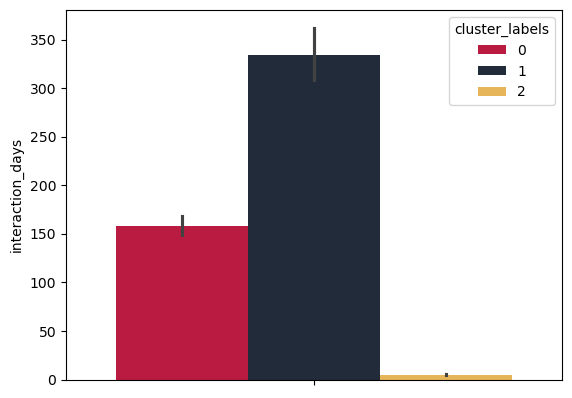

In [174]:
# interaction days
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
sns.barplot(data=sklearn_hcwdata,
    y="interaction_days", 
    #x="cluster_labels",
    hue="cluster_labels", 
    palette = label_color_dict)
print("Mean N interaction_days by Cluster")
sklearn_hcwdata.groupby(["cluster_labels"])[["interaction_days"]].mean()


N interaction_days by Cluster


,interaction_days
cluster_labels,
0,158.527790
1,334.517143
2,5.051821


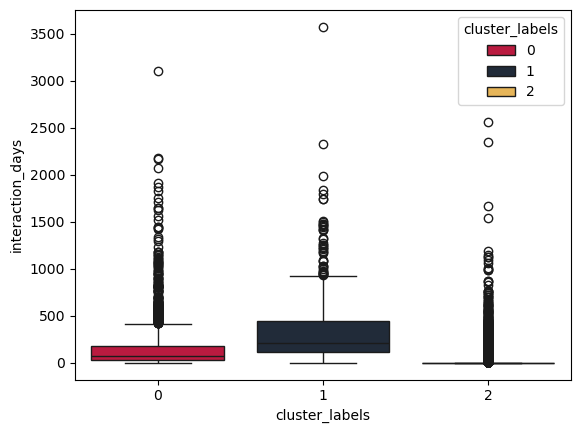

In [175]:
# interaction_period 
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
sns.boxplot(data=sklearn_hcwdata, # SHOWS MEDIAN (and upper/lower quartile, and 1.5 Inter-quartile range)
    #x="breadth_interactions", 
    x="cluster_labels",
    y="interaction_days",
    hue="cluster_labels", 
    palette = label_color_dict)
print("N interaction_days by Cluster")
sklearn_hcwdata.groupby(["cluster_labels"])[["interaction_days"]].mean() # MEAN AVERAGE


N interaction_days across breadth_interactions by Cluster


,interaction_days
cluster_labels,
0,158.527790
1,334.517143
2,5.051821


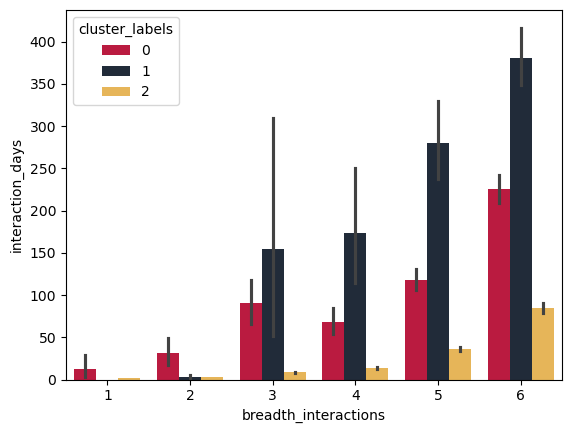

In [176]:
# interaction days
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
sns.barplot(data=sklearn_hcwdata,
    x="breadth_interactions", 
    #x="cluster_labels",
    y="interaction_days",
    hue="cluster_labels", 
    palette = label_color_dict)
print("N interaction_days across breadth_interactions by Cluster")
sklearn_hcwdata.groupby(["cluster_labels"])[["interaction_days"]].mean()


#### interaction_period_days: 

N interaction_period_days across breadth_interactions by Cluster
                                     interaction_period_days
breadth_interactions cluster_labels                         
1                    0                            196.058824
                     2                             55.280449
2                    0                            568.538462
                     1                            102.750000
                     2                            149.956468
3                    0                           1038.733333
                     1                           1841.250000
                     2                            419.198039
4                    0                           1316.333333
                     1                           1987.033333
                     2                            630.949692
5                    0                           1541.707904
                     1                           2572.447964
                    

,interaction_period_days
cluster_labels,
0,1586.123886
1,2455.698571
2,162.506034


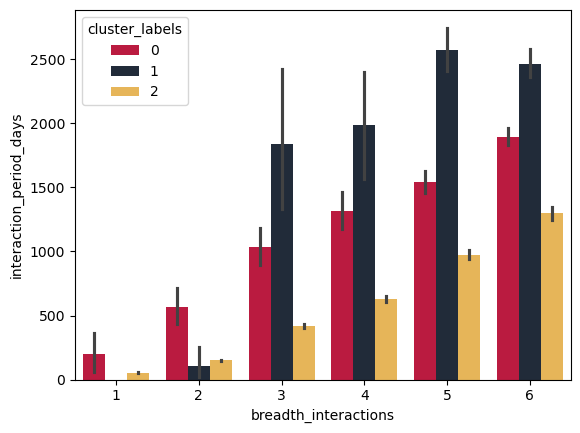

In [177]:
# interaction period
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
sns.barplot(data=sklearn_hcwdata,
    x="breadth_interactions", 
    #x="cluster_labels",
    y="interaction_period_days",
    hue="cluster_labels", 
    palette = label_color_dict)
print("N interaction_period_days across breadth_interactions by Cluster")
print(sklearn_hcwdata.groupby(["breadth_interactions", "cluster_labels"])[["interaction_period_days"]].mean())
sklearn_hcwdata.groupby(["cluster_labels"])[["interaction_period_days"]].mean()

N interaction_period_days across breadth_interactions by Cluster


,interaction_period_days
cluster_labels,
0,1586.123886
1,2455.698571
2,162.506034


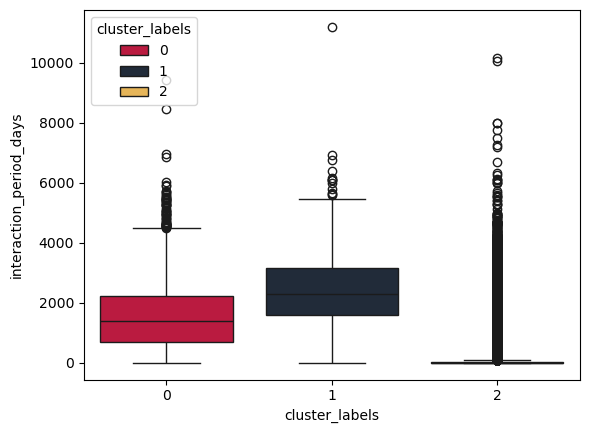

In [178]:
# interaction_period 
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
sns.boxplot(data=sklearn_hcwdata, # SHOWS MEDIAN (and upper/lower quartile, and 1.5 Inter-quartile range)
    #x="breadth_interactions", 
    x="cluster_labels",
    y="interaction_period_days",
    hue="cluster_labels", 
    palette = label_color_dict)
print("N interaction_period_days across breadth_interactions by Cluster")
sklearn_hcwdata.groupby(["cluster_labels"])[["interaction_period_days"]].mean() # MEAN AVERAGE


#### pc_interaction_days: 

pc_interaction_days across breadth_interactions by Cluster


,pc_interaction_days
cluster_labels,
0,17.188258
1,52.175099
2,0.454011


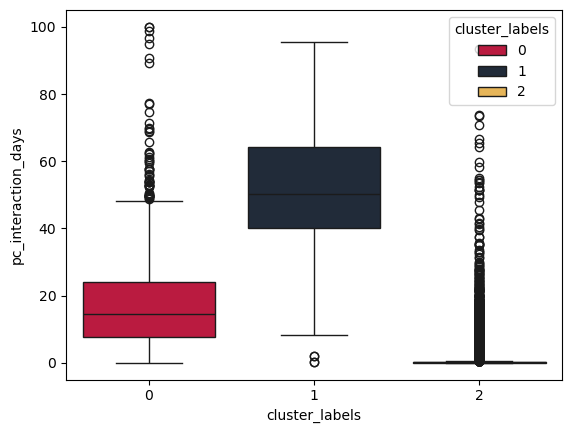

In [179]:
# pc_interaction_days
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
sns.boxplot(data=sklearn_hcwdata, # SHOWS MEDIAN (and upper/lower quartile, and 1.5 Inter-quartile range)
    #x="breadth_interactions", 
    x="cluster_labels",
    y="pc_interaction_days",
    hue="cluster_labels", 
    palette = label_color_dict)
print("pc_interaction_days across breadth_interactions by Cluster")
sklearn_hcwdata.groupby(["cluster_labels"])[["pc_interaction_days"]].mean() # MEAN AVERAGE


pc_interaction_days across breadth_interactions by Cluster


,pc_interaction_days
cluster_labels,
0,17.188258
1,52.175099
2,0.454011


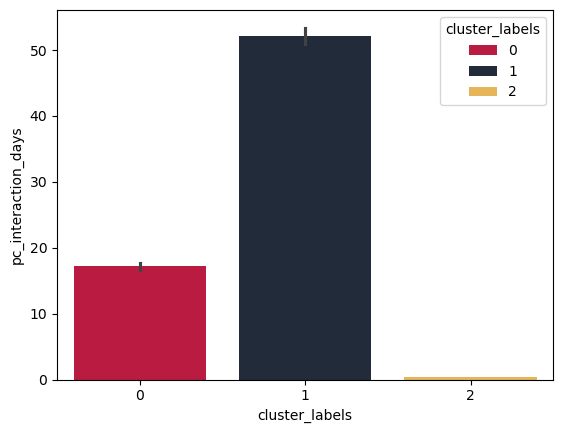

In [180]:
# pc_interaction_days BARPLOT
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
sns.barplot(data=sklearn_hcwdata, # SHOWS MEDIAN (and upper/lower quartile, and 1.5 Inter-quartile range)
    #x="breadth_interactions", 
    x="cluster_labels",
    y="pc_interaction_days",
    hue="cluster_labels", 
    palette = label_color_dict)
print("pc_interaction_days across breadth_interactions by Cluster")
sklearn_hcwdata.groupby(["cluster_labels"])[["pc_interaction_days"]].mean() # MEAN 


In [181]:
analysis_dataset.columns

Index(['cluster_labels', 'repo_name', 'author_username',
       'n_of_commit_creators', 'n_commits', 'n_changes', 'mean_n_changes',
       'median_n_changes_changed', 'std_n_changes_changed', 'n_files_changed',
       'mean_n_files', 'median_n_files_changed', 'std_n_files_changed',
       'hattori_lanza_size_cat_tiny', 'hattori_lanza_size_cat_small',
       'hattori_lanza_size_cat_medium', 'hattori_lanza_size_cat_large',
       'hattori_lanza_content_cat_forward_engineering',
       'hattori_lanza_content_cat_reengineering',
       'hattori_lanza_content_cat_corrective_engineering',
       'hattori_lanza_content_cat_management',
       'hattori_lanza_content_cat_empty_message',
       'hattori_lanza_content_cat_no_categorisation', 'vasilescu_category_doc',
       'vasilescu_category_img', 'vasilescu_category_l10n',
       'vasilescu_category_ui', 'vasilescu_category_media',
       'vasilescu_category_code', 'vasilescu_category_meta',
       'vasilescu_category_config', 'vasilescu_categ

pc_created-closed_issues by Cluster


,pc_created-closed_issues
cluster_labels,
0,-20.306152
1,-76.582451
2,-0.187205


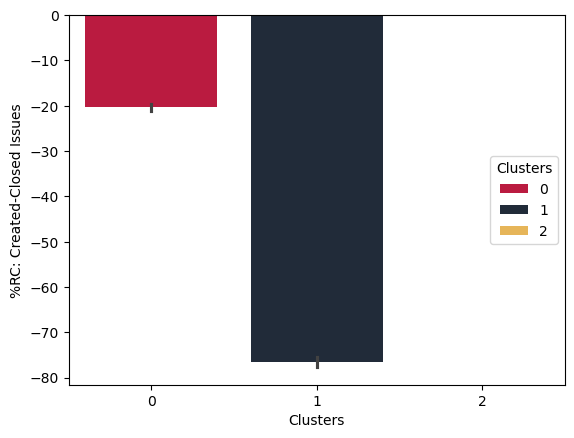

In [67]:
#  BARPLOT
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 

cl0 = round((analysis_dataset.groupby("cluster_labels")["pc_created-closed_issues"].mean()[0]), 2)
cl1 = round((analysis_dataset.groupby("cluster_labels")["pc_created-closed_issues"].mean()[1]), 2)
cl2 = round((analysis_dataset.groupby("cluster_labels")["pc_created-closed_issues"].mean()[2]), 2)

sns.barplot(data=sklearn_hcwdata, # SHOWS MEDIAN (and upper/lower quartile, and 1.5 Inter-quartile range)
    #x="breadth_interactions", 
    x="cluster_labels",
    y="pc_created-closed_issues",
    hue="cluster_labels", 
    palette = label_color_dict)
plt.legend(title="Clusters", loc='center right',) #labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.ylabel("%RC: Created-Closed Issues")
plt.xlabel("Clusters")
plt.savefig(f"../../images/analysis_run_sample_45pc_2025-05-12/45pc_whole_sample_initial_cluster_pc_created-closed_issues_{current_date_info}.pdf", **saveout_args) 
print("pc_created-closed_issues by Cluster")
sklearn_hcwdata.groupby(["cluster_labels"])[["pc_created-closed_issues"]].mean() # MEAN 


In [253]:
analysis_dataset.groupby("cluster_labels")["pc_commit_created"].describe()


,count,mean,std,min,25%,50%,75%,max
cluster_labels,,,,,,,,
0,2357.0,15.450765,17.585564,0.0,0.124844,10.183639,23.849372,100.000000
1,700.0,57.460602,33.019413,0.0,37.693802,66.716029,84.993288,99.675588
2,112117.0,0.239553,1.853747,0.0,0.000000,0.000000,0.000000,96.039604


In [254]:

analysis_dataset.groupby("cluster_labels")["pc_issue_created"].describe()



,count,mean,std,min,25%,50%,75%,max
cluster_labels,,,,,,,,
0,2357.0,14.820810,15.719786,0.0,2.691511,10.398230,22.500000,100.0
1,700.0,39.505821,27.511570,0.0,15.484085,38.783831,60.687882,100.0
2,112117.0,0.562923,1.478044,0.0,0.025773,0.129366,0.480769,36.0


In [255]:

analysis_dataset.groupby("cluster_labels")["pc_issue_closed"].describe()



,count,mean,std,min,25%,50%,75%,max
cluster_labels,,,,,,,,
0,2357.0,20.451390,18.729068,0.000000,4.545455,15.853659,32.000000,100.000000
1,700.0,76.977509,14.574784,26.262626,66.251591,77.777778,87.752091,100.000000
2,112117.0,0.192834,0.945845,0.000000,0.000000,0.000000,0.000000,33.333333


In [256]:

analysis_dataset.groupby("cluster_labels")["pc_issues_assigned_of_assigned"].describe()




,count,mean,std,min,25%,50%,75%,max
cluster_labels,,,,,,,,
0,2357.0,25.674216,23.900723,0.0,4.906809,21.739130,37.500000,100.000000
1,700.0,59.045096,36.352887,0.0,31.129808,65.564663,94.736842,100.000000
2,112117.0,0.187007,1.297790,0.0,0.000000,0.000000,0.000000,28.571429


In [257]:

analysis_dataset.groupby("cluster_labels")["pc_pull_request_created"].describe()



,count,mean,std,min,25%,50%,75%,max
cluster_labels,,,,,,,,
0,2357.0,17.993994,17.963502,0.0,4.347826,13.493530,25.458248,100.000000
1,700.0,41.459747,24.935278,0.0,25.769933,41.892697,59.459459,100.000000
2,112117.0,0.493826,2.332780,0.0,0.000000,0.000000,0.105932,83.333333


In [258]:


analysis_dataset.groupby("cluster_labels")["pc_pull_request_closed"].describe()



,count,mean,std,min,25%,50%,75%,max
cluster_labels,,,,,,,,
0,2357.0,23.125001,22.237298,0.0,4.519774,17.500000,34.323432,100.000000
1,700.0,78.830223,19.987209,0.0,68.463613,84.210526,94.202899,100.000000
2,112117.0,0.141536,1.017146,0.0,0.000000,0.000000,0.000000,33.333333


In [259]:


analysis_dataset.groupby("cluster_labels")["pc_DC"].describe()

,count,mean,std,min,25%,50%,75%,max
cluster_labels,,,,,,,,
0,2357.0,18.878235,9.966164,0.174672,10.793001,16.846403,25.090371,59.371728
1,700.0,54.889755,13.729899,26.354839,44.457091,53.548565,63.588146,94.550828
2,112117.0,0.335229,0.997377,0.000651,0.021277,0.062500,0.209058,20.319503
